# Student Career Success: Placement Prediction

We investigate which academic, skill-based and professional factors are associated with a student's placement outcome, then benchmark 23 classifiers and tune the three most accurate ones.

## Dataset

| Component | Details |
|:---|:---|
| Dataset | [Student Career Success Prediction Dataset](https://www.kaggle.com/datasets/mobeenfatimah/student-career-success-prediction-dataset) (Kaggle) |
| Records | 50,000 synthetic student records |
| Features | Demographics, academics, technical and soft skills, experience, internships, projects, certifications, employability indicators |
| Target | `Placement_Status` (Placed / Not Placed) |

## Pipeline

1. **Data understanding**: load the data and inspect structure and types.
2. **Data quality**: check missing values, duplicates and constant columns.
3. **EDA**: profile demographics, academics, skills, experience and the target.
4. **Feature relationships**: compare features across placement groups with statistical tests.
5. **Outlier detection**: IQR-based flagging and boxplots.
6. **Feature engineering**: row-wise features only, so no leakage between rows.
7. **Leakage removal and preprocessing**: drop post-outcome columns, fit transforms on the training split only.
8. **Model benchmark**: 23 classifiers, including voting and stacking ensembles.
9. **Model comparison**: F1, accuracy, AUC, overfitting gap and training time.
10. **Final test evaluation**: score the champion once on the held-out test set.
11. **Hyperparameter tuning**: RandomizedSearchCV vs Optuna on the top 3 models.
12. **Conclusions**.

## Key Questions

- **Student profile**: how do demographic and academic characteristics vary?
- **Skill development**: how do technical, communication and professional attributes relate to placement?
- **Placement outcomes**: which characteristics are associated with higher placement rates?
- **Modelling**: which classifier predicts placement most reliably, and does tuning improve it?

## Setup

In [1]:
!pip install -q lightgbm xgboost catboost imbalanced-learn optuna --upgrade


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Import libraries
import os, time, pathlib, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, randint, uniform, loguniform
from statsmodels.stats.multitest import multipletests
import optuna

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier,
                              BaggingClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

/Users/dan/Coding/Uni/Halden/AI/Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RANDOM_STATE = 42

## 1. Data Understanding

We download the dataset from Kaggle and load it into a DataFrame.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mobeenfatimah/student-career-success-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/dan/.cache/kagglehub/datasets/mobeenfatimah/student-career-success-prediction-dataset/versions/1


In [5]:
df = pd.read_csv(pathlib.Path(path) / "student_career_success_dataset.csv")
print("Shape of the dataset:", df.shape)
display(df.head())

Shape of the dataset: (50000, 29)


,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,Projects_Completed,Certifications,Hackathons,GitHub_Profile,Internships,Leadership_Experience,LinkedIn_Profile,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,10,1,6,Yes,5,No,No,100,9,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,6,0,5,Yes,2,No,Yes,80,5,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,9,0,5,Yes,3,Yes,No,100,7,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,6,3,3,No,2,No,Yes,85,6,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,10,1,2,Yes,3,Yes,Yes,100,10,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256


### Dataset structure

In [6]:
print("Display Dataset Info:")
df.info()

Display Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  str    
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  str    
 3   University_Year        50000 non-null  str    
 4   Major                  50000 non-null  str    
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  str    
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  str    
 14  Internships            50000 non-null  int6

### Columns

In [7]:
print("Dataset Columns list:")
print(df.columns.tolist())

Dataset Columns list:
['Student_ID', 'Age', 'Gender', 'University_Year', 'Major', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA', 'Academic_Performance', 'Programming_Skill', 'Projects_Completed', 'Certifications', 'Hackathons', 'GitHub_Profile', 'Internships', 'Leadership_Experience', 'LinkedIn_Profile', 'Resume_Score', 'Communication_Skills', 'Teamwork', 'Problem_Solving', 'English_Proficiency', 'Interview_Score', 'Employability_Score', 'Placement_Status', 'Company_Tier', 'Career_Field', 'Placement_Mode', 'Starting_Salary_USD']


### Numerical summary statistics

In [8]:
display(df.describe(include=[np.number]).T.round(2))

,count,mean,std,min,25%,50%,75%,max
Age,50000.0,21.26,2.04,18.0,20.00,21.00,22.00,30.00
Attendance_Percentage,50000.0,81.41,9.71,50.0,75.00,82.00,88.00,100.00
Study_Hours_Per_Week,50000.0,21.53,6.97,5.0,17.00,21.00,26.00,45.00
CGPA,50000.0,3.11,0.29,2.0,2.91,3.11,3.31,4.00
Programming_Skill,50000.0,7.14,1.51,1.0,6.00,7.00,8.00,10.00
Projects_Completed,50000.0,8.62,2.51,0.0,7.00,9.00,10.00,15.00
Certifications,50000.0,1.72,1.37,0.0,1.00,2.00,3.00,8.00
Hackathons,50000.0,3.09,1.66,0.0,2.00,3.00,4.00,10.00
Internships,50000.0,4.05,1.01,0.0,3.00,4.00,5.00,5.00
Resume_Score,50000.0,96.05,7.33,44.0,95.00,100.00,100.00,100.00


### Categorical summary statistics

In [9]:
categorical_summary = df.describe(include="object").T.rename(
    columns={"count": "Count", "unique": "Unique Values", "top": "Most Frequent", "freq": "Frequency"})
display(categorical_summary)

,Count,Unique Values,Most Frequent,Frequency
Student_ID,50000,50000,ST000001,1
Gender,50000,3,Male,24533
University_Year,50000,4,Junior,14870
Major,50000,8,Computer Science,12407
Academic_Performance,50000,4,Average,28890
GitHub_Profile,50000,2,Yes,40680
Leadership_Experience,50000,2,No,30403
LinkedIn_Profile,50000,2,Yes,35917
English_Proficiency,50000,3,Advanced,39640
Placement_Status,50000,2,Placed,39040


## 2. Data Quality

### Missing values

In [10]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values found in the Dataset in these columns such as:")
    display(missing.to_frame("Missing Count"))

No missing values found in the dataset.


### Missing-value heatmap

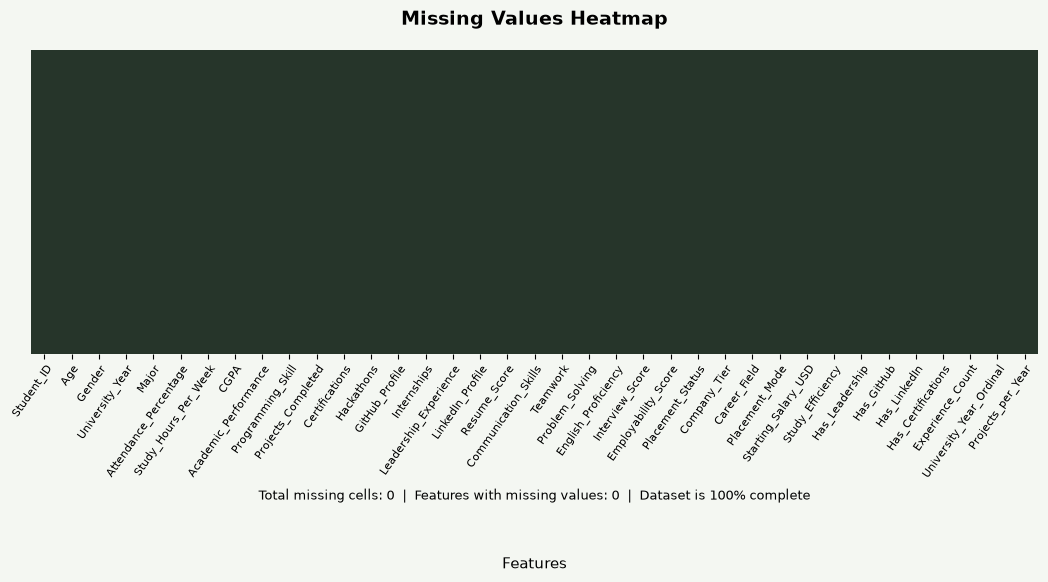

In [80]:
tones, bg = ["#26352A", "#7F966F"], "#F4F7F2"
moss = LinearSegmentedColormap.from_list("moss", tones)

fig, ax = plt.subplots(figsize=(13, 8), facecolor=bg)
ax.set_facecolor(bg)

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap=moss, ax=ax, linewidths=0)

ax.set_title("Missing Values Heatmap",
             fontsize=14, fontweight="bold", pad=18)

ax.set_xlabel("Features", fontsize=11, labelpad=55)
plt.setp(ax.get_xticklabels(), rotation=55, ha="right", rotation_mode="anchor", fontsize=8)
ax.set_ylabel("")

missing = df.isnull().sum()
ax.text(0.5, -0.48,
        f"Total missing cells: {missing.sum()}  |  Features with missing values: {(missing > 0).sum()}  |  Dataset is 100% complete",
        transform=ax.transAxes, ha="center", fontsize=9)

plt.subplots_adjust(bottom=0.50, top=0.88)
plt.show()

### Duplicates and constant columns

In [12]:
# Check for duplicate Student_IDs
dup_ids = df["Student_ID"].duplicated().sum() if "Student_ID" in df.columns else 0
print(f"Duplicate Student_IDs: {dup_ids}")
# Check for completely duplicated rows
full_dupes = df.duplicated().sum()
print(f"Fully duplicate rows: {full_dupes}")
# Check for columns with no variation
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant (zero-variance) columns:", constant_cols if constant_cols else "None")

Duplicate Student_IDs: 0
Fully duplicate rows: 0
Constant (zero-variance) columns: None


## 3. Exploratory Data Analysis

### Demographic profile

In [13]:
overall_summary = pd.Series({
    "Total students": len(df),
    "Average age": round(df["Age"].mean(), 2),
    "Min age": df["Age"].min(),
    "Max age": df["Age"].max(),
    "Genders": df["Gender"].nunique(),
    "University years": df["University_Year"].nunique(),
}).to_frame("Value")
display(overall_summary)

def group_profile(col):
    out = df.groupby(col).agg(Students=(col, "size"), Mean_Age=("Age", "mean"), Min_Age=("Age", "min"), Max_Age=("Age", "max"))
    out.insert(1, "Percentage", out["Students"] / len(df) * 100)
    return out.sort_values("Students", ascending=False).round(2)

gender_analysis = group_profile("Gender")
year_analysis = group_profile("University_Year")
display(gender_analysis, year_analysis)

# Gender composition within each university year
year_gender_counts = pd.crosstab(df["University_Year"], df["Gender"])
year_gender_pct = (pd.crosstab(df["University_Year"], df["Gender"], normalize="index") * 100).round(2)
display(year_gender_counts, year_gender_pct)

age_range_by_year = year_analysis[["Mean_Age", "Min_Age", "Max_Age"]].assign(Age_Range=lambda d: d["Max_Age"] - d["Min_Age"])
display(age_range_by_year)

largest_gender, largest_year = gender_analysis.index[0], year_analysis.index[0]
print(f"- {len(df):,} students, average age {df['Age'].mean():.1f} (range {df['Age'].min()}-{df['Age'].max()}).")
print(f"- Largest gender group: {largest_gender} ({gender_analysis.loc[largest_gender, 'Percentage']:.1f}%).")
print(f"- Largest university year: {largest_year} ({year_analysis.loc[largest_year, 'Percentage']:.1f}%).")
print(f"- Youngest year on average: {year_analysis['Mean_Age'].idxmin()}; oldest: {year_analysis['Mean_Age'].idxmax()}.")

,Value
Total students,50000.00
Average age,21.26
Min age,18.00
Max age,30.00
Genders,3.00
University years,4.00


,Students,Percentage,Mean_Age,Min_Age,Max_Age
Gender,,,,,
Male,24533,49.07,21.26,18,30
Female,24465,48.93,21.26,18,30
Other,1002,2.00,21.39,18,30


,Students,Percentage,Mean_Age,Min_Age,Max_Age
University_Year,,,,,
Junior,14870,29.74,21.26,18,30
Senior,12658,25.32,21.31,18,30
Sophomore,12634,25.27,21.24,18,30
Freshman,9838,19.68,21.24,18,30


Gender,Female,Male,Other
University_Year,,,
Freshman,4813,4823,202
Junior,7236,7338,296
Senior,6179,6238,241
Sophomore,6237,6134,263


Gender,Female,Male,Other
University_Year,,,
Freshman,48.92,49.02,2.05
Junior,48.66,49.35,1.99
Senior,48.81,49.28,1.90
Sophomore,49.37,48.55,2.08


,Mean_Age,Min_Age,Max_Age,Age_Range
University_Year,,,,
Junior,21.26,18,30,12
Senior,21.31,18,30,12
Sophomore,21.24,18,30,12
Freshman,21.24,18,30,12


- 50,000 students, average age 21.3 (range 18-30).
- Largest gender group: Male (49.1%).
- Largest university year: Junior (29.7%).
- Youngest year on average: Sophomore; oldest: Senior.


### Demographic profile: plots

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


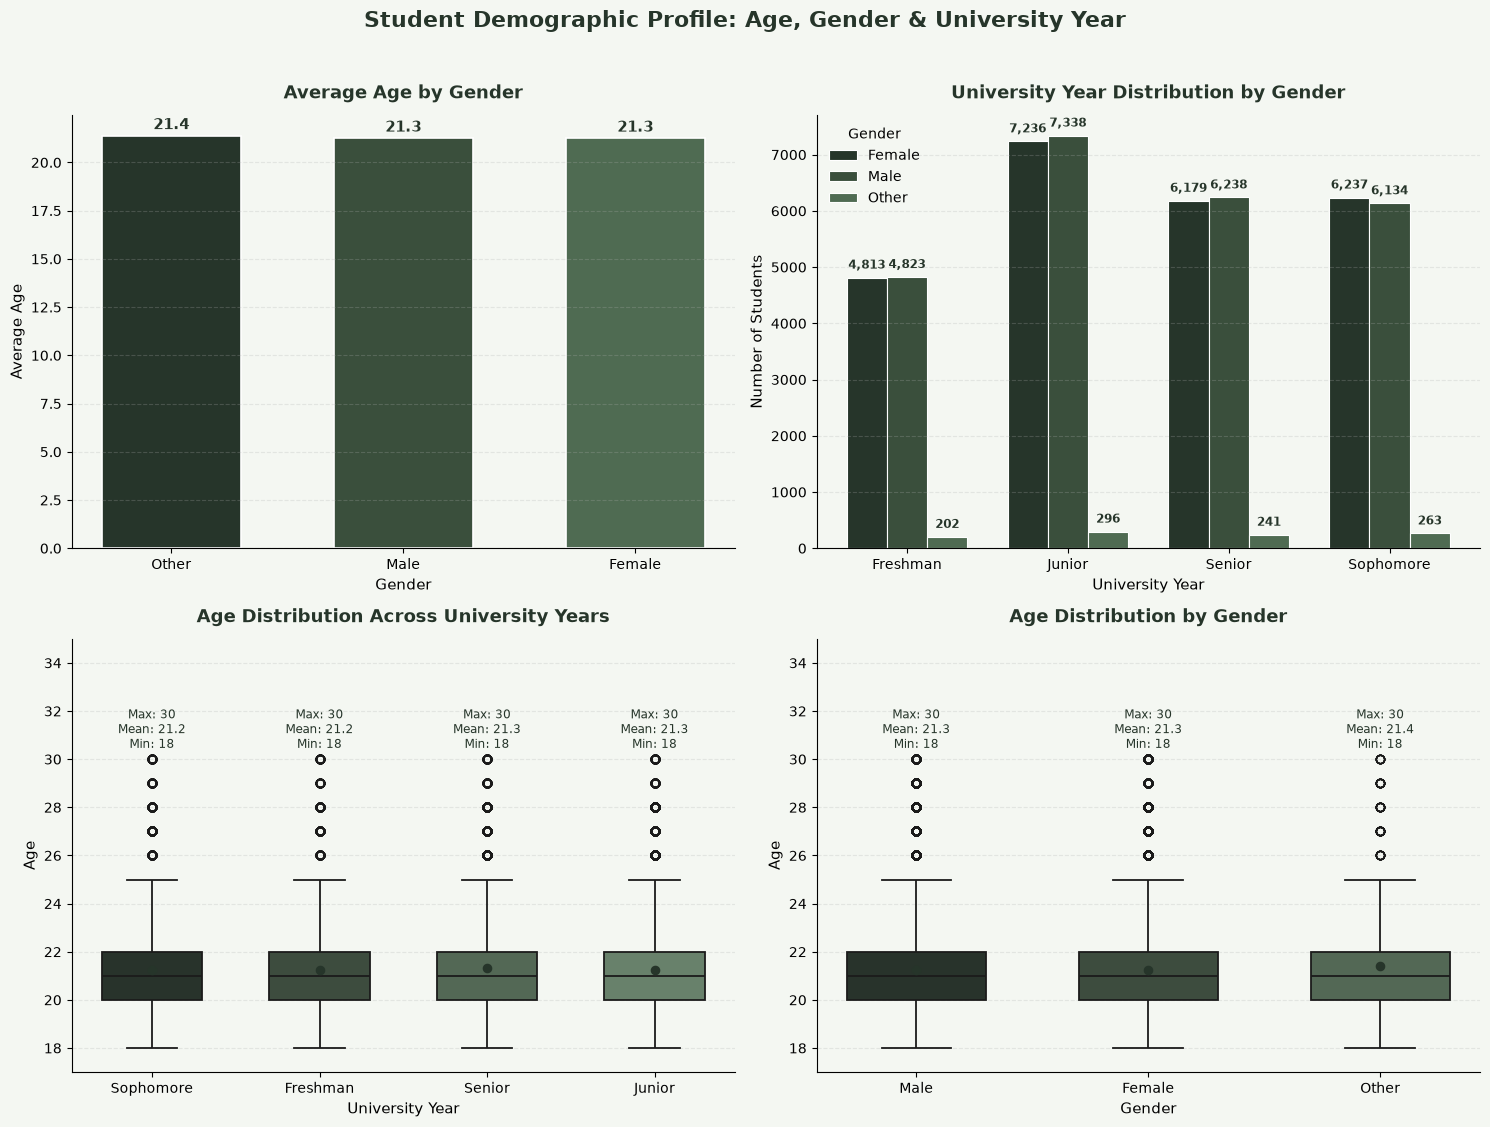

In [14]:
# Student Demographic Profile: Age, Gender and University Year
tones = ["#26352A", "#3A4F3C", "#4F6B52", "#648568", "#7F966F", "#8FAE8A"]
bg = "#F4F7F2"

fig, axes = plt.subplots(2, 2, figsize=(15, 11), facecolor=bg)
axes = axes.flatten()
for ax in axes:
    ax.set_facecolor(bg)
    ax.spines[["top", "right"]].set_visible(False)

# Average Age by Gender
age_by_gender = df.groupby("Gender")["Age"].mean().sort_values(ascending=False)
bars = axes[0].bar(age_by_gender.index, age_by_gender.values, color=tones[:len(age_by_gender)], edgecolor="white", linewidth=1.2, width=0.6)
for bar, value in zip(bars, age_by_gender.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, f"{value:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold", color="#26352A")
axes[0].set_title("Average Age by Gender", fontsize=13, fontweight="bold", color="#26352A", pad=12)
axes[0].set_xlabel("Gender", fontsize=11)
axes[0].set_ylabel("Average Age", fontsize=11)
axes[0].grid(axis="y", alpha=0.25, linestyle="--")

# University Year Distribution by Gender
year_gender = pd.crosstab(df["University_Year"], df["Gender"])
x = np.arange(len(year_gender.index))
n_gender = len(year_gender.columns)
bar_width = 0.75 / n_gender
for i, gender in enumerate(year_gender.columns):
    values = year_gender[gender].values
    bars = axes[1].bar(x + (i - (n_gender - 1)/2) * bar_width, values, width=bar_width, label=gender, color=tones[i], edgecolor="white", linewidth=0.8)
    for bar, value in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + year_gender.values.max()*0.015, f"{int(value):,}", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#26352A")
axes[1].set_xticks(x)
axes[1].set_xticklabels(year_gender.index)
axes[1].set_title("University Year Distribution by Gender", fontsize=13, fontweight="bold", color="#26352A", pad=12)
axes[1].set_xlabel("University Year", fontsize=11)
axes[1].set_ylabel("Number of Students", fontsize=11)
axes[1].legend(title="Gender", frameon=False)
axes[1].grid(axis="y", alpha=0.25, linestyle="--")

# Age Distribution Across University Years
sns.boxplot(data=df, x="University_Year", y="Age", hue="University_Year", palette=tones[:df["University_Year"].nunique()], legend=False, ax=axes[2], width=0.6, linewidth=1.3)
year_order = df["University_Year"].dropna().unique()
category_order = [label.get_text() for label in axes[2].get_xticklabels()]
for i, year in enumerate(category_order):
    data = df.loc[df["University_Year"] == year, "Age"].dropna()
    if len(data) == 0: continue
    mean_val = data.mean()
    min_val = data.min()
    max_val = data.max()
    axes[2].scatter(i, mean_val, color="#26352A", s=35, zorder=5)
    axes[2].text(i, max_val + 0.35, f"Max: {max_val:.0f}\nMean: {mean_val:.1f}\nMin: {min_val:.0f}", ha="center", va="bottom", fontsize=8.5, fontweight="medium", color="#26352A", linespacing=1.25)
axes[2].set_title("Age Distribution Across University Years", fontsize=13, fontweight="bold", color="#26352A", pad=12)
axes[2].set_xlabel("University Year", fontsize=11)
axes[2].set_ylabel("Age", fontsize=11)
axes[2].grid(axis="y", alpha=0.25, linestyle="--")
axes[2].set_ylim(df["Age"].min() - 1, df["Age"].max() + 5)

# Age Distribution by Gender
sns.boxplot(data=df, x="Gender", y="Age", hue="Gender", palette=tones[:df["Gender"].nunique()], legend=False, ax=axes[3], width=0.6, linewidth=1.3)
gender_order = [label.get_text() for label in axes[3].get_xticklabels()]
for i, gender in enumerate(gender_order):
    data = df.loc[df["Gender"] == gender, "Age"].dropna()
    if len(data) == 0: continue
    mean_val = data.mean()
    min_val = data.min()
    max_val = data.max()
    axes[3].scatter(i, mean_val, color="#26352A", s=35, zorder=5)
    axes[3].text(i, max_val + 0.35, f"Max: {max_val:.0f}\nMean: {mean_val:.1f}\nMin: {min_val:.0f}", ha="center", va="bottom", fontsize=8.5, fontweight="medium", color="#26352A", linespacing=1.25)
axes[3].set_title("Age Distribution by Gender", fontsize=13, fontweight="bold", color="#26352A", pad=12)
axes[3].set_xlabel("Gender", fontsize=11)
axes[3].set_ylabel("Age", fontsize=11)
axes[3].grid(axis="y", alpha=0.25, linestyle="--")
axes[3].set_ylim(df["Age"].min() - 1, df["Age"].max() + 5)
plt.suptitle("Student Demographic Profile: Age, Gender & University Year", fontsize=16, fontweight="bold", color="#26352A", y=1.02)
plt.tight_layout()
plt.show()

### Academic year, major and attendance

In [15]:
academic_order = ["Freshman", "Sophomore", "Junior", "Senior"]

def share(col):
    out = df[col].value_counts().to_frame("Students")
    out["Percentage"] = (out["Students"] / len(df) * 100).round(2)
    return out

major_share = share("Major")
display(share("Gender"), share("University_Year").reindex(academic_order), major_share)

attendance_analysis = (df.groupby("University_Year")["Attendance_Percentage"]
                       .agg(Students="count", Mean="mean", Min="min", Max="max", Std="std")
                       .reindex(academic_order))
attendance_analysis["Range"] = attendance_analysis["Max"] - attendance_analysis["Min"]
display(attendance_analysis.round(2))
display(pd.crosstab(df["University_Year"], df["Major"]).reindex(academic_order))

print(f"- Most common major: {major_share.index[0]} ({major_share['Percentage'].iloc[0]:.1f}%).")
print(f"- Average attendance: {df['Attendance_Percentage'].mean():.1f}%.")
print(f"- Highest mean attendance: {attendance_analysis['Mean'].idxmax()} ({attendance_analysis['Mean'].max():.1f}%); "
      f"lowest: {attendance_analysis['Mean'].idxmin()} ({attendance_analysis['Mean'].min():.1f}%).")

,Students,Percentage
Gender,,
Male,24533,49.07
Female,24465,48.93
Other,1002,2.00


,Students,Percentage
University_Year,,
Freshman,9838,19.68
Sophomore,12634,25.27
Junior,14870,29.74
Senior,12658,25.32


,Students,Percentage
Major,,
Computer Science,12407,24.81
Software Engineering,7516,15.03
Artificial Intelligence,7505,15.01
Data Science,6116,12.23
Cybersecurity,4975,9.95
Information Technology,4906,9.81
Business Analytics,4027,8.05
Electrical Engineering,2548,5.10


,Students,Mean,Min,Max,Std,Range
University_Year,,,,,,
Freshman,9838,81.51,50,100,9.73,50
Sophomore,12634,81.30,50,100,9.73,50
Junior,14870,81.45,50,100,9.67,50
Senior,12658,81.39,50,100,9.73,50


Major,Artificial Intelligence,Business Analytics,Computer Science,Cybersecurity,Data Science,Electrical Engineering,Information Technology,Software Engineering
University_Year,,,,,,,,
Freshman,1464,745,2456,942,1195,523,1020,1493
Sophomore,1906,1018,3143,1264,1596,639,1186,1882
Junior,2269,1226,3687,1485,1800,725,1447,2231
Senior,1866,1038,3121,1284,1525,661,1253,1910


- Most common major: Computer Science (24.8%).
- Average attendance: 81.4%.
- Highest mean attendance: Freshman (81.5%); lowest: Sophomore (81.3%).


### Statistical tests: features vs placement

We compare placed and not-placed students with:
- **Mann–Whitney U** (numeric features) with rank-biserial effect size.
- **Chi-square** (categorical features) with Cramér's V.
- **Benjamini–Hochberg FDR** correction across all tests.

In [16]:
analysis_df = df.copy()
analysis_df["Placed_Flag"] = analysis_df["Placement_Status"].astype(str).str.strip().str.lower().isin(["placed", "yes", "1", "true"]).astype(int)
placed_df = analysis_df[analysis_df["Placed_Flag"] == 1]
not_placed_df = analysis_df[analysis_df["Placed_Flag"] == 0]

def effect_label(r):
    r = abs(r)
    return "Negligible" if r < 0.10 else "Small" if r < 0.30 else "Moderate" if r < 0.50 else "Large"

def association_label(v):
    return "Very weak" if pd.isna(v) or v < 0.10 else "Weak to moderate" if v < 0.30 else "Moderate" if v < 0.50 else "Strong"

def add_fdr(results):
    results["Adjusted p-value"] = multipletests(results["p-value"], method="fdr_bh")[1]
    results["Significant"] = results["Adjusted p-value"] < 0.05
    return results.sort_values("Adjusted p-value").reset_index(drop=True)

# Numeric features: Mann-Whitney U with rank-biserial effect size
numeric_rows = []
for col in [c for c in analysis_df.select_dtypes(include=np.number).columns if c != "Placed_Flag"]:
    placed, not_placed = placed_df[col].dropna(), not_placed_df[col].dropna()
    u_stat, p_value = mannwhitneyu(placed, not_placed, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(placed) * len(not_placed))
    numeric_rows.append({
        "Feature": col, "Placed Mean": placed.mean(), "Not Placed Mean": not_placed.mean(),
        "Difference (%)": (placed.mean() - not_placed.mean()) / abs(not_placed.mean()) * 100 if not_placed.mean() != 0 else np.nan,
        "p-value": p_value, "Effect Size": rank_biserial, "Effect Interpretation": effect_label(rank_biserial),
    })
numeric_results = add_fdr(pd.DataFrame(numeric_rows))

# Categorical features: chi-square with Cramer's V
categorical_rows = []
for col in [c for c in analysis_df.select_dtypes(exclude=np.number).columns if c not in ["Student_ID", "Placement_Status"]]:
    contingency = pd.crosstab(analysis_df[col], analysis_df["Placed_Flag"])
    if min(contingency.shape) < 2:
        continue
    chi2_stat, p_value, _, _ = chi2_contingency(contingency)
    cramers_v = np.sqrt(chi2_stat / contingency.to_numpy().sum() / (min(contingency.shape) - 1))
    categorical_rows.append({"Feature": col, "Chi-square": chi2_stat, "p-value": p_value,
                             "Cramer's V": cramers_v, "Association Strength": association_label(cramers_v)})
categorical_results = add_fdr(pd.DataFrame(categorical_rows))

numeric_sig_count = int(numeric_results["Significant"].sum())
categorical_sig_count = int(categorical_results["Significant"].sum())

# Plain-text findings for the top significant features
findings = []
for _, row in numeric_results[numeric_results["Significant"]].head(5).iterrows():
    direction = "higher" if row["Difference (%)"] > 0 else "lower"
    findings.append(f"{row['Feature']}: placed students have a {direction} mean ({row['Placed Mean']:.2f} vs {row['Not Placed Mean']:.2f}), "
                    f"adjusted p = {row['Adjusted p-value']:.4g}, {row['Effect Interpretation'].lower()} effect.")
for _, row in categorical_results[categorical_results["Significant"]].head(5).iterrows():
    v = row["Cramer's V"]
    findings.append(f"{row['Feature']}: associated with placement (adjusted p = {row['Adjusted p-value']:.4g}, "
                    f"Cramer's V = {v:.3f}, {row['Association Strength'].lower()}).")

print(f"Numeric features tested: {len(numeric_results)} ({numeric_sig_count} significant)")
print(f"Categorical features tested: {len(categorical_results)} ({categorical_sig_count} significant)")

Numeric features tested: 16 (15 significant)
Categorical features tested: 11 (9 significant)


### Key statistical findings

We list the significant findings and export a plain HTML version of the report.

In [17]:
print("Key findings:")
for finding in findings or ["No feature was significant after FDR correction."]:
    print("-", finding)

# Export a plain HTML version of the statistical report
report_html = (
    "<h1>Student Career Success: Statistical Report</h1>"
    f"<p>Numeric features tested: {len(numeric_results)} ({numeric_sig_count} significant). "
    f"Categorical features tested: {len(categorical_results)} ({categorical_sig_count} significant).</p>"
    "<h2>Key Findings</h2><ul>" + "".join(f"<li>{f}</li>" for f in findings) + "</ul>"
    "<h2>Numeric Features</h2>" + numeric_results.round(4).to_html(index=False)
    + "<h2>Categorical Features</h2>" + categorical_results.round(4).to_html(index=False)
)
report_path = "student_career_success_statistical_report.html"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_html)
print(f"\nReport saved: {report_path}")

Key findings:
- Attendance_Percentage: placed students have a higher mean (82.36 vs 78.02), adjusted p = 0, small effect.
- CGPA: placed students have a higher mean (3.15 vs 2.96), adjusted p = 0, moderate effect.
- Programming_Skill: placed students have a higher mean (7.43 vs 6.08), adjusted p = 0, moderate effect.
- Projects_Completed: placed students have a higher mean (9.08 vs 6.99), adjusted p = 0, moderate effect.
- Internships: placed students have a higher mean (4.26 vs 3.30), adjusted p = 0, moderate effect.
- Major: associated with placement (adjusted p = 0, Cramer's V = 0.206, weak to moderate).
- Academic_Performance: associated with placement (adjusted p = 0, Cramer's V = 0.233, weak to moderate).
- English_Proficiency: associated with placement (adjusted p = 0, Cramer's V = 0.293, weak to moderate).
- Company_Tier: associated with placement (adjusted p = 0, Cramer's V = 1.000, strong).
- Career_Field: associated with placement (adjusted p = 0, Cramer's V = 1.000, strong)

### Statistical test results

A small p-value shows that a difference exists; the effect size shows whether it is large enough to matter.

In [18]:
fmt_p = lambda s: s.map(lambda x: f"{x:.3g}")

numeric_display = numeric_results[["Feature", "Placed Mean", "Not Placed Mean", "Difference (%)", "Adjusted p-value",
                                   "Effect Size", "Effect Interpretation", "Significant"]].round(3)
numeric_display["Adjusted p-value"] = fmt_p(numeric_results["Adjusted p-value"])
display(numeric_display)

categorical_display = categorical_results[["Feature", "Chi-square", "Adjusted p-value", "Cramer's V",
                                           "Association Strength", "Significant"]].round(3)
categorical_display["Adjusted p-value"] = fmt_p(categorical_results["Adjusted p-value"])
display(categorical_display)

,Feature,Placed Mean,Not Placed Mean,Difference (%),Adjusted p-value,Effect Size,Effect Interpretation,Significant
0,Attendance_Percentage,82.361,78.022,5.561,0,-0.250,Small,True
1,CGPA,3.148,2.958,6.414,0,-0.373,Moderate,True
2,Programming_Skill,7.433,6.082,22.210,0,-0.492,Moderate,True
3,Projects_Completed,9.078,6.992,29.829,0,-0.465,Moderate,True
4,Internships,4.258,3.305,28.839,0,-0.486,Moderate,True
5,Resume_Score,97.697,90.162,8.357,0,-0.491,Moderate,True
6,Communication_Skills,8.638,7.715,11.959,0,-0.352,Moderate,True
7,Problem_Solving,7.484,6.075,23.198,0,-0.465,Moderate,True
8,Interview_Score,80.197,67.962,18.003,0,-0.530,Large,True
9,Employability_Score,220.709,190.061,16.125,0,-0.621,Large,True


,Feature,Chi-square,Adjusted p-value,Cramer's V,Association Strength,Significant
0,Major,2130.198,0,0.206,Weak to moderate,True
1,Academic_Performance,2709.173,0,0.233,Weak to moderate,True
2,English_Proficiency,4301.387,0,0.293,Weak to moderate,True
3,Company_Tier,50000.000,0,1.000,Strong,True
4,Career_Field,50000.000,0,1.000,Strong,True
5,Placement_Mode,50000.000,0,1.000,Strong,True
6,Leadership_Experience,692.206,2.33e-152,0.118,Weak to moderate,True
7,GitHub_Profile,534.096,4.99e-118,0.103,Weak to moderate,True
8,University_Year,8.634,0.0423,0.013,Very weak,True
9,LinkedIn_Profile,0.243,0.684,0.002,Very weak,False


### Academic and technical profile: plots

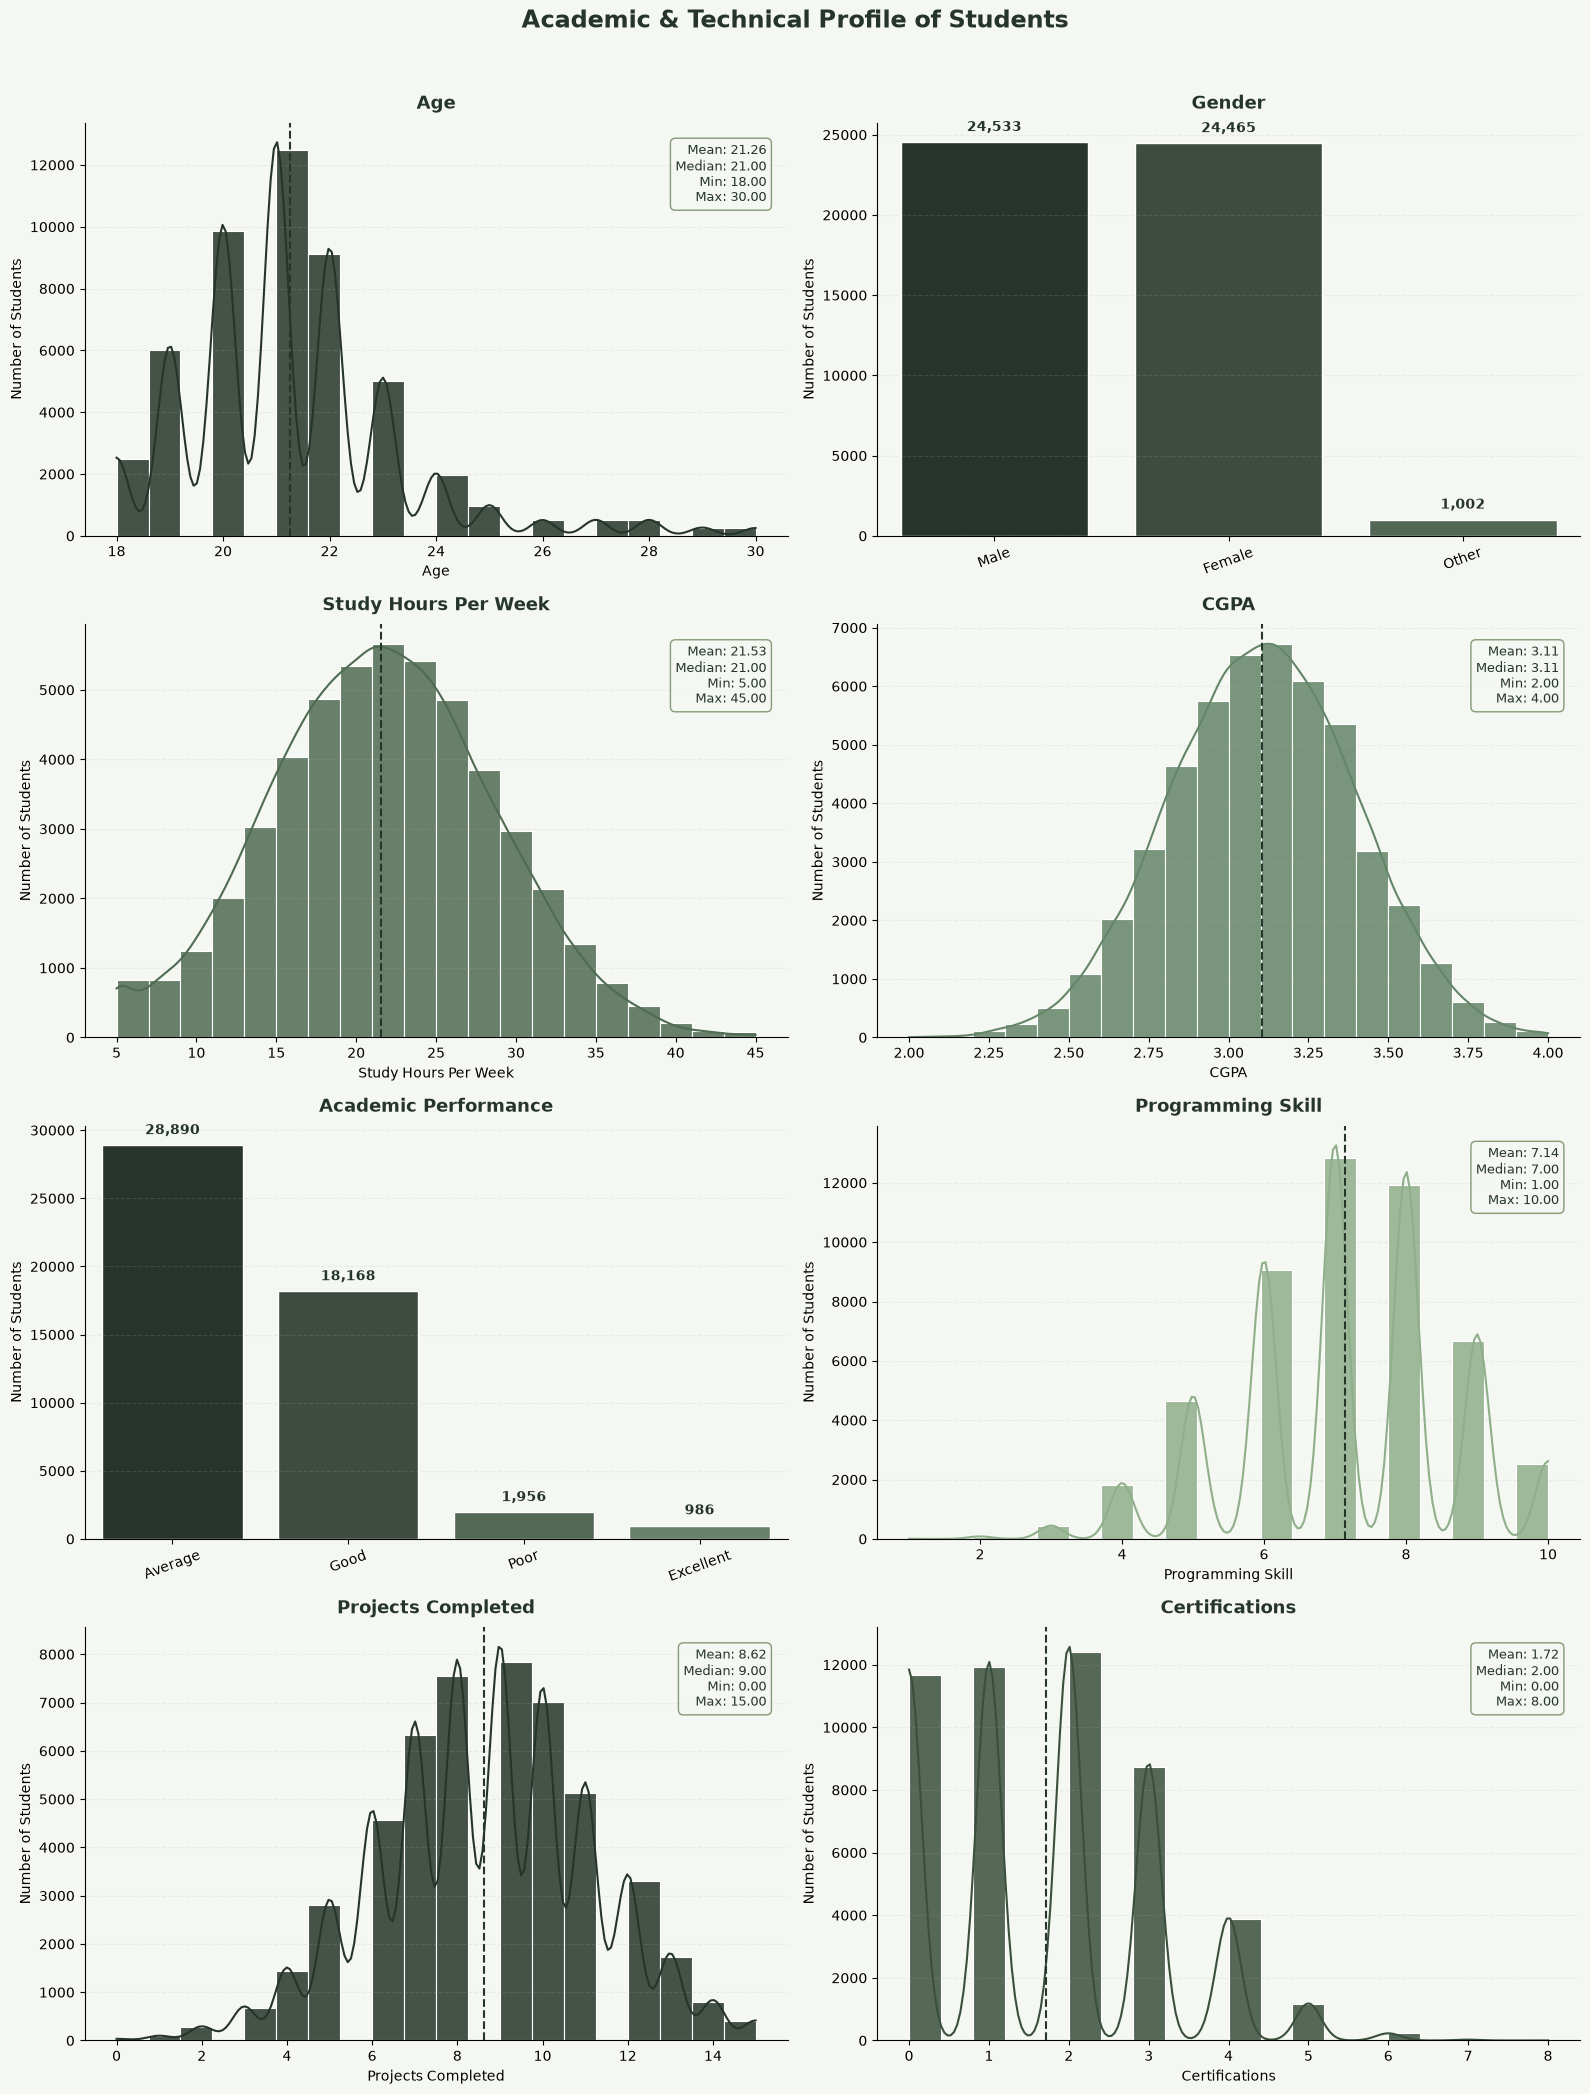

In [19]:
# Academic & Technical Profile of Students
profile_cols_1 = [c for c in ["Age", "Gender", "Study_Hours_Per_Week", "CGPA", "Academic_Performance", "Programming_Skill", "Projects_Completed", "Certifications"] if c in df.columns]
tones = ["#26352A", "#3A4F3C", "#4F6B52", "#648568", "#7F966F", "#8FAE8A"]
bg = "#F4F7F2"
fig, axes = plt.subplots(4, 2, figsize=(16, 21), facecolor=bg)
axes = axes.flatten()

for i, col in enumerate(profile_cols_1):
    ax = axes[i]
    ax.set_facecolor(bg)
    ax.spines[["top", "right"]].set_visible(False)

    # Categorical → vertical bar plots
    if not pd.api.types.is_numeric_dtype(df[col]):
        counts = df[col].value_counts()
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=tones[:len(counts)], legend=False, edgecolor="white", linewidth=1, ax=ax)
        for j, value in enumerate(counts.values):
            ax.text(j, value + counts.max() * 0.02, f"{value:,}", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#26352A")
        ax.set_xlabel("")
        ax.set_ylabel("Number of Students")
        ax.tick_params(axis="x", rotation=20)

    # Numeric features distribution & statistics
    else:
        data = df[col].dropna()
        sns.histplot(data, bins=20, kde=True, color=tones[i % len(tones)], edgecolor="white", linewidth=0.8, alpha=0.85, ax=ax)
        mean_val, median_val, min_val, max_val = data.mean(), data.median(), data.min(), data.max()
        ax.axvline(mean_val, linestyle="--", linewidth=1.5, color="#26352A")
        ax.text(0.97, 0.95, f"Mean: {mean_val:.2f}\nMedian: {median_val:.2f}\nMin: {min_val:.2f}\nMax: {max_val:.2f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#26352A",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#F4F7F2", edgecolor="#7F966F", alpha=0.95))
        ax.set_xlabel(col.replace("_", " "))
        ax.set_ylabel("Number of Students")
    ax.set_title(col.replace("_", " "), fontsize=13, fontweight="bold", color="#26352A", pad=10)
    ax.grid(axis="y", linestyle="--", alpha=0.18)

plt.suptitle("Academic & Technical Profile of Students", fontsize=17, fontweight="bold", color="#26352A", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Professional development and employability

In [20]:
prof_numeric = ["Hackathons", "Internships", "Resume_Score", "Communication_Skills"]
prof_summary = (df[prof_numeric].describe().T[["mean", "50%", "std", "min", "25%", "75%", "max"]]
                .rename(columns={"50%": "median", "25%": "q1", "75%": "q3"}))
prof_summary["zero (%)"] = (df[prof_numeric] == 0).mean() * 100
display(prof_summary.round(2))

prof_categorical = ["GitHub_Profile", "Leadership_Experience", "LinkedIn_Profile"]
prof_shares = pd.concat({c: df[c].value_counts(normalize=True).mul(100).round(1) for c in prof_categorical}).rename("Percentage")
display(prof_shares.to_frame())

,mean,median,std,min,q1,q3,max,zero (%)
Hackathons,3.09,3.0,1.66,0.0,2.0,4.0,10.0,6.48
Internships,4.05,4.0,1.01,0.0,3.0,5.0,5.0,0.12
Resume_Score,96.05,100.0,7.33,44.0,95.0,100.0,100.0,0.00
Communication_Skills,8.44,9.0,1.39,3.0,7.0,10.0,10.0,0.00


Percentage
GitHub_Profile        Yes        81.4
                      No         18.6
Leadership_Experience No         60.8
                      Yes        39.2
LinkedIn_Profile      Yes        71.8
                      No         28.2

### Professional development and employability: plots

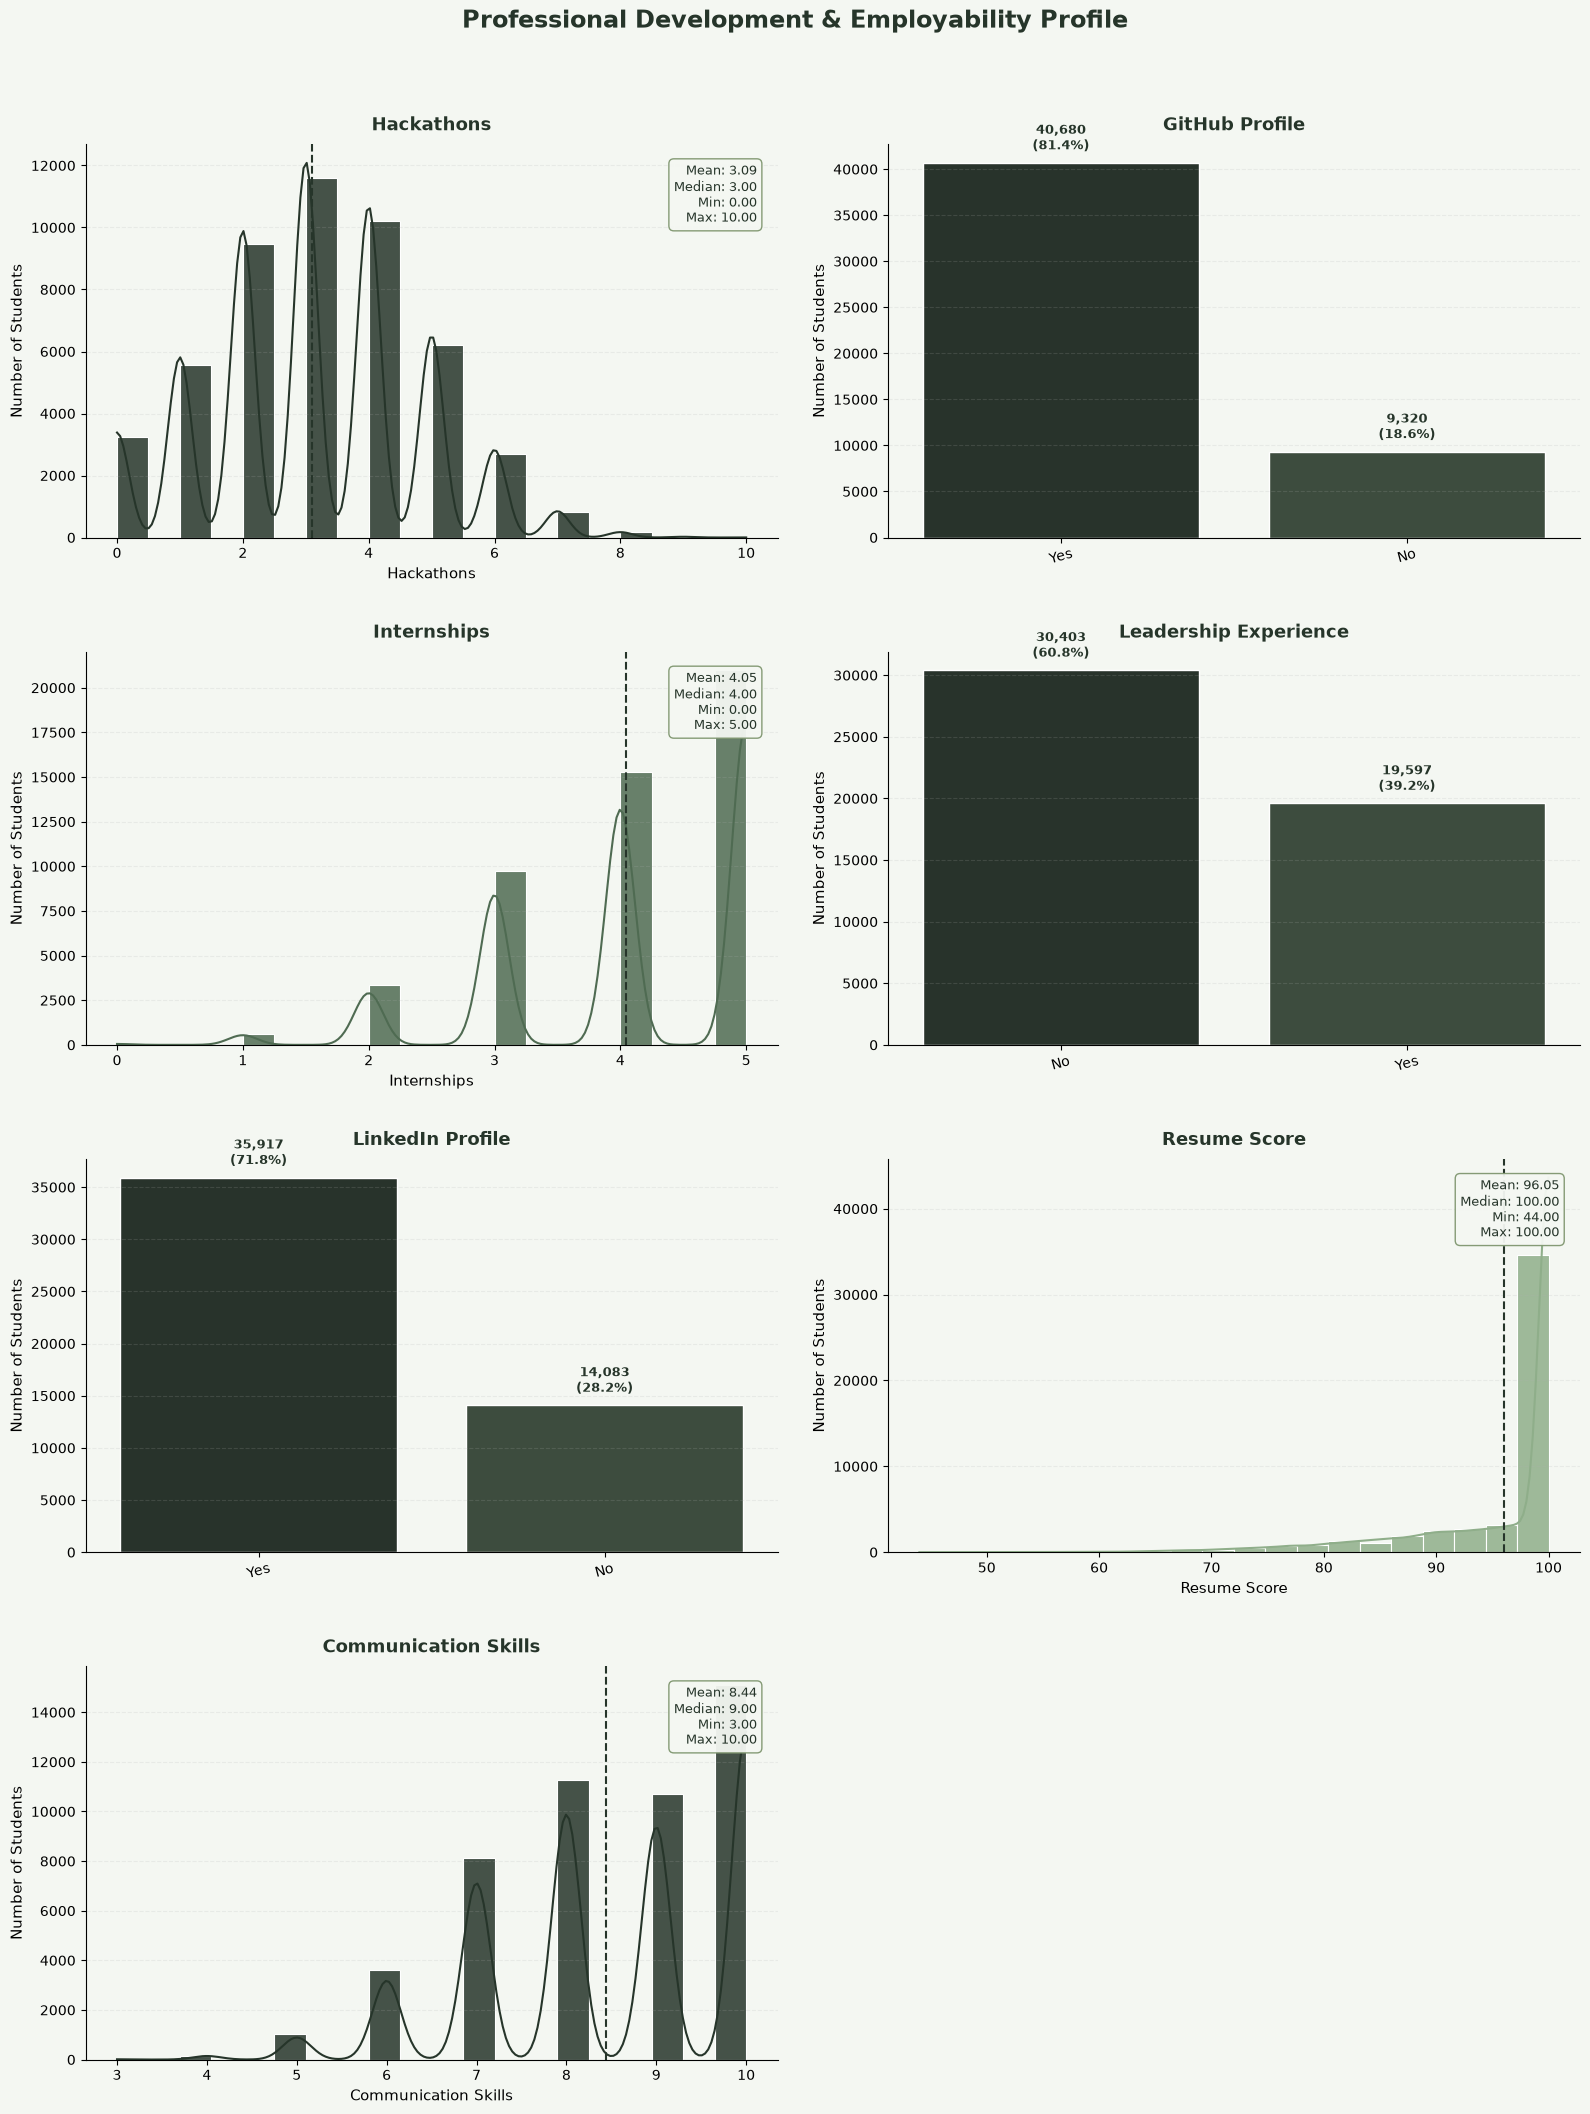

In [21]:
# Professional Development & Employability Profile
profile_cols_2 = [c for c in ["Hackathons", "GitHub_Profile", "Internships", "Leadership_Experience", "LinkedIn_Profile", "Resume_Score", "Communication_Skills"] if c in df.columns]
tones = ["#26352A", "#3A4F3C", "#4F6B52", "#648568", "#7F966F", "#8FAE8A"]
bg = "#F4F7F2"

# Create Figure
n, ncols = len(profile_cols_2), 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.3 * nrows), facecolor=bg)
axes = np.array(axes).flatten()

# Plot Each Feature
for i, col in enumerate(profile_cols_2):
    ax = axes[i]
    ax.set_facecolor(bg)
    ax.spines[["top", "right"]].set_visible(False)

    # Categorical / Yes-No Features
    if not pd.api.types.is_numeric_dtype(df[col]):
        counts = df[col].astype(str).str.strip().value_counts()
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=tones[:len(counts)], legend=False, edgecolor="white", linewidth=1, ax=ax)
        total = counts.sum()
        for j, value in enumerate(counts.values):
            ax.text(j, value + counts.max() * 0.025, f"{value:,}\n({value / total * 100:.1f}%)", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#26352A")
        ax.set_xlabel("")
        ax.set_ylabel("Number of Students", fontsize=11)
        ax.tick_params(axis="x", rotation=15, labelsize=10)

    # Numeric Features
    else:
        data = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(data) > 0:
            sns.histplot(data, bins=20, kde=True, color=tones[i % len(tones)], edgecolor="white", linewidth=0.8, alpha=0.85, ax=ax)
            mean_val, median_val, min_val, max_val = data.mean(), data.median(), data.min(), data.max()
            ax.axvline(mean_val, linestyle="--", linewidth=1.5, color="#26352A")
            ax.text(0.97, 0.95, f"Mean: {mean_val:.2f}\nMedian: {median_val:.2f}\nMin: {min_val:.2f}\nMax: {max_val:.2f}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#26352A",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="#F4F7F2", edgecolor="#7F966F", alpha=0.95))
        ax.set_xlabel(col.replace("_", " "), fontsize=11)
        ax.set_ylabel("Number of Students", fontsize=11)
    ax.set_title(col.replace("_", " "), fontsize=13, fontweight="bold", color="#26352A", pad=10)
    ax.grid(axis="y", linestyle="--", alpha=0.18)
    ax.tick_params(axis="y", labelsize=10)
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

# Main Title & Layout
plt.suptitle("Professional Development & Employability Profile", fontsize=17, fontweight="bold", color="#26352A", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=3.0, w_pad=2.5)
plt.show()

### Skills and employability by placement

In [22]:
analysis_df = df.copy()
analysis_df["Placement_Group"] = np.where(
    analysis_df["Placement_Status"].astype(str).str.strip().str.lower().isin(["placed", "yes", "1", "true"]), "Placed", "Not Placed")
skills = ["Teamwork", "Problem_Solving", "Interview_Score", "Employability_Score"]

placement_distribution = analysis_df["Placement_Group"].value_counts().to_frame("Students")
placement_distribution["Percentage"] = (placement_distribution["Students"] / len(analysis_df) * 100).round(2)
display(placement_distribution)

# Skill statistics per placement group
display(analysis_df.groupby("Placement_Group")[skills].agg(["mean", "median", "std"]).T.round(2))

# Interview score by English proficiency
display(analysis_df.groupby("English_Proficiency")["Interview_Score"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reindex(["Basic", "Intermediate", "Advanced"]).round(2))

skill_comparison = analysis_df.groupby("Placement_Group")[skills].mean().T
skill_comparison["Difference"] = skill_comparison["Placed"] - skill_comparison["Not Placed"]
skill_comparison["Difference (%)"] = skill_comparison["Difference"] / skill_comparison["Not Placed"] * 100
display(skill_comparison.round(2))

,Students,Percentage
Placement_Group,,
Placed,39040,78.08
Not Placed,10960,21.92


Placement_Group             Not Placed  Placed
Teamwork            mean          6.58    7.13
                    median        6.00    7.00
                    std           1.56    1.60
Problem_Solving     mean          6.07    7.48
                    median        6.00    8.00
                    std           1.63    1.55
Interview_Score     mean         67.96   80.20
                    median       68.00   81.00
                    std          12.91   11.09
Employability_Score mean        190.06  220.71
                    median      191.40  223.10
                    std          27.24   22.52

,count,mean,median,std,min,max
English_Proficiency,,,,,,
Basic,640,52.91,52.0,12.11,17,91
Intermediate,9720,67.24,68.0,12.18,23,100
Advanced,39640,80.43,81.0,10.80,35,100


Placement_Group,Not Placed,Placed,Difference,Difference (%)
Teamwork,6.58,7.13,0.55,8.31
Problem_Solving,6.07,7.48,1.41,23.20
Interview_Score,67.96,80.20,12.24,18.00
Employability_Score,190.06,220.71,30.65,16.13


### Skills and employability: plots

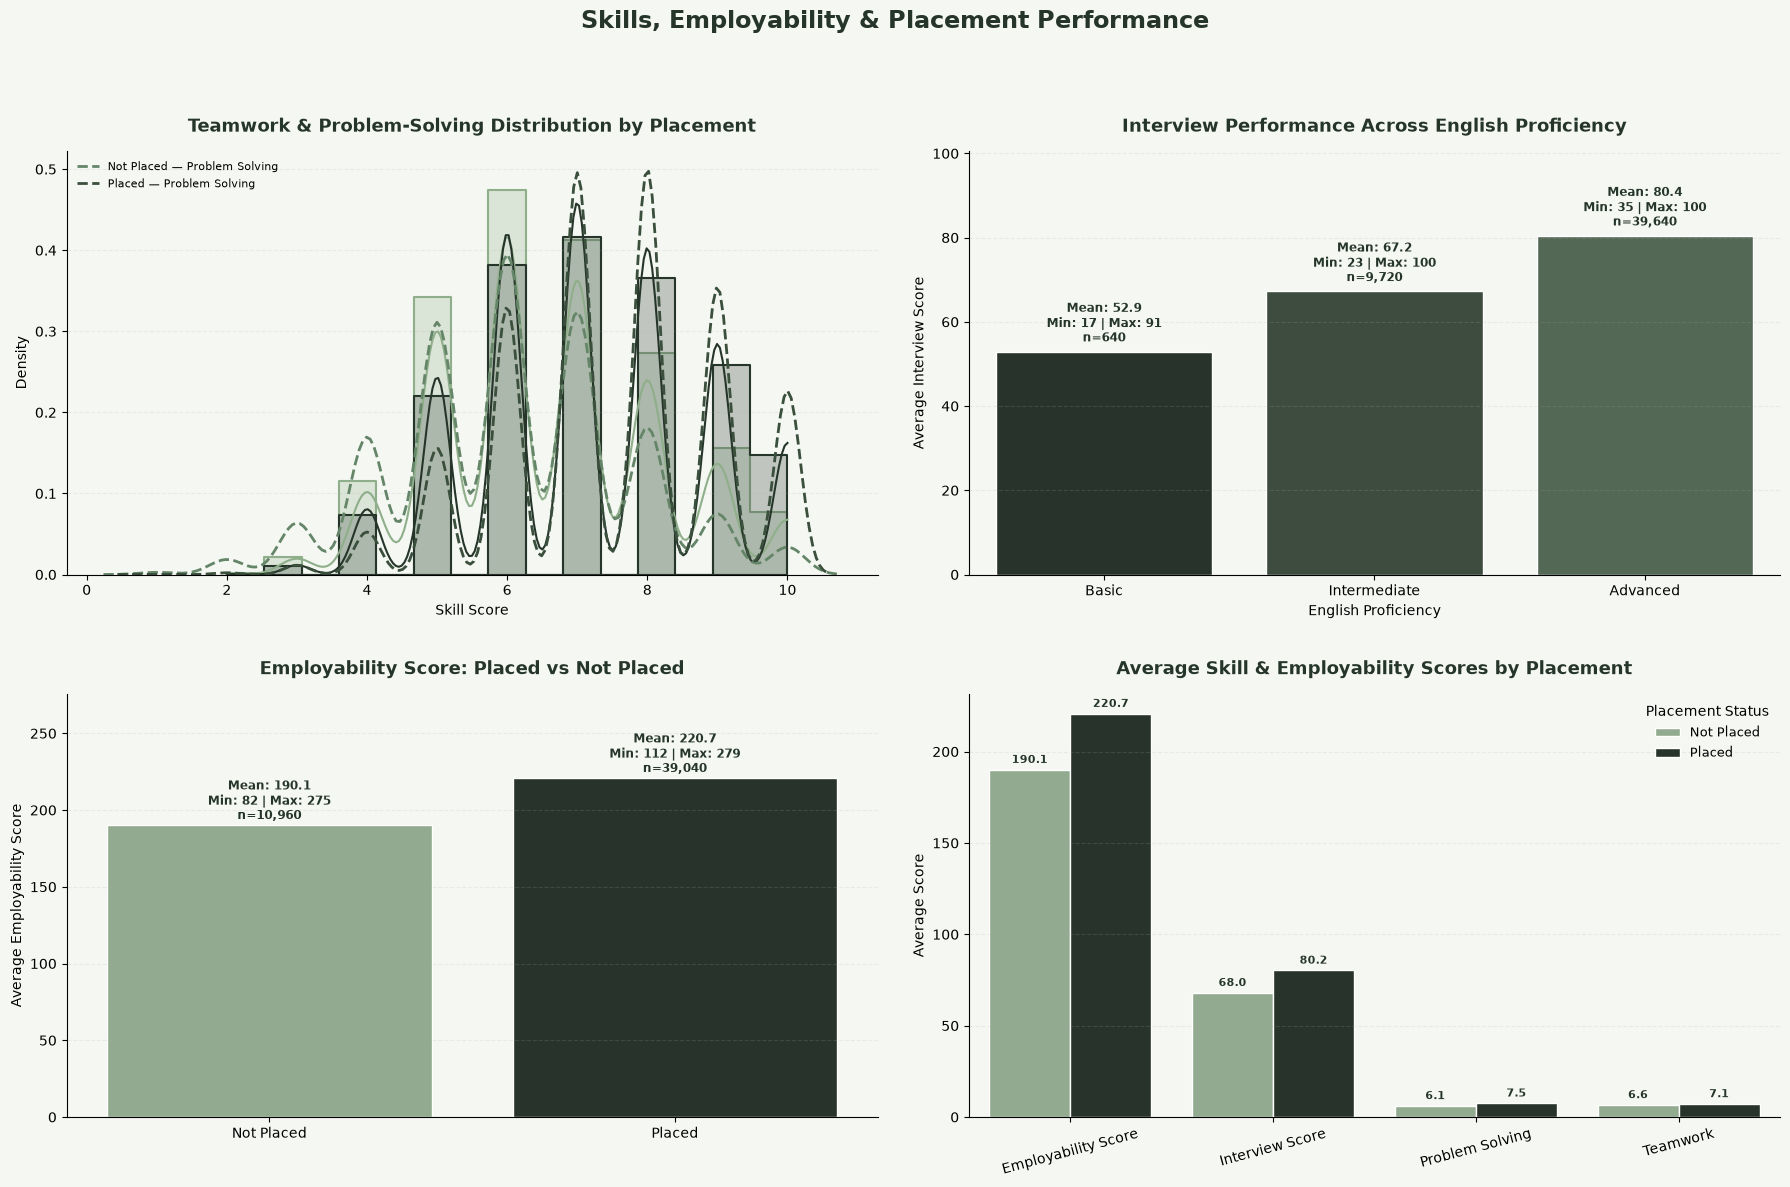

In [23]:
tones = ["#26352A", "#3A4F3C", "#4F6B52", "#648568", "#7F966F", "#8FAE8A"]
bg = "#F4F7F2"

# Create clean placement flag
plot_df = df.copy()
plot_df["Placed_Flag"] = plot_df["Placement_Status"].astype(str).str.strip().str.lower().isin(["placed", "yes", "1", "true"]).astype(int)
plot_df["Placement_Group"] = plot_df["Placed_Flag"].map({0: "Not Placed", 1: "Placed"})

# Figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=bg)
axes = axes.flatten()
for ax in axes:
    ax.set_facecolor(bg)
    ax.spines[["top", "right"]].set_visible(False)

# Distribution of Teamwork & Problem-Solving by Placement
sns.histplot(data=plot_df, x="Teamwork", hue="Placement_Group", bins=15, kde=True, element="step",
             stat="density", common_norm=False, palette={"Not Placed": "#8FAE8A", "Placed": "#26352A"},
             alpha=0.25, linewidth=1.5, ax=axes[0])
for status, color in [("Not Placed", "#648568"), ("Placed", "#3A4F3C")]:
    subset = plot_df[plot_df["Placement_Group"] == status]["Problem_Solving"].dropna()
    if len(subset) > 1:
        sns.kdeplot(subset, ax=axes[0], color=color, linewidth=2, linestyle="--", label=f"{status} — Problem Solving")
axes[0].set_title("Teamwork & Problem-Solving Distribution by Placement", fontsize=13, fontweight="bold", color="#26352A", pad=14)
axes[0].set_xlabel("Skill Score")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")

# Interview Score by English Proficiency
interview_df = plot_df.dropna(subset=["English_Proficiency", "Interview_Score"]).copy()
interview_df["English_Display"] = interview_df["English_Proficiency"].astype(str).str.strip().str.title()
available_english = [x for x in ["Basic", "Intermediate", "Advanced"] if x in interview_df["English_Display"].unique()]
interview_stats = interview_df.groupby("English_Display")["Interview_Score"].agg(["mean", "min", "max", "count"]).reindex(available_english).dropna(how="all")
sns.barplot(data=interview_stats.reset_index(), x="English_Display", y="mean", hue="English_Display",
            palette=tones[:len(interview_stats)], legend=False, edgecolor="white", ax=axes[1])
for i, row in enumerate(interview_stats.itertuples()):
    axes[1].text(i, row.mean + 1.5, f"Mean: {row.mean:.1f}\nMin: {row.min:.0f} | Max: {row.max:.0f}\nn={int(row.count):,}",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#26352A")
axes[1].set_title("Interview Performance Across English Proficiency", fontsize=13, fontweight="bold", color="#26352A", pad=14)
axes[1].set_xlabel("English Proficiency")
axes[1].set_ylabel("Average Interview Score")
axes[1].set_ylim(0, interview_stats["mean"].max() * 1.25)

# Employability Score by Placement Status
employability_stats = plot_df.groupby("Placement_Group")["Employability_Score"].agg(["mean", "min", "max", "count"]).reindex(["Not Placed", "Placed"])
sns.barplot(data=employability_stats.reset_index(), x="Placement_Group", y="mean", hue="Placement_Group",
            palette=["#8FAE8A", "#26352A"], legend=False, edgecolor="white", ax=axes[2])
for i, row in enumerate(employability_stats.itertuples()):
    if pd.notna(row.mean):
        axes[2].text(i, row.mean + 1.5, f"Mean: {row.mean:.1f}\nMin: {row.min:.0f} | Max: {row.max:.0f}\nn={int(row.count):,}",
                     ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#26352A")
axes[2].set_title("Employability Score: Placed vs Not Placed", fontsize=13, fontweight="bold", color="#26352A", pad=14)
axes[2].set_xlabel("")
axes[2].set_ylabel("Average Employability Score")
axes[2].set_ylim(0, employability_stats["mean"].max() * 1.25)

# Skill Comparison by Placement Status
skill_cols = [c for c in ["Teamwork", "Problem_Solving", "Interview_Score", "Employability_Score"] if c in plot_df.columns]
skill_long = plot_df[["Placement_Group"] + skill_cols].melt(id_vars="Placement_Group", var_name="Skill", value_name="Score")
skill_means = skill_long.groupby(["Skill", "Placement_Group"])["Score"].mean().reset_index()
skill_means["Skill"] = skill_means["Skill"].str.replace("_", " ")
sns.barplot(data=skill_means, x="Skill", y="Score", hue="Placement_Group", palette=["#8FAE8A", "#26352A"], edgecolor="white", ax=axes[3])
for container in axes[3].containers:
    axes[3].bar_label(container, fmt="%.1f", padding=3, fontsize=8, color="#26352A", fontweight="bold")
axes[3].set_title("Average Skill & Employability Scores by Placement", fontsize=13, fontweight="bold", color="#26352A", pad=14)
axes[3].set_xlabel("")
axes[3].set_ylabel("Average Score")
axes[3].tick_params(axis="x", rotation=15)
axes[3].legend(title="Placement Status", frameon=False, fontsize=9)

# General formatting
for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.18)

plt.suptitle("Skills, Employability & Placement Performance", fontsize=17, fontweight="bold", color="#26352A", y=0.985)
plt.tight_layout(rect=[0, 0, 1, 0.94], h_pad=3.0, w_pad=2.5)
plt.show()

### Placement and salary outcomes

`Company_Tier`, `Placement_Mode` and salary are only known after placement. We analyse them here but exclude them from modelling. Differences between groups are associations, not causal effects.

In [24]:
analysis_df = df.copy()
analysis_df["Placed_Flag"] = analysis_df["Placement_Status"].astype(str).str.strip().str.lower().isin(["placed", "yes", "1", "true"]).astype(int)
print(f"Overall placement rate: {analysis_df['Placed_Flag'].mean() * 100:.1f}% "
      f"({analysis_df['Placed_Flag'].sum():,} of {len(analysis_df):,} students)")

# Placement rate by company tier
tier_stats = analysis_df.groupby("Company_Tier")["Placed_Flag"].agg(Students="size", Placed="sum", Placement_Rate="mean")
tier_stats["Placement_Rate"] *= 100
display(tier_stats.sort_values("Placement_Rate", ascending=False).round(2))

tier_contingency = pd.crosstab(analysis_df["Company_Tier"], analysis_df["Placed_Flag"])
if min(tier_contingency.shape) > 1:
    chi2_stat, tier_p, _, _ = chi2_contingency(tier_contingency)
    tier_v = np.sqrt(chi2_stat / tier_contingency.to_numpy().sum() / (min(tier_contingency.shape) - 1))
    print(f"Company tier vs placement: chi-square p = {tier_p:.4g}, Cramer's V = {tier_v:.3f}")

# Starting salary by placement mode (placed students only)
salary_df = analysis_df[analysis_df["Starting_Salary_USD"] > 0]
salary_stats = (salary_df.groupby("Placement_Mode")["Starting_Salary_USD"]
                .agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False))
display(salary_stats.round(0))

if salary_df["Placement_Mode"].nunique() > 1:
    groups = [g for _, g in salary_df.groupby("Placement_Mode")["Starting_Salary_USD"]]
    h_stat, salary_p = kruskal(*groups)
    epsilon_sq = max(0, (h_stat - len(groups) + 1) / (len(salary_df) - len(groups)))
    print(f"Salary vs placement mode: Kruskal-Wallis p = {salary_p:.4g}, effect size = {epsilon_sq:.3f}")

mean_salary, median_salary = salary_df["Starting_Salary_USD"].mean(), salary_df["Starting_Salary_USD"].median()
print(f"Mean salary ${mean_salary:,.0f} vs median ${median_salary:,.0f} "
      f"({abs(mean_salary - median_salary) / median_salary * 100:.1f}% difference)")

Overall placement rate: 78.1% (39,040 of 50,000 students)


,Students,Placed,Placement_Rate
Company_Tier,,,
Tier 1,37152,37152,100.0
Tier 2,1751,1751,100.0
Tier 3,137,137,100.0
No Company,10960,0,0.0


Company tier vs placement: chi-square p = 0, Cramer's V = 1.000


,count,mean,median,std,min,max
Placement_Mode,,,,,,
Internship Conversion,7674,88425.0,89075.0,13502.0,25337,109999
Campus Placement,19619,88380.0,89113.0,13636.0,25096,110000
Referral,3930,88273.0,88548.0,13561.0,25952,110000
Off-Campus,7817,88269.0,89047.0,13670.0,25552,109997


Salary vs placement mode: Kruskal-Wallis p = 0.8068, effect size = 0.000
Mean salary $88,356 vs median $89,025 (0.8% difference)


### Placement and salary outcomes: plots

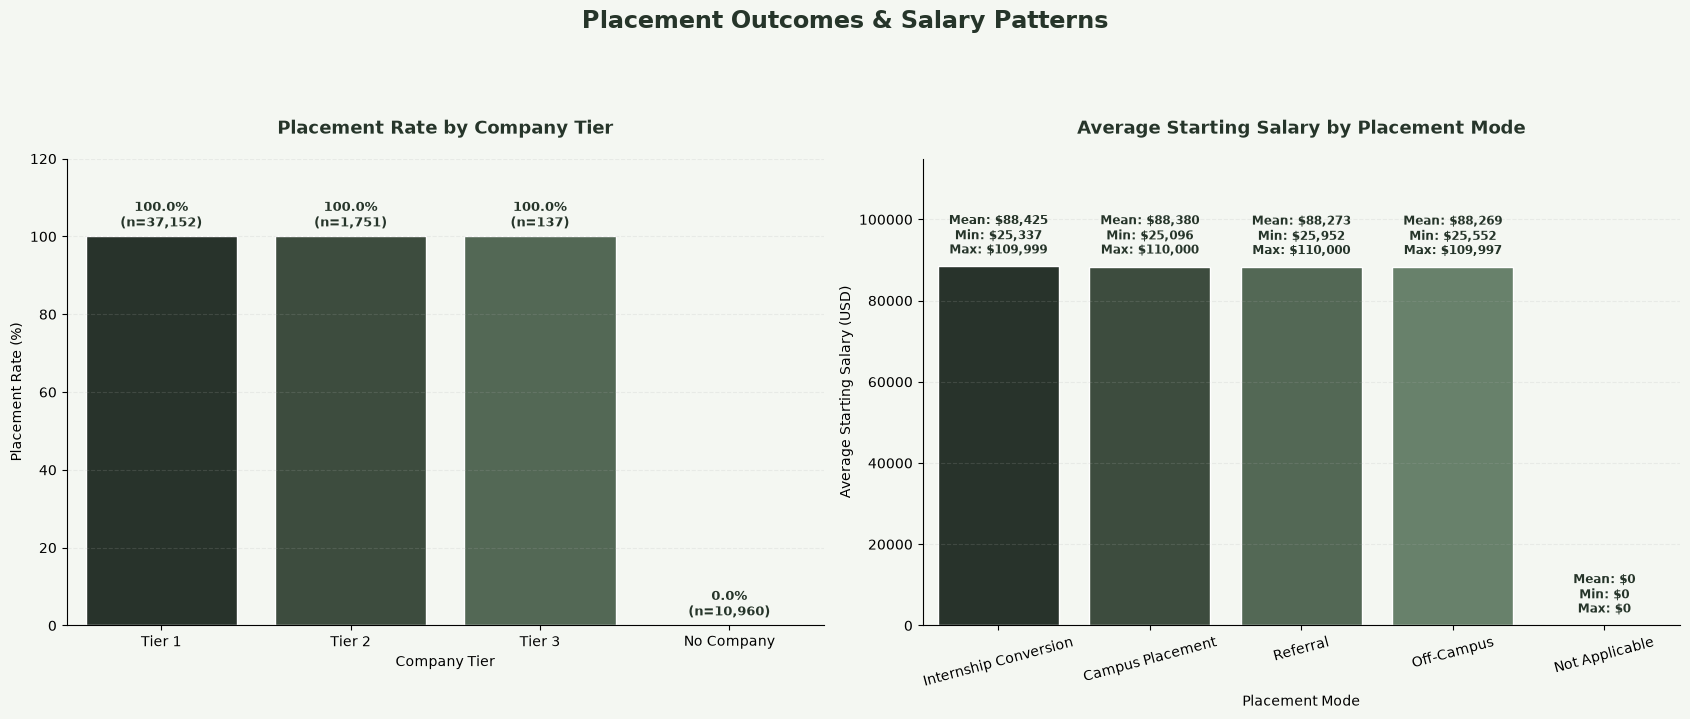

In [25]:
# Placement Rate & Starting Salary Analysis
tones = ["#26352A", "#3A4F3C", "#4F6B52", "#648568", "#7F966F", "#8FAE8A"]
bg = "#F4F7F2"
df_plot = df.copy()
df_plot["Placed"] = df_plot["Placement_Status"].astype(str).str.strip().str.lower().isin(["placed", "yes", "1"]).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(17, 7), facecolor=bg)
for ax in axes:
    ax.set_facecolor(bg)
    ax.spines[["top", "right"]].set_visible(False)

# Placement Rate by Company Tier
tier_stats = df_plot.groupby("Company_Tier").agg(Placement_Rate=("Placed", "mean"), Students=("Placed", "size")).sort_values("Placement_Rate", ascending=False)
tier_stats["Placement_Rate"] *= 100
sns.barplot(data=tier_stats.reset_index(), x="Company_Tier", y="Placement_Rate", hue="Company_Tier",
            palette=tones[:len(tier_stats)], legend=False, edgecolor="white", ax=axes[0])
for i, row in enumerate(tier_stats.itertuples()):
    axes[0].text(i, row.Placement_Rate + 1.5, f"{row.Placement_Rate:.1f}%\n(n={row.Students:,})",
                 ha="center", va="bottom", fontsize=9, fontweight="bold", color="#26352A")
axes[0].set_title("Placement Rate by Company Tier", fontsize=13, fontweight="bold", color="#26352A", pad=18)
axes[0].set_xlabel("Company Tier")
axes[0].set_ylabel("Placement Rate (%)")
axes[0].set_ylim(0, max(tier_stats["Placement_Rate"]) * 1.20)
axes[0].grid(axis="y", linestyle="--", alpha=0.18)

# Average Starting Salary by Placement Mode
salary_stats = df_plot.groupby("Placement_Mode")["Starting_Salary_USD"].agg(["mean", "min", "max", "count"]).sort_values("mean", ascending=False)
sns.barplot(data=salary_stats.reset_index(), x="Placement_Mode", y="mean", hue="Placement_Mode",
            palette=tones[:len(salary_stats)], legend=False, edgecolor="white", ax=axes[1])
for i, row in enumerate(salary_stats.itertuples()):
    axes[1].text(i, row.mean + salary_stats["mean"].max() * 0.025,
                 f"Mean: ${row.mean:,.0f}\nMin: ${row.min:,.0f}\nMax: ${row.max:,.0f}",
                 ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#26352A")
axes[1].set_title("Average Starting Salary by Placement Mode", fontsize=13, fontweight="bold", color="#26352A", pad=18)
axes[1].set_xlabel("Placement Mode")
axes[1].set_ylabel("Average Starting Salary (USD)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_ylim(0, salary_stats["mean"].max() * 1.30)
axes[1].grid(axis="y", linestyle="--", alpha=0.18)
plt.suptitle("Placement Outcomes & Salary Patterns", fontsize=17, fontweight="bold", color="#26352A", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### Target distribution

The classes are imbalanced, so we use a stratified split and rank models by **F1** rather than accuracy alone.

In [26]:
target_counts = df["Placement_Status"].value_counts()
target_report = target_counts.to_frame("Count")
target_report["Percentage"] = (target_report["Count"] / target_report["Count"].sum() * 100).round(2)
display(target_report)

balance_ratio = target_counts.min() / target_counts.max()
balance_label = ("well balanced" if balance_ratio >= 0.8 else "moderately balanced" if balance_ratio >= 0.5
                 else "imbalanced" if balance_ratio >= 0.2 else "highly imbalanced")
print(f"Minority / majority ratio: {balance_ratio:.2f} ({balance_label})")

,Count,Percentage
Placement_Status,,
Placed,39040,78.08
Not Placed,10960,21.92


Minority / majority ratio: 0.28 (imbalanced)


findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


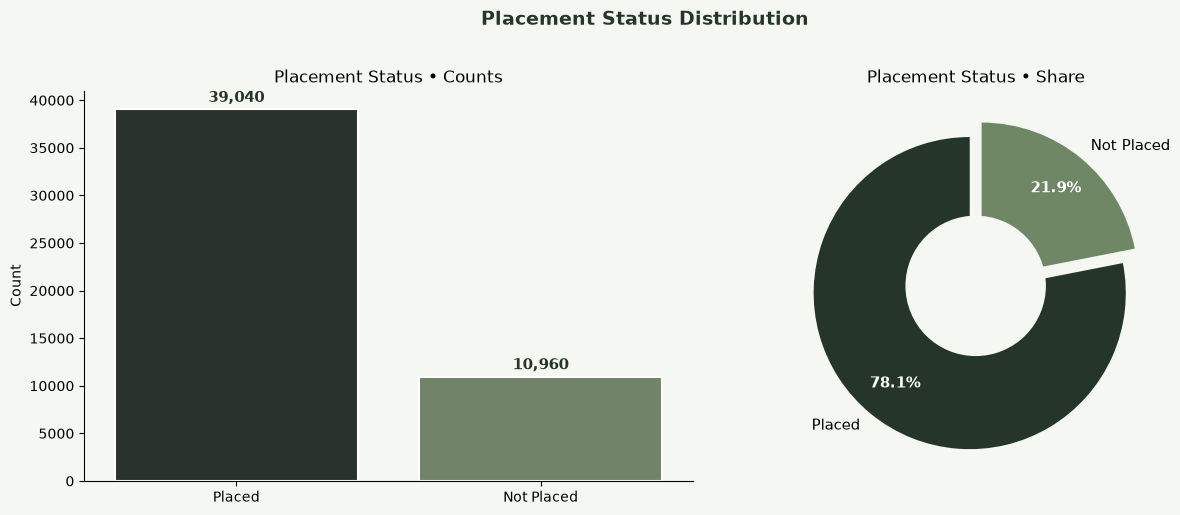

Placement_Status
Placed        39040
Not Placed    10960
Name: count, dtype: int64

Class balance ratio: 0.28  →  imbalanced


In [27]:
# Placement Status distribution
target_counts = df["Placement_Status"].value_counts()
tones = ["#26352A", "#6F8765"][:len(target_counts)]
bg = "#F4F7F2"  # soft matching background

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=bg)
for ax in axes: ax.set_facecolor(bg)

# Bar
sns.barplot(x=target_counts.index, y=target_counts.values, palette=tones, ax=axes[0], edgecolor="white", linewidth=1.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + target_counts.max()*0.02, f"{v:,}", ha="center", fontsize=11, fontweight="bold", color="#26352A")
axes[0].set(title="Placement Status • Counts", xlabel="", ylabel="Count")
axes[0].spines[["top","right"]].set_visible(False)

# Pie
wedges, texts, autotexts = axes[1].pie(
    target_counts.values, labels=target_counts.index, autopct="%1.1f%%",
    colors=tones, startangle=90, explode=[0.06]*len(target_counts),
    pctdistance=0.75, textprops={"fontsize": 11, "fontweight": "medium"}
)
for at in autotexts: at.set_color("white"); at.set_fontweight("bold")
axes[1].set_title("Placement Status • Share")
centre = plt.Circle((0,0), 0.45, fc=bg)
axes[1].add_artist(centre)

plt.suptitle("Placement Status Distribution", fontsize=14, fontweight="bold", color="#26352A", y=1.02)
plt.tight_layout()
plt.show()

print(target_counts)
ratio = target_counts.min() / target_counts.max()
print(f"\nClass balance ratio: {ratio:.2f}  →  {'roughly balanced' if ratio > 0.5 else 'imbalanced'}")

### Numerical feature distributions

In [28]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

def skew_label(s):
    if abs(s) < 0.3:
        return "Approximately symmetric"
    side = "right" if s > 0 else "left"
    return f"{'Moderately' if abs(s) < 1 else 'Strongly'} {side}-skewed"

stats_df = df[numeric_cols].agg(["mean", "median", "std", "min", "max", "skew"]).T
stats_df["CV"] = stats_df["std"] / stats_df["mean"].abs()
stats_df["Distribution"] = stats_df["skew"].map(skew_label)
display(stats_df.round(3))

print(f"Most variable feature (CV): {stats_df['CV'].idxmax()} ({stats_df['CV'].max():.2f})")
print(f"Most consistent feature (CV): {stats_df['CV'].idxmin()} ({stats_df['CV'].min():.2f})")
print(f"Skewed features (|skew| >= 0.3): {(stats_df['skew'].abs() >= 0.3).sum()} of {len(stats_df)}")

,mean,median,std,min,max,skew,CV,Distribution
Age,21.263,21.00,2.041,18.0,30.00,1.267,0.096,Strongly right-skewed
Attendance_Percentage,81.410,82.00,9.710,50.0,100.00,-0.159,0.119,Approximately symmetric
Study_Hours_Per_Week,21.528,21.00,6.975,5.0,45.00,0.060,0.324,Approximately symmetric
CGPA,3.106,3.11,0.290,2.0,4.00,-0.029,0.093,Approximately symmetric
Programming_Skill,7.137,7.00,1.507,1.0,10.00,-0.280,0.211,Approximately symmetric
Projects_Completed,8.621,9.00,2.505,0.0,15.00,-0.080,0.291,Approximately symmetric
Certifications,1.716,2.00,1.368,0.0,8.00,0.510,0.798,Moderately right-skewed
Hackathons,3.094,3.00,1.661,0.0,10.00,0.136,0.537,Approximately symmetric
Internships,4.049,4.00,1.006,0.0,5.00,-0.859,0.248,Moderately left-skewed
Resume_Score,96.046,100.00,7.332,44.0,100.00,-2.206,0.076,Strongly left-skewed


Most variable feature (CV): Certifications (0.80)
Most consistent feature (CV): Resume_Score (0.08)
Skewed features (|skew| >= 0.3): 8 of 16


### Numerical feature distributions: plots

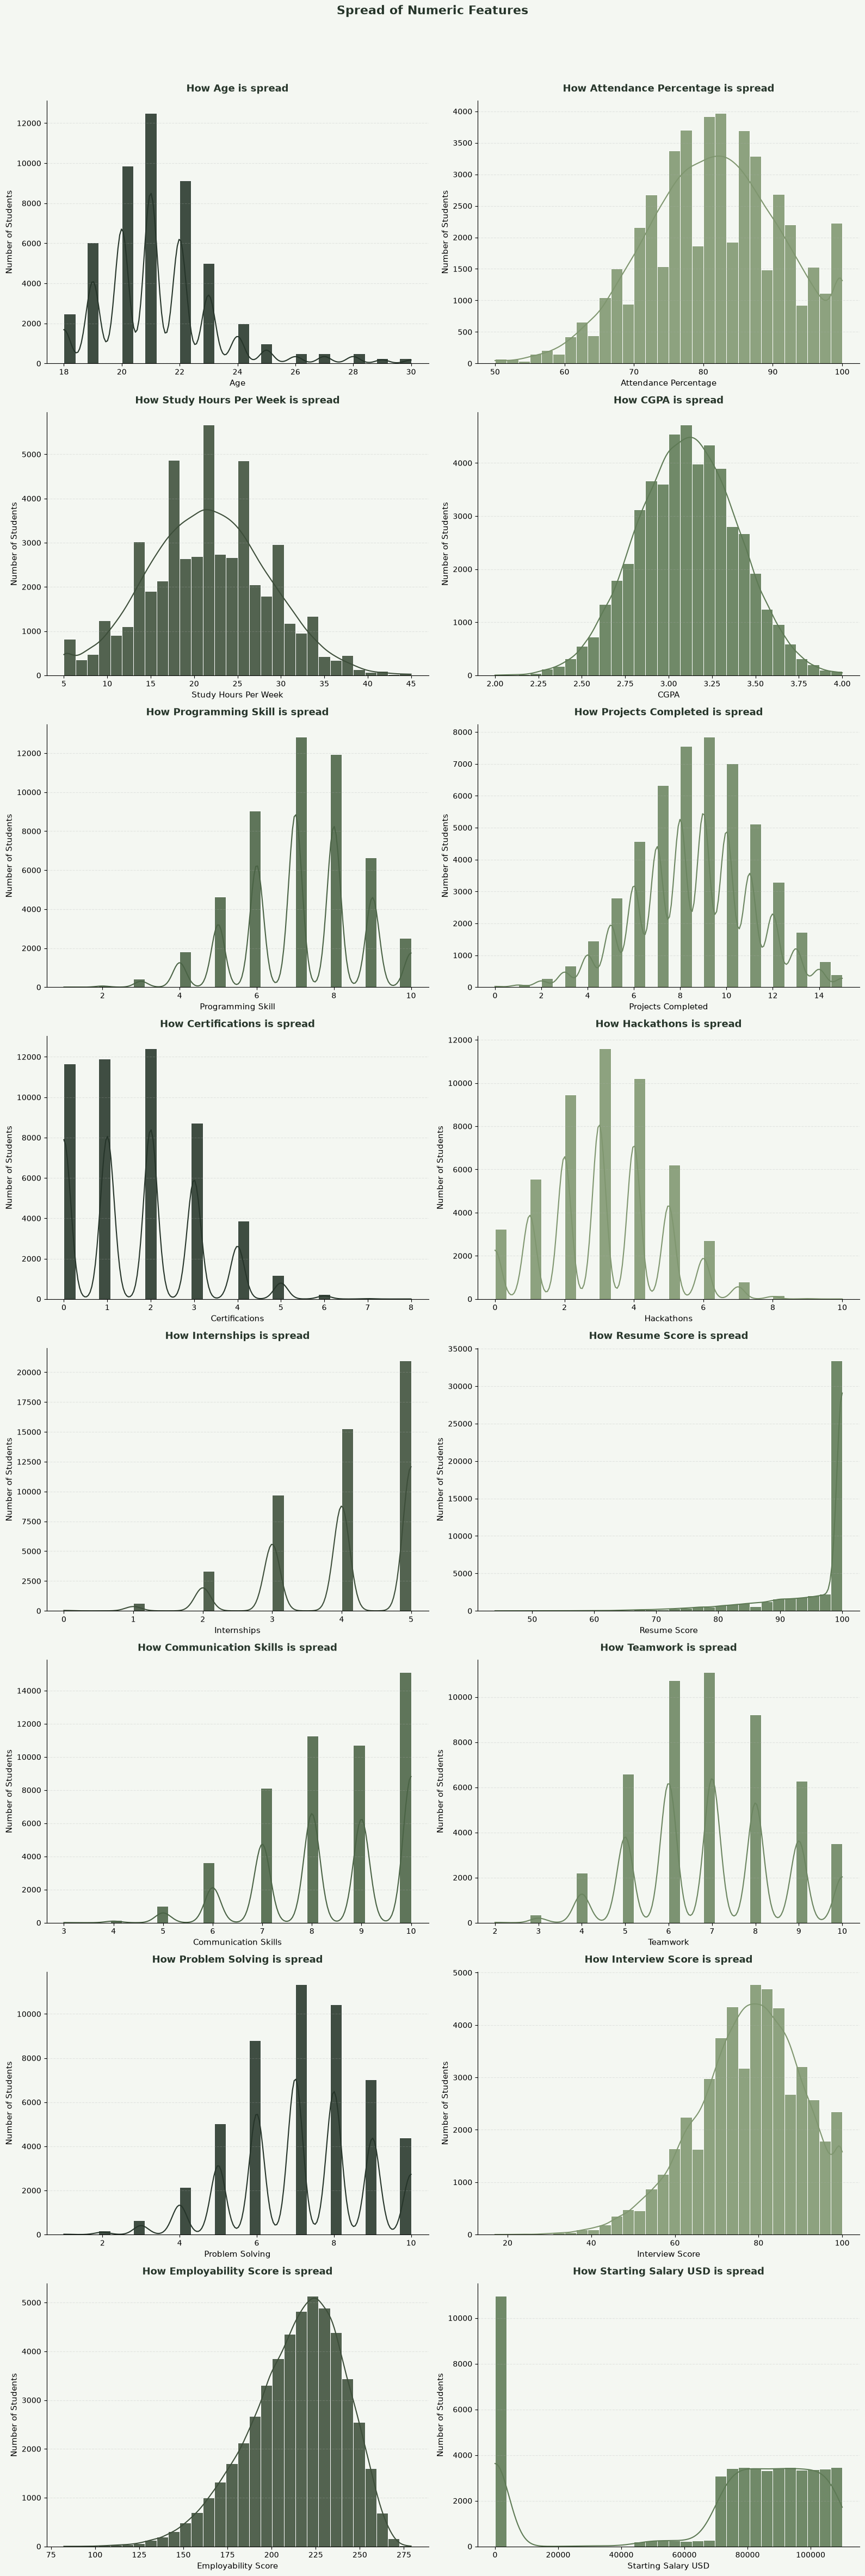

In [29]:
# Numeric Feature Distributions
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != "Student_ID"]
n, ncols = len(numeric_cols), 2
nrows = int(np.ceil(n / ncols))

tones = ["#26352A", "#7F966F", "#3D4E3A", "#5E7A55", "#4A6345", "#6B8560"]
bg = "#F4F7F2"

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.8 * nrows), facecolor=bg)
axes = np.array(axes).flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.set_facecolor(bg)
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax,
                 color=tones[i % len(tones)], edgecolor="white", linewidth=0.7, alpha=0.88)
    ax.set_title(f"How {col.replace('_', ' ')} is spread", 
                 fontsize=13, fontweight="bold", color="#26352A", pad=12)
    ax.set_xlabel(col.replace('_', ' '), fontsize=11)
    ax.set_ylabel("Number of Students", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Spread of Numeric Features", 
             fontsize=16, fontweight="bold", color="#26352A", y=1.02)
plt.tight_layout()
plt.show()

### Categorical feature distributions

In [30]:
categorical_cols = [c for c in df.select_dtypes(exclude="number").columns if c != "Student_ID"]
counts = {c: df[c].value_counts() for c in categorical_cols}
categorical_overview = pd.DataFrame({
    "Unique": {c: len(v) for c, v in counts.items()},
    "Most Common": {c: v.index[0] for c, v in counts.items()},
    "Top Share (%)": {c: v.iloc[0] / v.sum() * 100 for c, v in counts.items()},
    "Min / Max Ratio": {c: v.min() / v.max() for c, v in counts.items()},
}).round(2)
display(categorical_overview)

,Unique,Most Common,Top Share (%),Min / Max Ratio
Gender,3,Male,49.07,0.04
University_Year,4,Junior,29.74,0.66
Major,8,Computer Science,24.81,0.21
Academic_Performance,4,Average,57.78,0.03
GitHub_Profile,2,Yes,81.36,0.23
Leadership_Experience,2,No,60.81,0.64
LinkedIn_Profile,2,Yes,71.83,0.39
English_Proficiency,3,Advanced,79.28,0.02
Placement_Status,2,Placed,78.08,0.28
Company_Tier,4,Tier 1,74.30,0.00


### Categorical feature distributions: plots

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


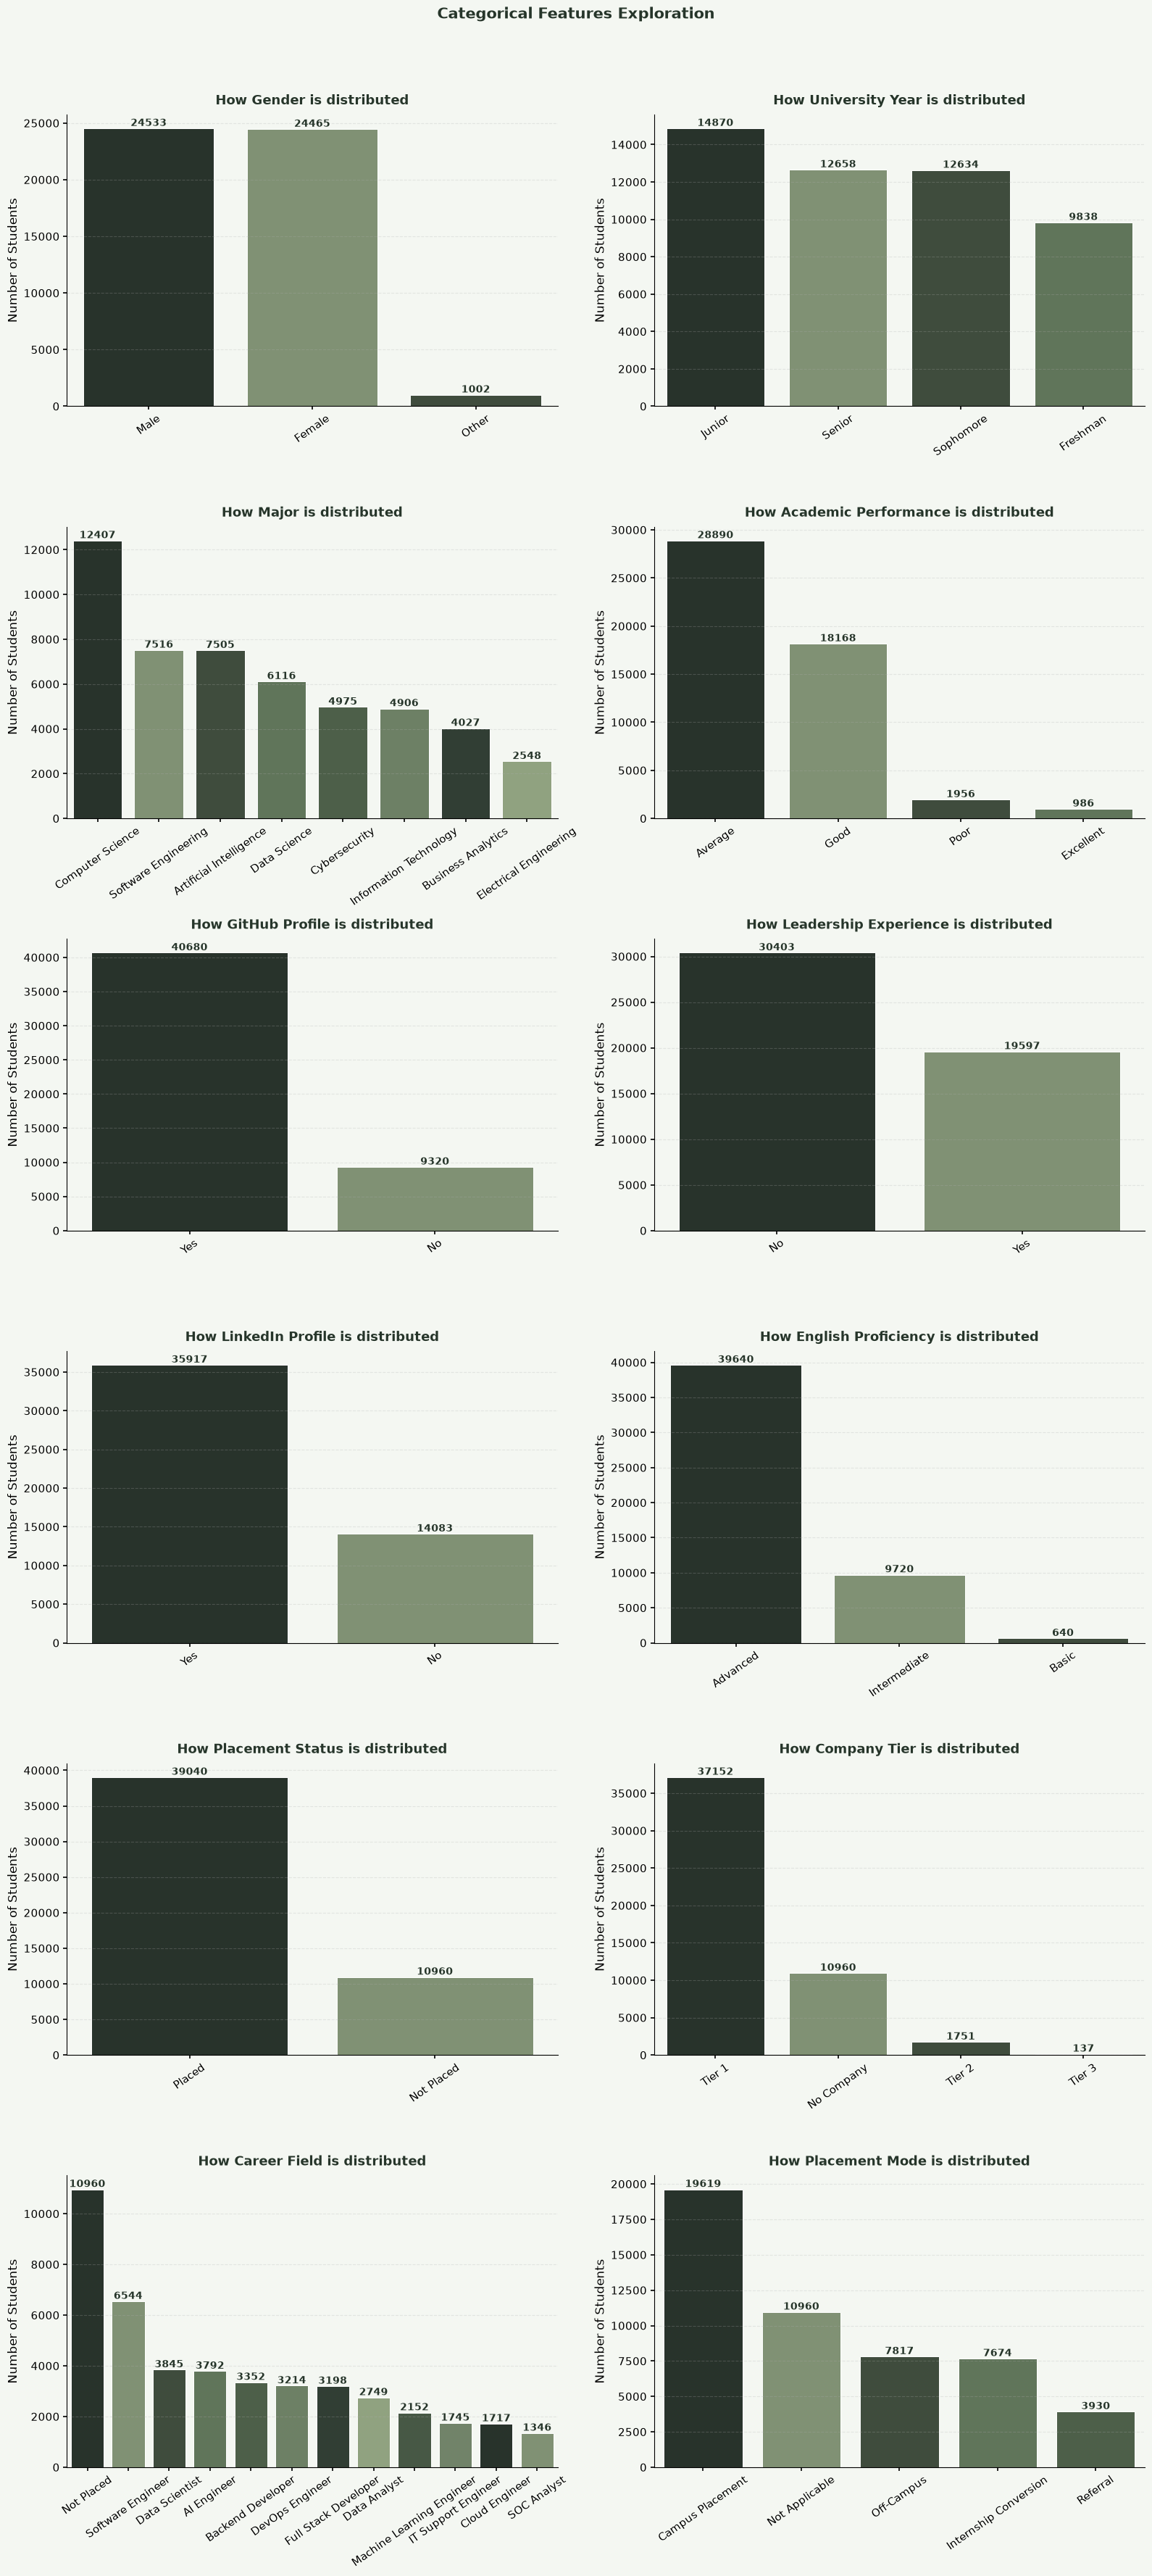

In [31]:
# Categorical Features Distribution
categorical_cols = [c for c in df.select_dtypes(exclude="number").columns if c != "Student_ID"]
n = len(categorical_cols)
ncols = 2
nrows = int(np.ceil(n / ncols))

tones = ["#26352A", "#7F966F", "#3D4E3A", "#5E7A55", "#4A6345", "#6B8560",
         "#2F4033", "#8FA87A", "#455B42", "#6F8765"]
bg = "#F4F7F2"

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.8 * nrows), facecolor=bg)
axes = np.array(axes).flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    ax.set_facecolor(bg)
    
    order = df[col].value_counts().index[:12]
    sns.countplot(x=col, data=df, order=order, ax=ax,
                  palette=tones[:len(order)], edgecolor="white", linewidth=0.7)
    
    # Values above bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{int(height)}",
                        (p.get_x() + p.get_width()/2, height),
                        ha="center", va="bottom",
                        fontsize=10, fontweight="bold", color="#26352A")
    
    ax.set_title(f"How {col.replace('_', ' ')} is distributed", 
                 fontsize=13, fontweight="bold", color="#26352A", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Number of Students", fontsize=12, fontweight="medium")
    ax.tick_params(axis="x", rotation=35, labelsize=11, width=1.2)
    ax.tick_params(axis="y", labelsize=11, width=1.2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("medium")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical Features Exploration", 
             fontsize=15, fontweight="bold", color="#26352A", y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Relationships with Placement

### Numeric features by placement status

In [32]:
key_numeric = ["CGPA", "Programming_Skill", "Interview_Score", "Employability_Score", "Communication_Skills",
               "Resume_Score", "Study_Hours_Per_Week", "Attendance_Percentage", "Projects_Completed", "Certifications"]
placement_group = np.where(df["Placement_Status"].astype(str).str.strip().str.lower().isin(["placed", "yes", "1", "true"]),
                           "Placed", "Not Placed")
means = df.groupby(placement_group)[key_numeric].mean().T
medians = df.groupby(placement_group)[key_numeric].median().T

numeric_vs_placement = pd.DataFrame({
    "Placed Mean": means["Placed"], "Not Placed Mean": means["Not Placed"],
    "Placed Median": medians["Placed"], "Not Placed Median": medians["Not Placed"],
    "Difference (%)": (means["Placed"] - means["Not Placed"]) / means["Not Placed"].abs() * 100,
})
display(numeric_vs_placement.sort_values("Difference (%)", key=abs, ascending=False).round(2))

,Placed Mean,Not Placed Mean,Placed Median,Not Placed Median,Difference (%)
Projects_Completed,9.08,6.99,9.00,7.00,29.83
Programming_Skill,7.43,6.08,7.00,6.00,22.21
Certifications,1.78,1.50,2.00,1.00,18.72
Interview_Score,80.20,67.96,81.00,68.00,18.00
Employability_Score,220.71,190.06,223.10,191.40,16.13
Study_Hours_Per_Week,22.05,19.66,22.00,20.00,12.15
Communication_Skills,8.64,7.72,9.00,8.00,11.96
Resume_Score,97.70,90.16,100.00,93.00,8.36
CGPA,3.15,2.96,3.15,2.95,6.41
Attendance_Percentage,82.36,78.02,83.00,78.00,5.56


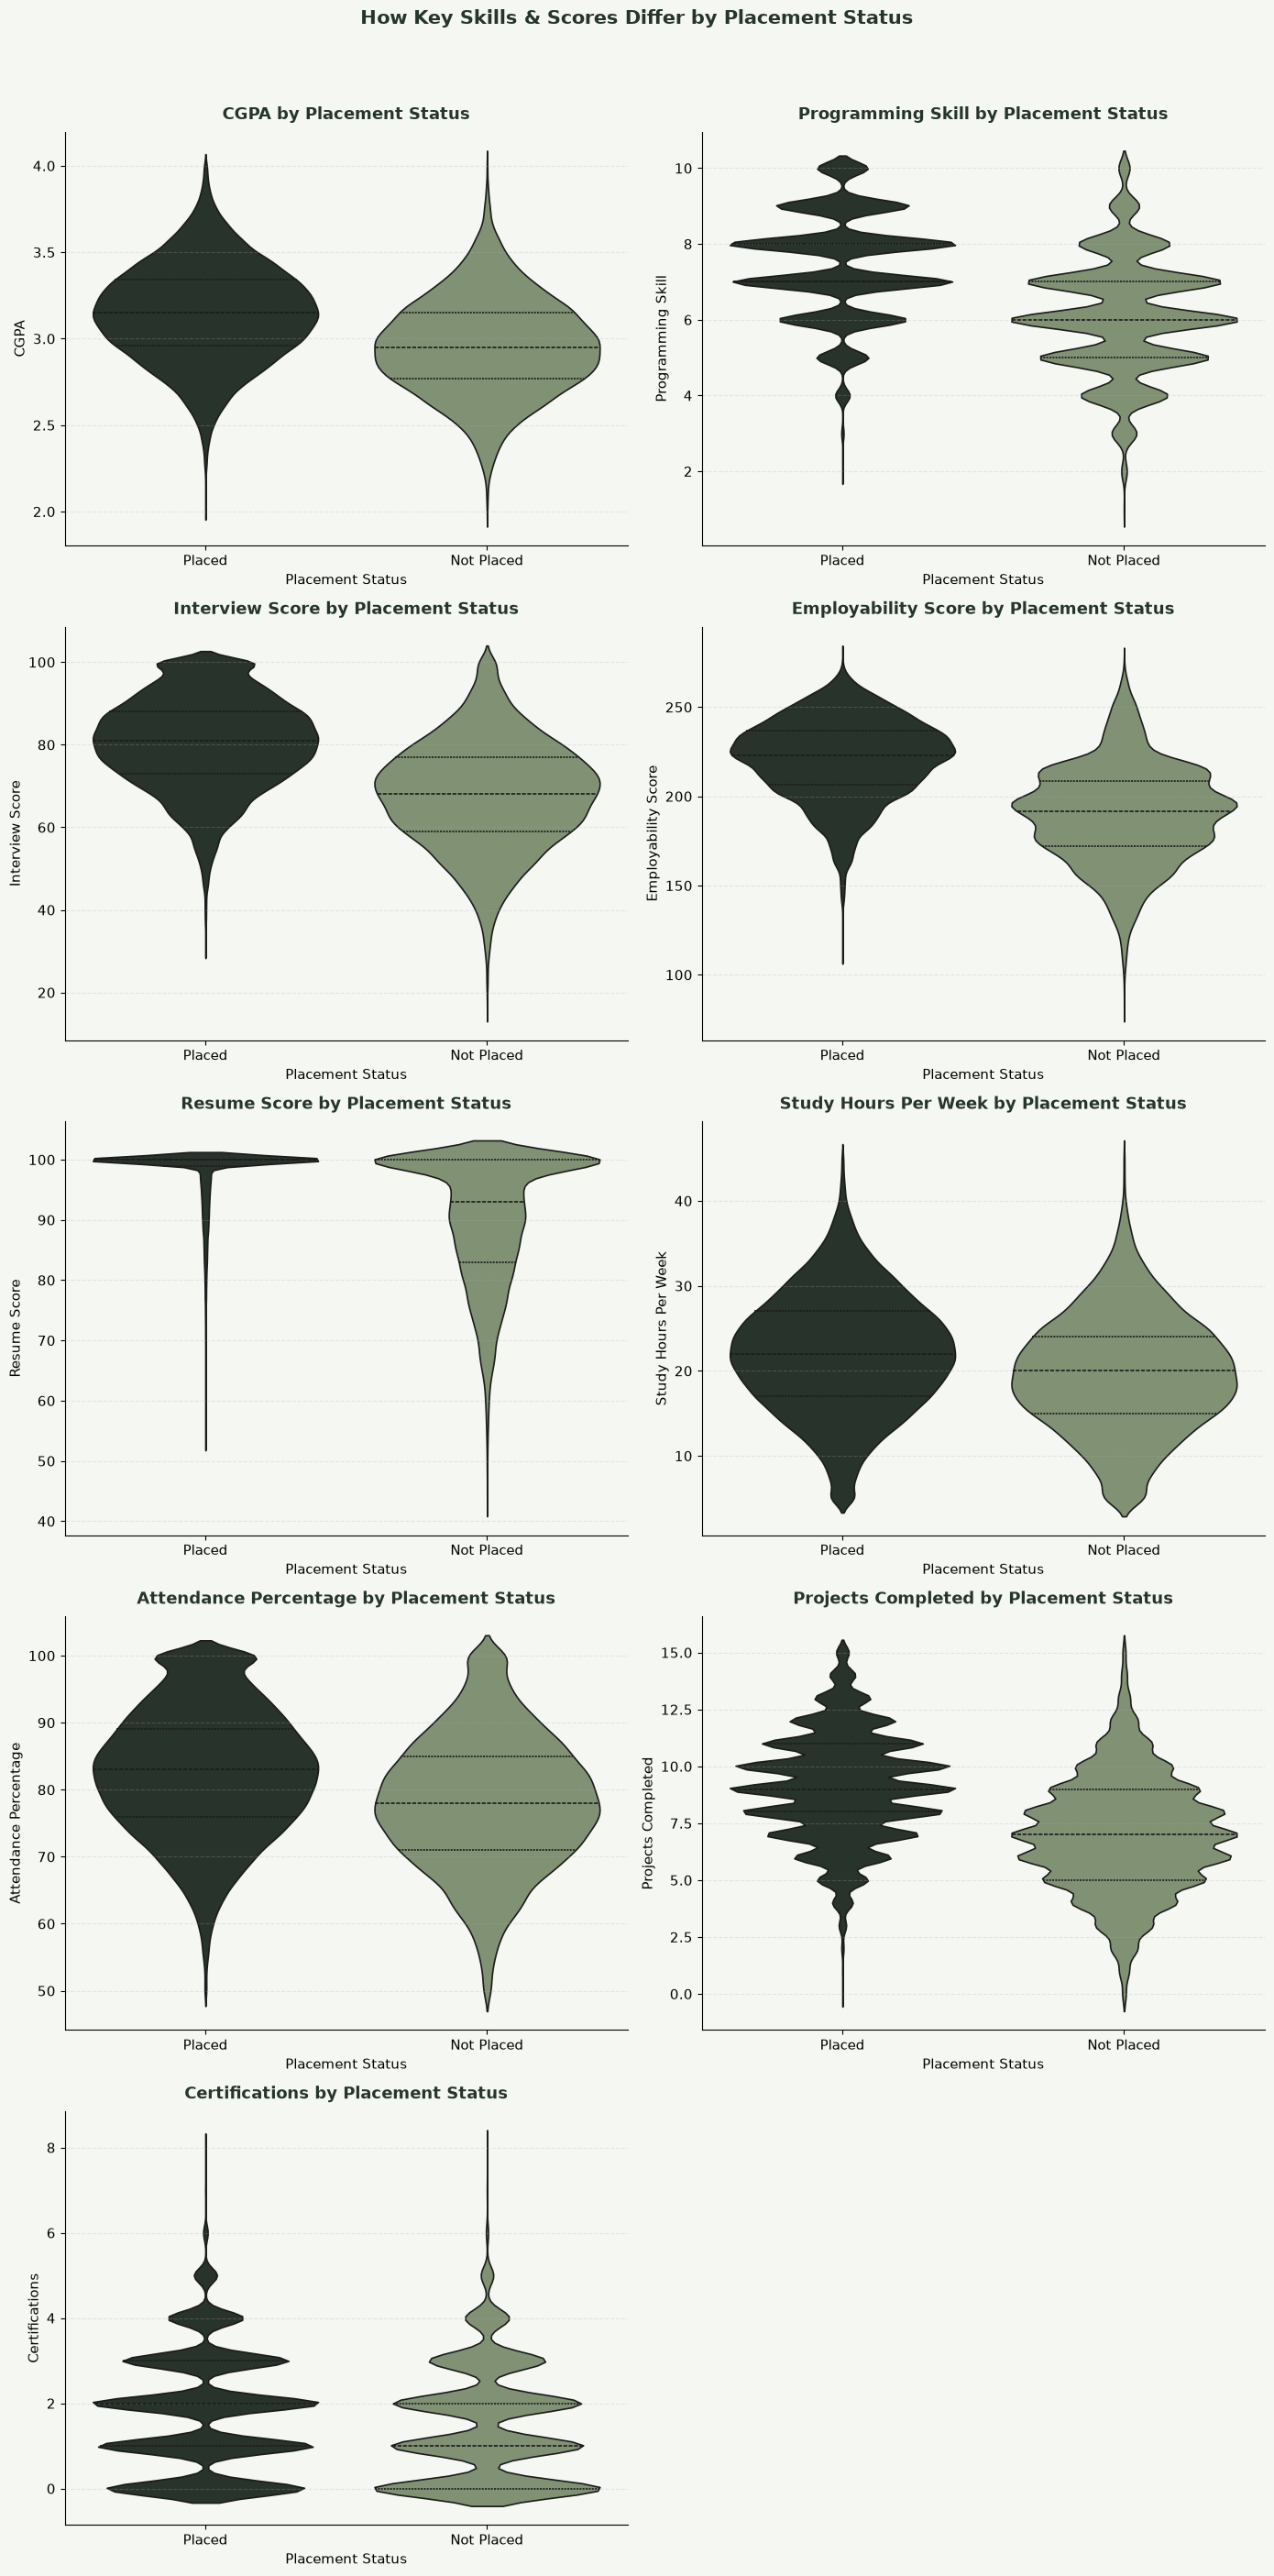

In [33]:
# Key Numeric Features vs Placement Status
key_numeric = [c for c in ["CGPA", "Programming_Skill", "Interview_Score", "Employability_Score",
                           "Communication_Skill", "Resume_Score", "Study_Hours_Per_Week",
                           "Attendance_Percentage", "Projects_Completed", "Certifications"] if c in df.columns]
n, ncols = len(key_numeric), 2
nrows = int(np.ceil(n / ncols))
tones = ["#26352A", "#7F966F", "#3D4E3A", "#5E7A55", "#4A6345", "#6B8560", "#2F4033", "#8FA87A", "#455B42", "#6F8765"]
bg = "#F4F7F2"

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5.5 * nrows), facecolor=bg)
axes = np.array(axes).flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    ax.set_facecolor(bg)
    sns.violinplot(x="Placement_Status", y=col, hue="Placement_Status", data=df, ax=ax,
                   palette=tones[:2], inner="quartile", linewidth=1.2, legend=False)
    ax.set_title(f"{col.replace('_', ' ')} by Placement Status", fontsize=13, fontweight="bold", color="#26352A", pad=10)
    ax.set_xlabel("Placement Status", fontsize=11)
    ax.set_ylabel(col.replace('_', ' '), fontsize=11)
    ax.tick_params(labelsize=11)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("medium")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("How Key Skills & Scores Differ by Placement Status",
             fontsize=15, fontweight="bold", color="#26352A", y=1.02)
plt.tight_layout()
plt.show()

### Placement rate by category

In [34]:
key_categorical = ["Gender", "University_Year", "Major", "Academic_Performance", "Leadership_Experience",
                   "GitHub_Profile", "LinkedIn_Profile", "Placement_Mode", "Company_Tier", "Career_Field"]
placed_flag = df["Placement_Status"].astype(str).str.strip().str.lower().isin(["placed", "yes", "1", "true"]).astype(int)
overall_rate = placed_flag.mean() * 100
print(f"Overall placement rate: {overall_rate:.1f}%")

category_rates = pd.concat({c: placed_flag.groupby(df[c]).agg(Students="size", Placement_Rate="mean") for c in key_categorical})
category_rates["Placement_Rate"] *= 100
category_rates["vs Overall (pp)"] = category_rates["Placement_Rate"] - overall_rate
display(category_rates.round(2))

Overall placement rate: 78.1%


Students  Placement_Rate  \
Gender                Female                        24465           78.06   
                      Male                          24533           78.12   
                      Other                          1002           77.54   
University_Year       Freshman                       9838           79.17   
                      Junior                        14870           77.76   
                      Senior                        12658           77.90   
                      Sophomore                     12634           77.78   
Major                 Artificial Intelligence        7505           86.62   
                      Business Analytics             4027           59.05   
                      Computer Science              12407           79.21   
                      Cybersecurity                  4975           79.64   
                      Data Science                   6116           80.04   
                      Electrical Engineering         2548           60.20   
                      Information Technology         4906           70.57   
                      Software Engineering           7516           86.22   
Academic_Performance  Average                       28890           73.00   
                      Excellent                       986           93.31   
                      Good                          18168           88.50   
                      Poor                           1956           48.67   
Leadership_Experience No                            30403           74.17   
                      Yes                           19597           84.15   
GitHub_Profile        No                             9320           69.14   
                      Yes                           40680           80.13   
LinkedIn_Profile      No                            14083           77.93   
                      Yes                           35917           78.14   
Placement_Mode        Campus Placement              19619          100.00   
                      Internship Conversion          7674          100.00   
                      Not Applicable                10960            0.00   
                      Off-Campus                     7817          100.00   
                      Referral                       3930          100.00   
Company_Tier          No Company                    10960            0.00   
                      Tier 1                        37152          100.00   
                      Tier 2                         1751          100.00   
                      Tier 3                          137          100.00   
Career_Field          AI Engineer                    3792          100.00   
                      Automation Engineer             777          100.00   
                      Backend Developer              3352          100.00   
                      Business Analyst               1236          100.00   
                      Cloud Engineer                 1717          100.00   
                      Cybersecurity Analyst          1318          100.00   
                      Data Analyst                   2749          100.00   
                      Data Scientist                 3845          100.00   
                      DevOps Engineer                3214          100.00   
                      Embedded Systems Engineer       757          100.00   
                      Full Stack Developer           3198          100.00   
                      IT Support Engineer            1745          100.00   
                      Machine Learning Engineer      2152          100.00   
                      Not Placed                    10960            0.00   
                      Penetration Tester             1298          100.00   
                      SOC Analyst                    1346          100.00   
                      Software Engineer              6544          100.00   

                                            

### Placement rate by category: plots

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


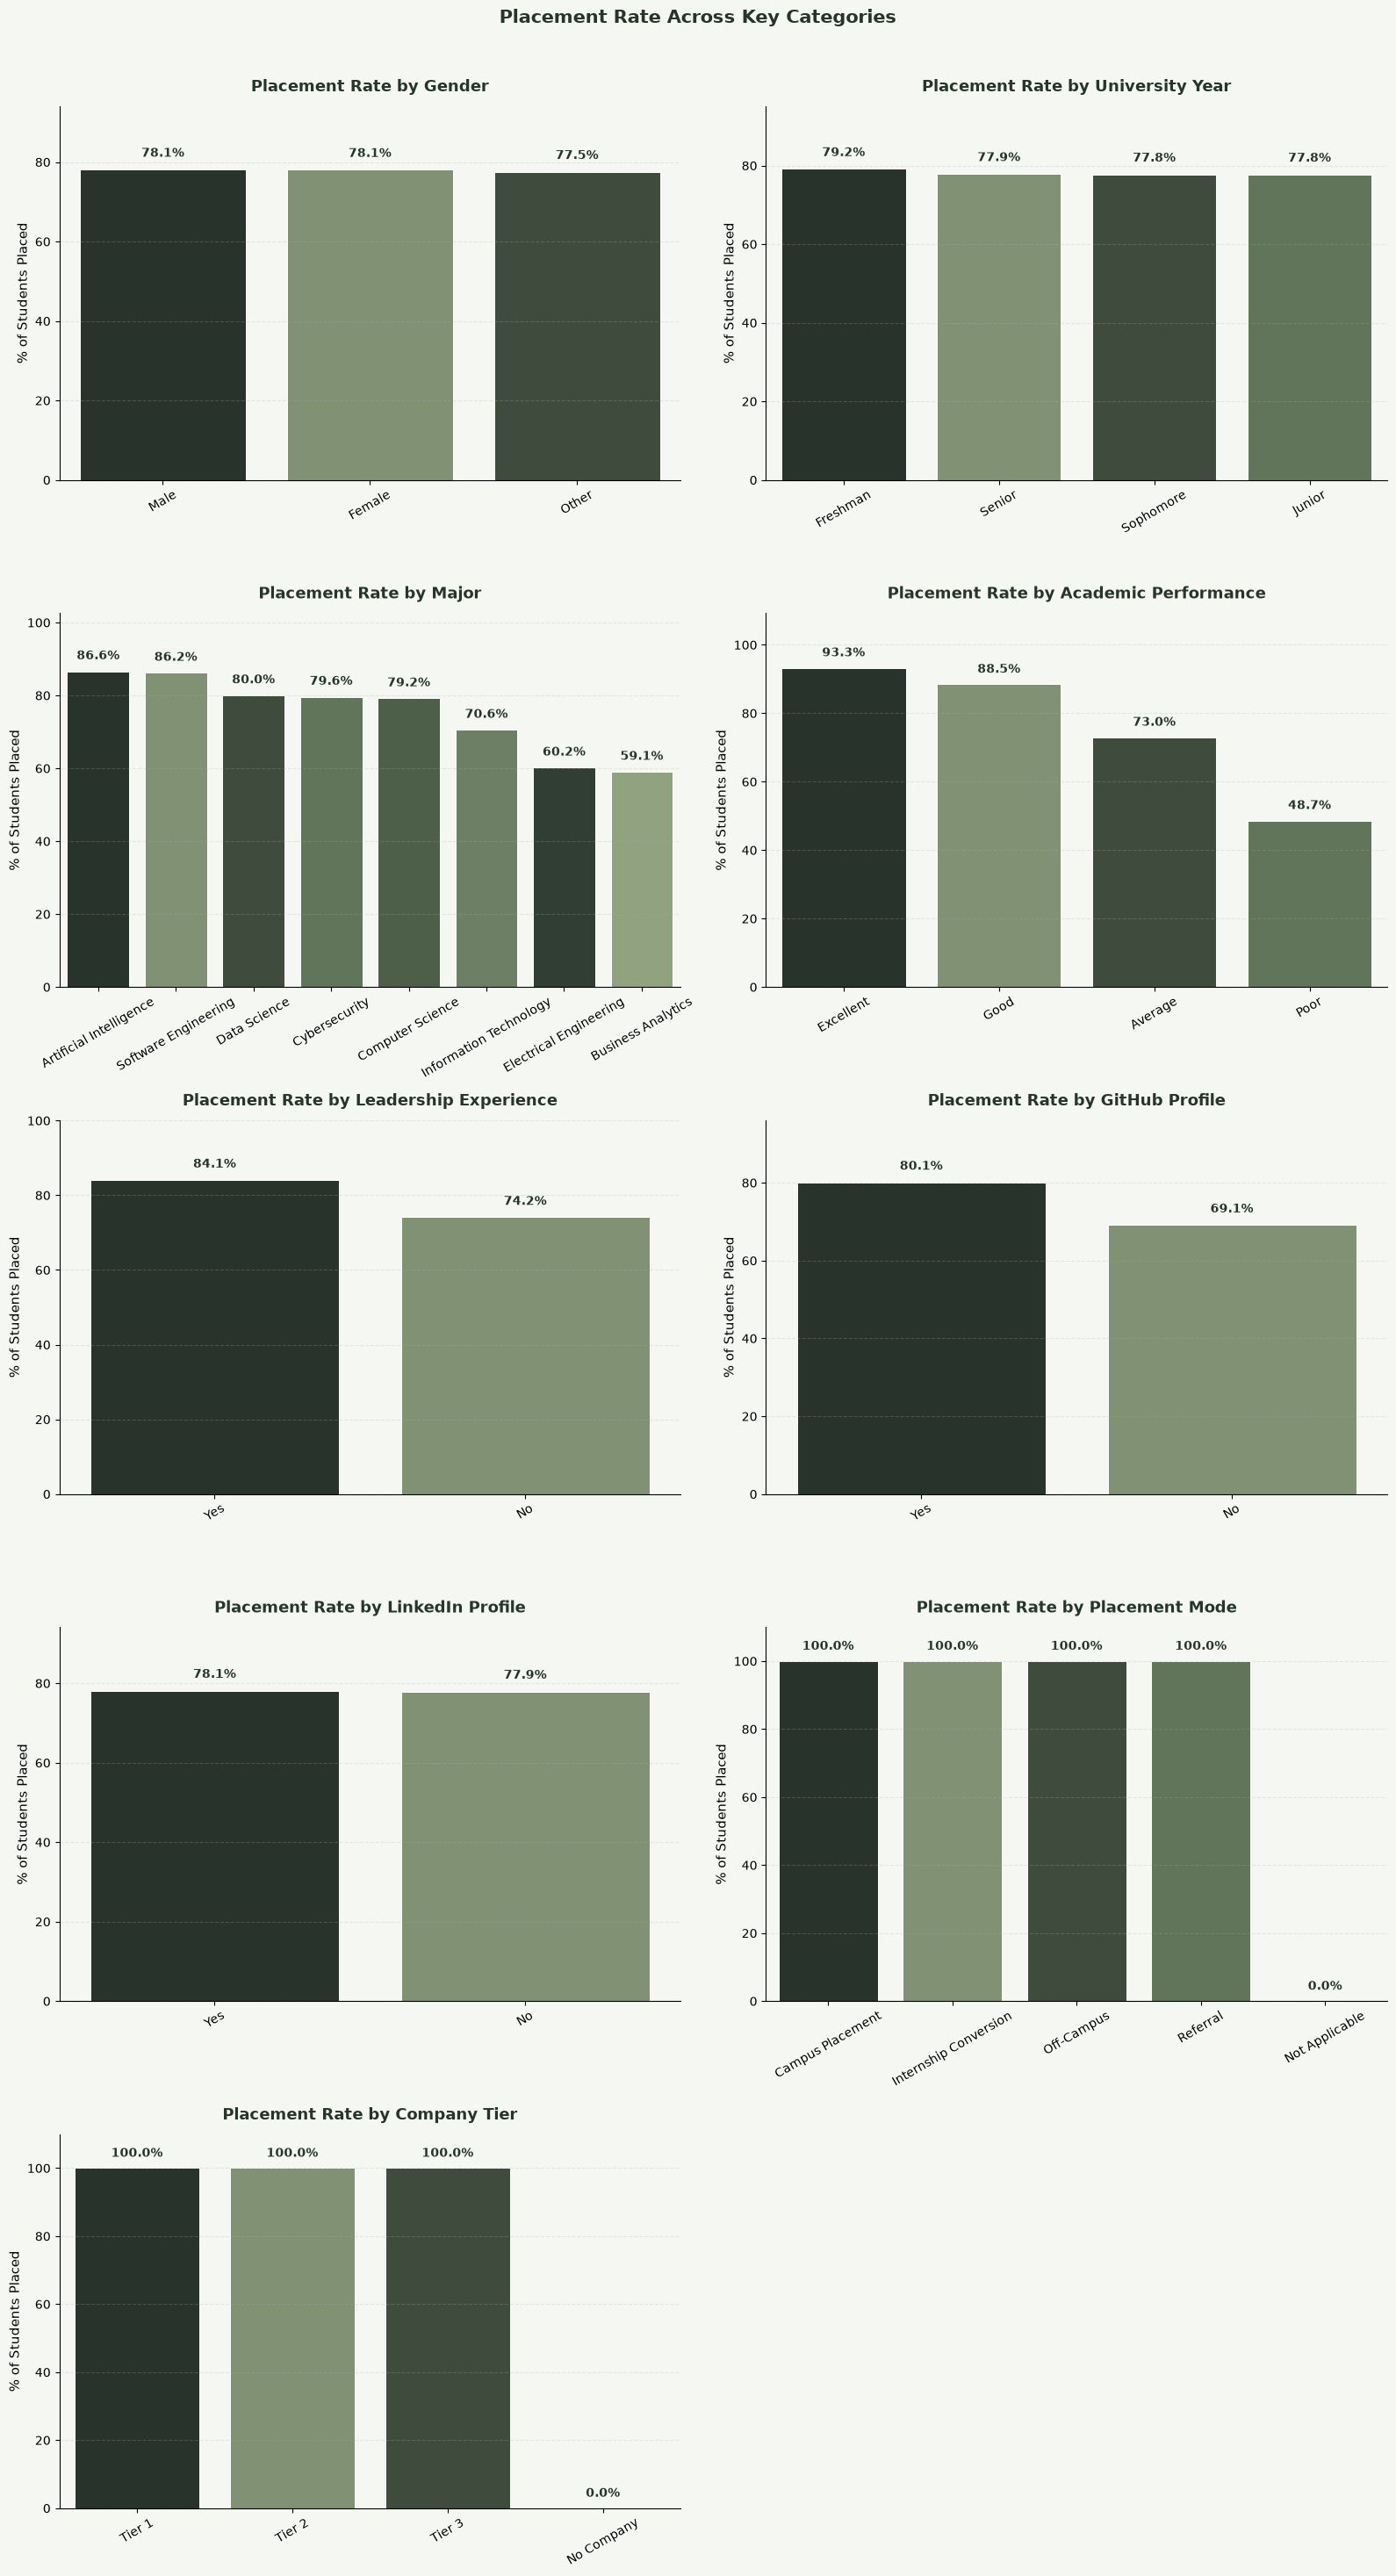

In [35]:
# Placement Rate (%) by Key Categorical Features
key_categorical = [c for c in ["Gender", "University_Year", "Major", "Academic_Performance",
                               "Internship_Experience", "Leadership_Experience",
                               "GitHub_Profile", "LinkedIn_Profile", "Hackathon_Participation",
                               "Placement_Mode", "Company_Tier", "Career_Field"] if c in df.columns][:-1]
n, ncols = len(key_categorical), 2
nrows = int(np.ceil(n / ncols))
tones = ["#26352A", "#7F966F", "#3D4E3A", "#5E7A55", "#4A6345", "#6B8560", "#2F4033", "#8FA87A", "#455B42", "#6F8765"]
bg = "#F4F7F2"
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.8 * nrows), facecolor=bg)
axes = np.array(axes).flatten()

for i, col in enumerate(key_categorical):
    ax = axes[i]
    ax.set_facecolor(bg)
    rate = (df.groupby(col)["Placement_Status"]
              .apply(lambda s: s.astype(str).str.lower().isin(["placed", "yes", "1"]).mean() * 100)
              .sort_values(ascending=False))
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, ax=ax,
                palette=tones[:len(rate)], edgecolor="white", linewidth=0.7, legend=False)
    for j, v in enumerate(rate.values):
        ax.text(j, v + 2.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#26352A")
    ax.set_title(f"Placement Rate by {col.replace('_', ' ')}", fontsize=13, fontweight="bold", color="#26352A", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("% of Students Placed", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("medium")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.set_ylim(0, min(110, rate.max() + 16))

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Placement Rate Across Key Categories",
             fontsize=15, fontweight="bold", color="#26352A", y=1.01)
plt.tight_layout()
plt.show()

### Placement rate by career field

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


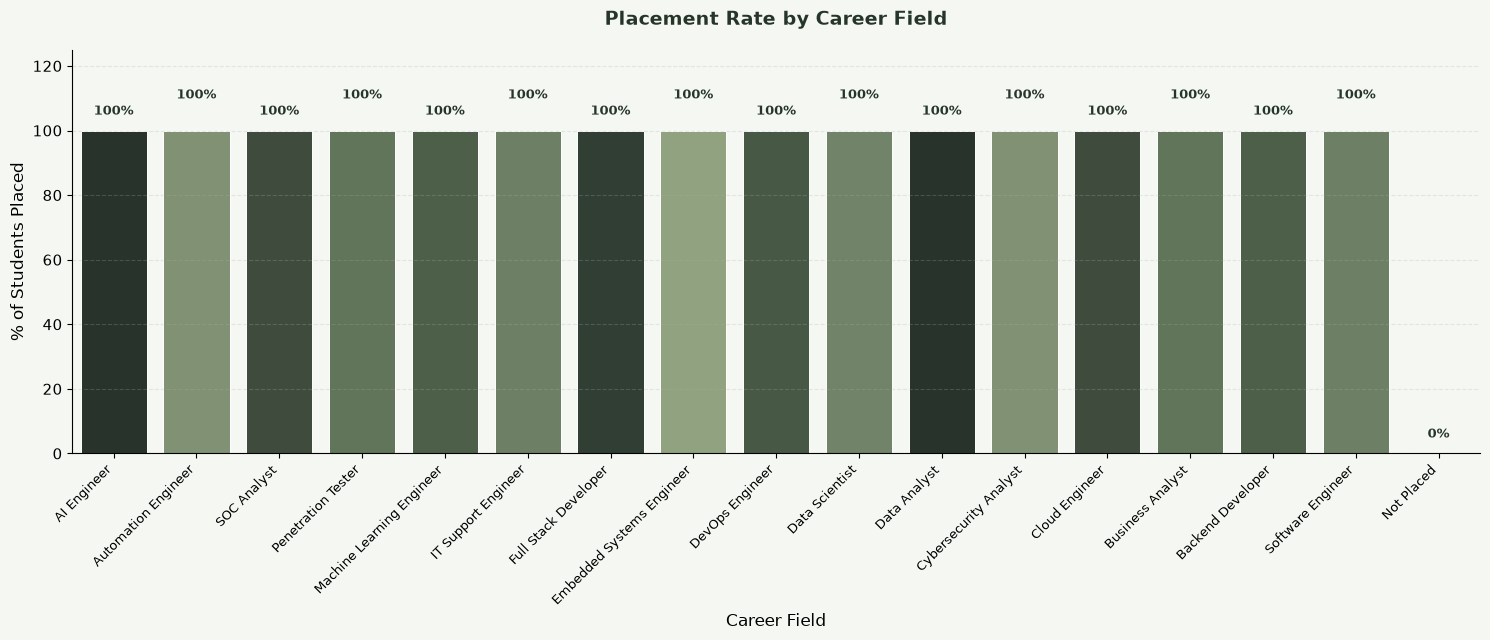

In [36]:
# Placement Rate by Career Field
col = "Career_Field"
tones = ["#26352A", "#7F966F", "#3D4E3A", "#5E7A55", "#4A6345", "#6B8560",
         "#2F4033", "#8FA87A", "#455B42", "#6F8765"]
bg = "#F4F7F2"
rate = (df.groupby(col)["Placement_Status"]
          .apply(lambda s: s.astype(str).str.lower().isin(["placed", "yes", "1"]).mean() * 100)
          .sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(15, 6.5), facecolor=bg)
ax.set_facecolor(bg)
sns.barplot(x=rate.index, y=rate.values, ax=ax,
            palette=tones[:len(rate)], edgecolor="white", linewidth=0.7)
for i, (bar, v) in enumerate(zip(ax.patches, rate.values)):
    offset = 4 if i % 2 == 0 else 9   # alternate heights
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f"{v:.0f}%",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#26352A")
ax.set_title("Placement Rate by Career Field",
             fontsize=14, fontweight="bold", color="#26352A", pad=18)
ax.set_xlabel("Career Field", fontsize=12)
ax.set_ylabel("% of Students Placed", fontsize=12)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=11)
for label in ax.get_xticklabels():
    label.set_ha("right")
    label.set_fontweight("medium")
for label in ax.get_yticklabels():
    label.set_fontweight("medium")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_ylim(0, 125)   
plt.tight_layout()
plt.show()

### Correlation analysis

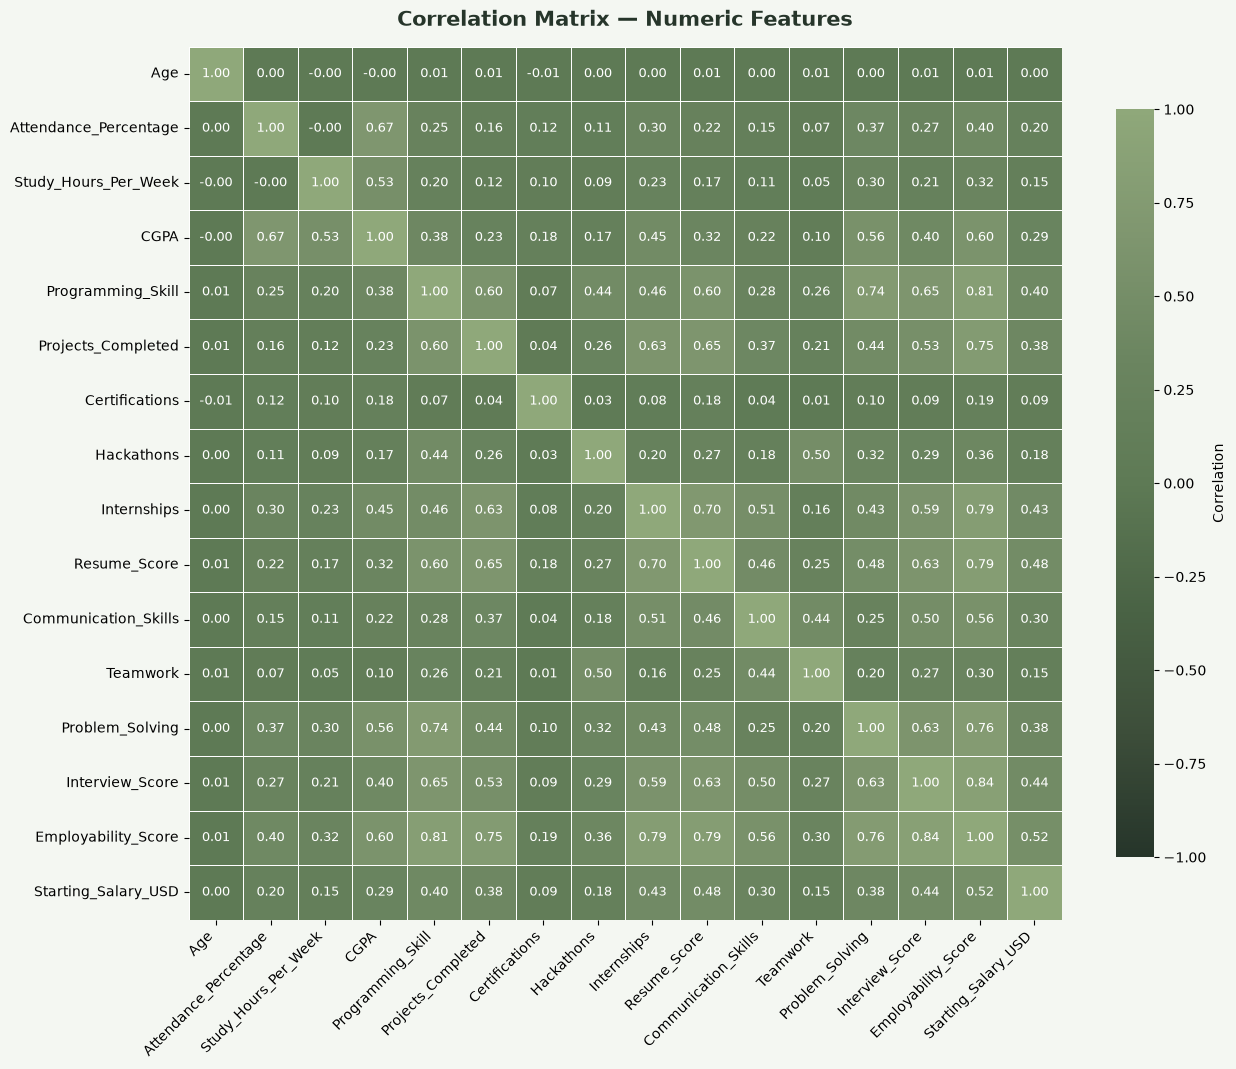

,Feature_1,Feature_2,Correlation
0,Interview_Score,Employability_Score,0.845
1,Programming_Skill,Employability_Score,0.814
2,Resume_Score,Employability_Score,0.791
3,Internships,Employability_Score,0.790
4,Problem_Solving,Employability_Score,0.764
5,Projects_Completed,Employability_Score,0.752
6,Programming_Skill,Problem_Solving,0.737
7,Internships,Resume_Score,0.696
8,Attendance_Percentage,CGPA,0.668
9,Projects_Completed,Resume_Score,0.651


Pairs with |r| >= 0.7: 7; pairs with |r| >= 0.4: 39 of 256


In [37]:
# Numeric columns
numeric_cols_raw = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != "Student_ID"]
corr = df[numeric_cols_raw].corr()

# color palette
tones = ["#26352A", "#3D4E3A", "#4A6345", "#5E7A55", "#6B8560", "#7F966F", "#8FA87A"]
moss_cmap = LinearSegmentedColormap.from_list("moss", tones)
bg = "#F4F7F2"

# Correlation heatmap
fig, ax = plt.subplots(figsize=(13, 11), facecolor=bg)
ax.set_facecolor(bg)
sns.heatmap(corr, annot=True, fmt=".2f", cmap=moss_cmap, center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.6, annot_kws={"size": 9, "weight": "medium"},
            cbar_kws={"shrink": 0.8, "label": "Correlation"}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=15, fontweight="bold", color="#26352A", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Strongest feature pairs
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().reset_index()
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
corr_pairs = corr_pairs.reindex(corr_pairs["Correlation"].abs().sort_values(ascending=False).index)
display(corr_pairs.head(10).round(3).reset_index(drop=True))
print(f"Pairs with |r| >= 0.7: {(corr_pairs['Correlation'].abs() >= 0.7).sum()}; "
      f"pairs with |r| >= 0.4: {(corr_pairs['Correlation'].abs() >= 0.4).sum()} of {len(corr_pairs)}")

## 5. Outlier Detection

We flag values outside 1.5 × IQR. Flagged values are investigated, not automatically removed.

In [38]:
def iqr_outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    return ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).mean() * 100

iqr_report = pd.Series({c: iqr_outlier_pct(df[c]) for c in numeric_cols_raw}).sort_values(ascending=False)

q1, q3 = df[numeric_cols_raw].quantile(0.25), df[numeric_cols_raw].quantile(0.75)
outlier_detail = pd.DataFrame({
    "Outlier Rate (%)": iqr_report,
    "Level": pd.cut(iqr_report, [-np.inf, 5, 10, np.inf], labels=["Low", "Moderate", "High"], right=False),
    "Mean": df[numeric_cols_raw].mean(),
    "Median": df[numeric_cols_raw].median(),
    "Min": df[numeric_cols_raw].min(),
    "Max": df[numeric_cols_raw].max(),
    "Lower Bound": q1 - 1.5 * (q3 - q1),
    "Upper Bound": q3 + 1.5 * (q3 - q1),
}).loc[iqr_report.index]
display(outlier_detail.round(2))

mean_median_gap = ((df[numeric_cols_raw].mean() - df[numeric_cols_raw].median()).abs()
                   / df[numeric_cols_raw].median().abs().replace(0, np.nan) * 100)
print("Largest mean-median gaps (%):")
display(mean_median_gap.sort_values(ascending=False).head(5).round(2).to_frame("Mean-Median Gap (%)"))

,Outlier Rate (%),Level,Mean,Median,Min,Max,Lower Bound,Upper Bound
Starting_Salary_USD,21.92,High,68988.17,83044.50,0.0,110000.00,18343.75,143371.75
Resume_Score,12.71,High,96.05,100.00,44.0,100.00,87.50,107.50
Age,4.07,Low,21.26,21.00,18.0,30.00,17.00,25.00
Projects_Completed,1.61,Low,8.62,9.00,0.0,15.00,2.50,14.50
Employability_Score,1.09,Low,213.99,217.25,82.3,279.05,142.98,287.98
Interview_Score,0.98,Low,77.52,78.00,17.0,100.00,44.50,112.50
CGPA,0.53,Low,3.11,3.11,2.0,4.00,2.31,3.91
Attendance_Percentage,0.50,Low,81.41,82.00,50.0,100.00,55.50,107.50
Study_Hours_Per_Week,0.49,Low,21.53,21.00,5.0,45.00,3.50,39.50
Problem_Solving,0.38,Low,7.18,7.00,1.0,10.00,3.00,11.00


Largest mean-median gaps (%):


,Mean-Median Gap (%)
Starting_Salary_USD,16.93
Certifications,14.22
Communication_Skills,6.27
Projects_Completed,4.22
Resume_Score,3.95


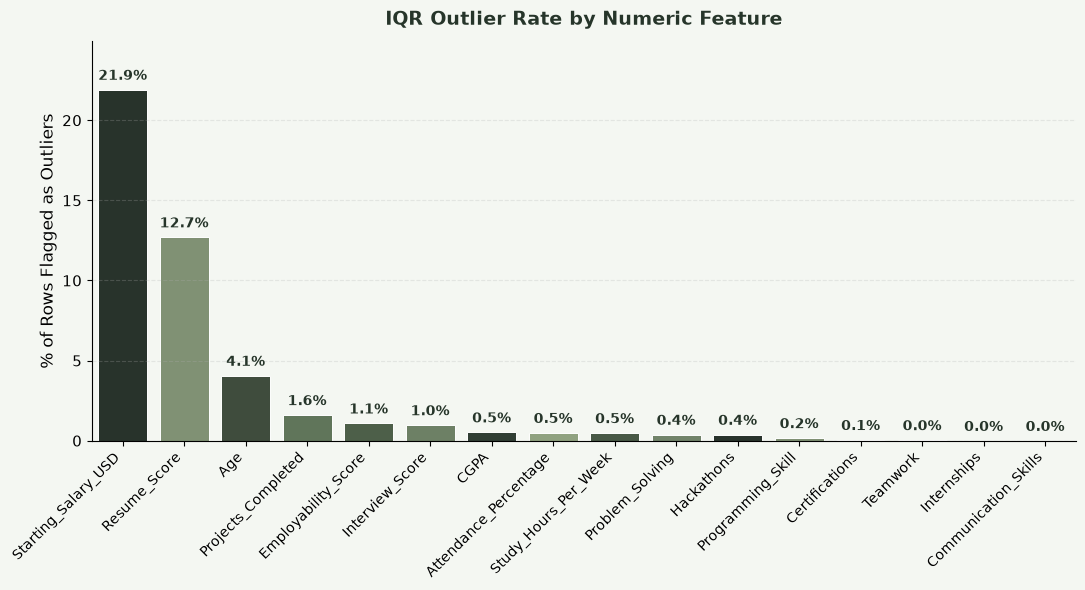

In [39]:
# IQR outlier rate by numeric feature (iqr_report computed above)
# Color palette
base_tones = ["#26352A", "#7F966F", "#3D4E3A", "#5E7A55", "#4A6345", "#6B8560", "#2F4033", "#8FA87A", "#455B42", "#6F8765"]
tones = (base_tones * ((len(iqr_report) // len(base_tones)) + 1))[:len(iqr_report)]
bg = "#F4F7F2"

# IQR Outlier Rate Bar Chart
fig, ax = plt.subplots(figsize=(11, 6), facecolor=bg)
ax.set_facecolor(bg)
sns.barplot(x=iqr_report.index, y=iqr_report.values, hue=iqr_report.index, ax=ax,
            palette=tones, edgecolor="white", linewidth=0.7, legend=False)
for i, v in enumerate(iqr_report.values):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#26352A")
ax.set_title("IQR Outlier Rate by Numeric Feature", fontsize=14, fontweight="bold", color="#26352A", pad=12)
ax.set_xlabel("")
ax.set_ylabel("% of Rows Flagged as Outliers", fontsize=12)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", labelsize=11)
for label in ax.get_xticklabels():
    label.set_ha("right")
    label.set_fontweight("medium")
for label in ax.get_yticklabels():
    label.set_fontweight("medium")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_ylim(0, iqr_report.max() + 3)
plt.tight_layout()
plt.show()

### Feature ranges (boxplots)

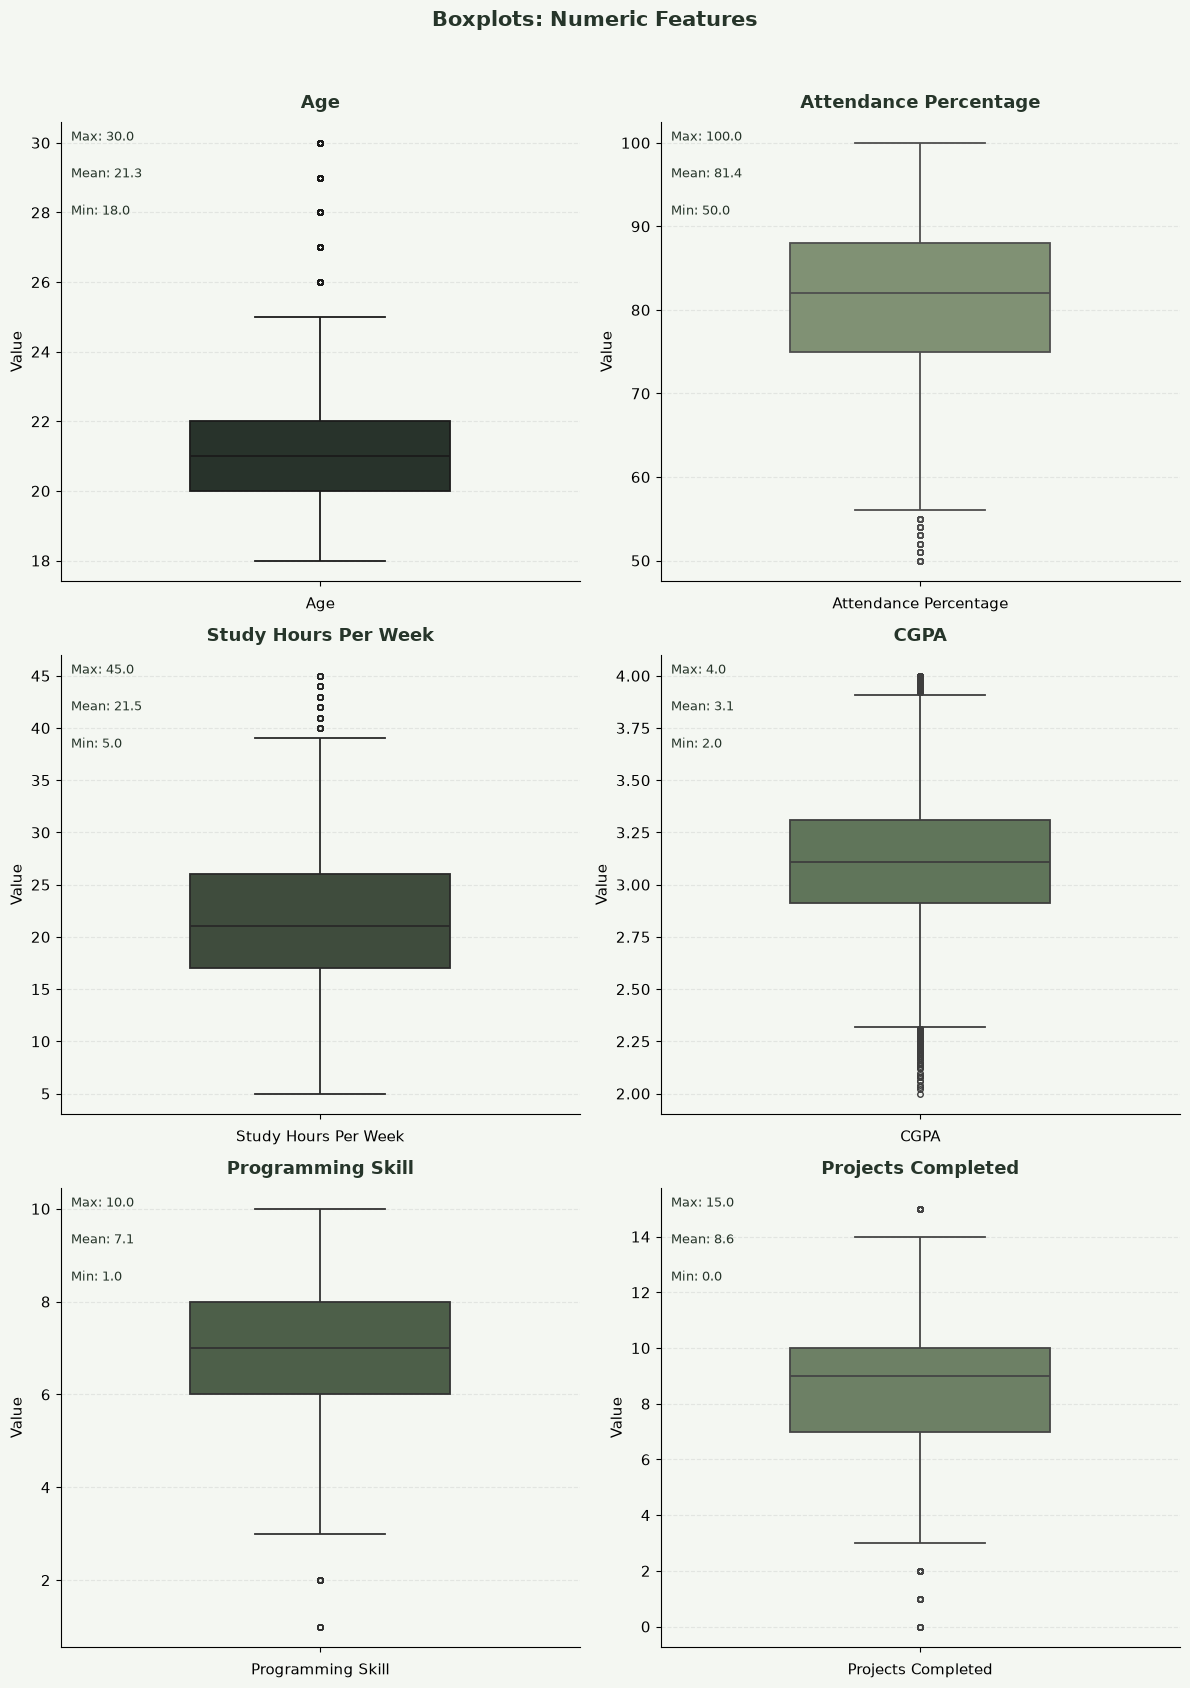

In [40]:
# Boxplots of Numeric Features
cols = numeric_cols_raw[:6]
n = len(cols)
ncols = 2
nrows = int(np.ceil(n / ncols))

tones = ["#26352A", "#7F966F", "#3D4E3A", "#5E7A55", "#4A6345", "#6B8560"]
bg = "#F4F7F2"

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5.5 * nrows), facecolor=bg)
axes = np.array(axes).flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.set_facecolor(bg)
    
    data = df[col].dropna()
    sns.boxplot(y=data, ax=ax, color=tones[i % len(tones)],
                width=0.5, linewidth=1.3, fliersize=4)
    mean_val = data.mean()
    min_val = data.min()
    max_val = data.max()
    
    ax.text(0.02, 0.98, f"Max: {max_val:.1f}", transform=ax.transAxes,
            fontsize=9, color="#26352A", va="top")
    ax.text(0.02, 0.90, f"Mean: {mean_val:.1f}", transform=ax.transAxes,
            fontsize=9, color="#26352A", va="top")
    ax.text(0.02, 0.82, f"Min: {min_val:.1f}", transform=ax.transAxes,
            fontsize=9, color="#26352A", va="top")
    
    ax.set_title(col.replace('_', ' '), fontsize=13, fontweight="bold",
                 color="#26352A", pad=10)
    ax.set_xlabel(col.replace('_', ' '), fontsize=11)
    ax.set_ylabel("Value", fontsize=11)
    
    ax.tick_params(labelsize=11)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("medium")
    
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots: Numeric Features",
             fontsize=15, fontweight="bold", color="#26352A", y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

We create row-wise features only, so no information is shared between rows.

In [41]:
feature_notes = []

# Study Efficiency
if {"CGPA", "Study_Hours_Per_Week"}.issubset(df.columns):
    df["Study_Efficiency"] = df["CGPA"] / (df["Study_Hours_Per_Week"] + 1)
    feature_notes.append({"Feature": "Study_Efficiency", "Description": "CGPA relative to weekly study hours.", "Formula": "CGPA / (Study Hours + 1)", "Leakage": "Safe — row-wise"})

# Experience Count
experience_flags = []
experience_columns = {"Internship_Experience": "Has_Internship", "Leadership_Experience": "Has_Leadership",
                      "Hackathon_Participation": "Has_Hackathon", "GitHub_Profile": "Has_GitHub", "LinkedIn_Profile": "Has_LinkedIn"}
for source_col, new_col in experience_columns.items():
    if source_col in df.columns:
        df[new_col] = df[source_col].astype(str).str.strip().str.lower().isin(["yes", "1", "true", "present"]).astype(int)
        experience_flags.append(new_col)

if "Certifications" in df.columns:
    df["Has_Certifications"] = pd.to_numeric(df["Certifications"], errors="coerce").fillna(0).gt(0).astype(int)
    experience_flags.append("Has_Certifications")

if experience_flags:
    df["Experience_Count"] = df[experience_flags].sum(axis=1)
    feature_notes.append({"Feature": "Experience_Count", "Description": "Number of resume-building activities.",
                          "Formula": "Sum of internship, leadership, hackathon, GitHub, LinkedIn and certification flags", "Leakage": "Safe — row-wise"})

# University Year
if "University_Year" in df.columns:
    university_year_map = {"freshman": 1, "sophomore": 2, "junior": 3, "senior": 4}
    df["University_Year_Ordinal"] = df["University_Year"].astype(str).str.strip().str.lower().map(university_year_map)
    feature_notes.append({"Feature": "University_Year_Ordinal", "Description": "Academic year represented as an ordered numerical value.",
                          "Formula": "Freshman=1, Sophomore=2, Junior=3, Senior=4", "Leakage": "Safe — fixed mapping"})

# 4. Projects per Year
if {"Projects_Completed", "University_Year_Ordinal"}.issubset(df.columns):
    df["Projects_per_Year"] = pd.to_numeric(df["Projects_Completed"], errors="coerce") / df["University_Year_Ordinal"].replace(0, np.nan)
    feature_notes.append({"Feature": "Projects_per_Year", "Description": "Projects completed relative to academic years.",
                          "Formula": "Projects Completed / University Year Ordinal", "Leakage": "Safe — row-wise"})

feature_report = pd.DataFrame(feature_notes)

display(feature_report)

created_features = [c for c in ["Study_Efficiency", "Experience_Count", "Has_Internship", "Has_Leadership", "Has_Hackathon",
                                "Has_GitHub", "Has_LinkedIn", "Has_Certifications", "University_Year_Ordinal", "Projects_per_Year"] if c in df.columns]
print("Engineered features:", created_features)
print("Dataset shape:", df.shape)

,Feature,Description,Formula,Leakage
0,Study_Efficiency,CGPA relative to weekly study hours.,CGPA / (Study Hours + 1),Safe — row-wise
1,Experience_Count,Number of resume-building activities.,"Sum of internship, leadership, hackathon, GitH...",Safe — row-wise
2,University_Year_Ordinal,Academic year represented as an ordered numeri...,"Freshman=1, Sophomore=2, Junior=3, Senior=4",Safe — fixed mapping
3,Projects_per_Year,Projects completed relative to academic years.,Projects Completed / University Year Ordinal,Safe — row-wise


Engineered features: ['Study_Efficiency', 'Experience_Count', 'Has_Leadership', 'Has_GitHub', 'Has_LinkedIn', 'Has_Certifications', 'University_Year_Ordinal', 'Projects_per_Year']
Dataset shape: (50000, 37)


### Modelling dataset preview

In [42]:
display(df.head(10).round(3))
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,Projects_Completed,Certifications,Hackathons,GitHub_Profile,Internships,Leadership_Experience,LinkedIn_Profile,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD,Study_Efficiency,Has_Leadership,Has_GitHub,Has_LinkedIn,Has_Certifications,Experience_Count,University_Year_Ordinal,Projects_per_Year
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,10,1,6,Yes,5,No,No,100,9,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082,0.149,0,1,0,1,2,2,5.000
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,6,0,5,Yes,2,No,Yes,80,5,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0,0.133,0,1,1,0,2,1,6.000
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,9,0,5,Yes,3,Yes,No,100,7,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898,0.142,1,1,0,0,2,4,2.250
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,6,3,3,No,2,No,Yes,85,6,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0,0.140,0,0,1,1,2,4,1.500
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,10,1,2,Yes,3,Yes,Yes,100,10,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256,0.147,1,1,1,1,4,4,2.500
5,ST000006,21,Male,Senior,Computer Science,85,32,3.41,Good,9,5,3,4,Yes,3,No,Yes,98,5,6,9,Intermediate,72,210.05,Placed,Tier 1,Software Engineer,Off-Campus,109920,0.103,0,1,1,1,3,4,1.250
6,ST000007,21,Male,Junior,Artificial Intelligence,73,18,3.00,Average,8,8,2,4,Yes,5,No,Yes,100,8,6,6,Advanced,81,219.50,Placed,Tier 1,AI Engineer,Internship Conversion,85010,0.158,0,1,1,1,3,3,2.667
7,ST000008,23,Male,Freshman,Business Analytics,82,20,2.87,Average,4,5,0,1,No,3,No,Yes,86,7,6,4,Intermediate,57,160.35,Not Placed,No Company,Not Placed,Not Applicable,0,0.137,0,0,1,0,1,1,5.000
8,ST000009,23,Female,Freshman,Computer Science,82,39,3.48,Good,8,9,0,5,Yes,5,Yes,No,100,10,10,7,Advanced,100,241.20,Placed,Tier 1,Full Stack Developer,Campus Placement,96175,0.087,1,1,0,0,2,1,9.000
9,ST000010,30,Male,Junior,Information Technology,72,18,2.85,Average,5,3,1,0,No,3,Yes,Yes,78,10,6,5,Advanced,56,166.65,Not Placed,No Company,Not Placed,Not Applicable,0,0.150,1,0,1,1,3,3,1.000


Dataset shape: 50,000 rows x 37 columns


## 7. Target Leakage

`Career_Field`, `Placement_Mode`, `Company_Tier` and `Starting_Salary_USD` are only known after the placement outcome (e.g. salary is 0 and company tier is "No Company" for students who were not placed). We drop them so the model learns from pre-placement information only.

In [43]:
target_col = "Placement_Status"
leakage_reasons = {
    "career_field": 'Can contain "Not Placed", directly revealing the outcome.',
    "placement_mode": '"Not Applicable" when a student is not placed.',
    "company_tier": '"No Company" for students who were not placed.',
    "salary": "0 for students who were not placed, so it is a proxy for the target.",
}
available_leakage_cols = [c for c in df.columns if c != target_col and
                          (c.lower() in leakage_reasons or "salary" in c.lower())]
leakage_table = pd.DataFrame({
    "Column": available_leakage_cols,
    "Reason": [leakage_reasons["salary" if "salary" in c.lower() else c.lower()] for c in available_leakage_cols],
})
display(leakage_table)

,Column,Reason
0,Company_Tier,"""No Company"" for students who were not placed."
1,Career_Field,"Can contain ""Not Placed"", directly revealing t..."
2,Placement_Mode,"""Not Applicable"" when a student is not placed."
3,Starting_Salary_USD,"0 for students who were not placed, so it is a..."


### Features and target

In [44]:
target = "Placement_Status"
y = df[target].astype(str).str.strip().str.lower().isin(["placed", "yes", "1"]).astype(int)
explicit_leakage = ["Career_Field", "Placement_Mode", "Company_Tier", "Starting_Salary", "Starting_Salary_USD"]
salary_cols = [c for c in df.columns if "salary" in c.lower()]
leakage_columns = list(dict.fromkeys([target] + [c for c in explicit_leakage if c in df.columns] + salary_cols))

drop_from_X = leakage_columns.copy()
id_like_cols = [c for c in df.columns if "id" in c.lower() and c not in drop_from_X]
drop_from_X += id_like_cols

if "University_Year_Ordinal" in df.columns and "University_Year" in df.columns:
    drop_from_X.append("University_Year")

for col in ["Internship_Experience", "Leadership_Experience", "GitHub_Profile", "LinkedIn_Profile", "Hackathon_Participation"]:
    if col in df.columns and f"Has_{col.split('_')[0]}" in df.columns:
        drop_from_X.append(col)

X = df.drop(columns=drop_from_X, errors="ignore")
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# Target distribution & percentages
target_df = (
    y.value_counts()
    .rename("Count")
    .to_frame()
    .assign(Percentage=lambda d: (d["Count"] / d["Count"].sum() * 100).round(2))
)
print("Target distribution & percentages:")
display(target_df)

# Leakage columns
leakage_df = pd.DataFrame({"Removed due to leakage": leakage_columns})
print("\nColumns removed because of target leakage:")
display(leakage_df)

# Numeric features
num_df = pd.DataFrame({"Numeric Features": numeric_features})
print(f"\n{len(numeric_features)} numeric features:")
display(num_df)

# Categorical features
cat_df = pd.DataFrame({"Categorical Features": categorical_features})
print(f"\n{len(categorical_features)} categorical features:")
display(cat_df)

Target distribution & percentages:


,Count,Percentage
Placement_Status,,
1,39040,78.08
0,10960,21.92



Columns removed because of target leakage:


,Removed due to leakage
0,Placement_Status
1,Career_Field
2,Placement_Mode
3,Company_Tier
4,Starting_Salary_USD



23 numeric features:


,Numeric Features
0,Age
1,Attendance_Percentage
2,Study_Hours_Per_Week
3,CGPA
4,Programming_Skill
5,Projects_Completed
6,Certifications
7,Hackathons
8,Internships
9,Resume_Score



4 categorical features:


,Categorical Features
0,Gender
1,Major
2,Academic_Performance
3,English_Proficiency


## 8. Train / Validation / Test Split

A stratified 60 / 20 / 20 split. The test set stays untouched until the final evaluation.

In [45]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print("Training:", X_train_raw.shape)
print("Validation:", X_val_raw.shape)
print("Test:", X_test_raw.shape)

print("\nTarget rate train: {:.2f}%  val: {:.2f}%  test: {:.2f}%".format(
    y_train.mean()*100, y_val.mean()*100, y_test.mean()*100))

Training: (30000, 27)
Validation: (10000, 27)
Test: (10000, 27)

Target rate train: 78.08%  val: 78.08%  test: 78.08%


### Scaling and encoding

The preprocessor is fitted on the training split only, then applied to the validation and test splits.

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features),
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)   
X_val   = preprocessor.transform(X_val_raw)         
X_test  = preprocessor.transform(X_test_raw)       

feature_names = preprocessor.get_feature_names_out()

print("Train shape:", X_train.shape)
print("Val shape :", X_val.shape)
print("Test shape :", X_test.shape)

Train shape: (30000, 41)
Val shape : (10000, 41)
Test shape : (10000, 41)


## 9. Model Benchmark

### Evaluation helpers

`evaluate_model` fits a model on the training split and records validation metrics. `show_model_report` prints the metrics, the validation classification report and the confusion matrix.

In [47]:
results = []
fitted_models = {}
roc_curves = {}

def evaluate_model(name, model, X_tr=X_train, y_tr=y_train, X_va=X_val, y_va=y_val, plot_cm=False):
    # Training
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    # Predictions
    train_pred = model.predict(X_tr)
    val_pred = model.predict(X_va)

    # Prediction scores & probabilities
    if hasattr(model, "predict_proba"):
        train_proba = model.predict_proba(X_tr)[:, 1]
        val_proba = model.predict_proba(X_va)[:, 1]
    elif hasattr(model, "decision_function"):
        train_proba = model.decision_function(X_tr)
        val_proba = model.decision_function(X_va)
    else:
        train_proba = train_pred
        val_proba = val_pred

    # Evaluation metrics
    train_f1 = f1_score(y_tr, train_pred, zero_division=0)
    val_acc = accuracy_score(y_va, val_pred)
    val_prec = precision_score(y_va, val_pred, zero_division=0)
    val_rec = recall_score(y_va, val_pred, zero_division=0)
    val_f1 = f1_score(y_va, val_pred, zero_division=0)
    f1_gap = train_f1 - val_f1

    # ROC-AUC and ROC curve
    try:
        val_auc = roc_auc_score(y_va, val_proba)
        fpr, tpr, _ = roc_curve(y_va, val_proba)
        roc_curves[name] = (fpr, tpr, val_auc)
    except Exception:
        val_auc = np.nan

    # Store results and fitted model
    results.append({
        "Model": name, "Train_F1": train_f1, "Val_Accuracy": val_acc,
        "Val_Precision": val_prec, "Val_Recall": val_rec, "Val_F1": val_f1,
        "F1_Gap": f1_gap, "Val_ROC_AUC": val_auc, "Train_Time_s": train_time
    })
    fitted_models[name] = model

    # confusion matrix
    if plot_cm:
        cm = confusion_matrix(y_va, val_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d",
                    cmap=LinearSegmentedColormap.from_list("moss", ["#26352A", "#7F966F"]),
                    linewidths=1, linecolor="white", square=True,
                    xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"],
                    annot_kws={"size": 13, "weight": "bold"}, ax=ax)
        ax.set_title(f"{name} — Confusion Matrix", fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("Actual", fontsize=11)
        plt.tight_layout()
        plt.show()

    return model

LABELS = ["Not Placed", "Placed"]
MOSS_CMAP = LinearSegmentedColormap.from_list("moss", ["#26352A", "#7F966F"])

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap=MOSS_CMAP, linewidths=1, linecolor="white", square=True, cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, annot_kws={"size": 13, "weight": "bold"}, ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

def show_model_report(name):
    res = next(r for r in reversed(results) if r["Model"] == name)
    display(pd.Series(res).drop("Model").astype(float).round(4).to_frame(name))
    val_pred = fitted_models[name].predict(X_val)
    report = pd.DataFrame(classification_report(y_val, val_pred, target_names=LABELS, output_dict=True)).T
    display(report.round(2))
    plot_confusion(y_val, val_pred, f"{name}: Validation Confusion Matrix")

### Benchmarked models

We benchmark **23 classifiers** using the same preprocessing and validation split.

| Family | Models |
|:---|:---|
| Linear & margin-based | Logistic Regression, Ridge, SGD, Perceptron, Linear SVM |
| Probabilistic | Gaussian NB, Bernoulli NB, LDA, QDA |
| Distance-based | K-Nearest Neighbors |
| Trees & bagging | Decision Tree, Random Forest, Extra Trees, Bagging |
| Boosting | Gradient Boosting, AdaBoost, HistGradientBoosting, XGBoost, LightGBM, CatBoost |
| Neural network | MLP |
| Meta-ensembles | Soft Voting, Stacking |

Metrics: validation accuracy, precision, recall, F1, ROC-AUC, the train–validation F1 gap, and training time.

### Logistic Regression

,Logistic Regression
Train_F1,0.8234
Val_Accuracy,0.7439
Val_Precision,0.9054
Val_Recall,0.7504
Val_F1,0.8206
F1_Gap,0.0028
Val_ROC_AUC,0.8047
Train_Time_s,0.0353


,precision,recall,f1-score,support
Not Placed,0.45,0.72,0.55,2192.00
Placed,0.91,0.75,0.82,7808.00
accuracy,0.74,0.74,0.74,0.74
macro avg,0.68,0.74,0.69,10000.00
weighted avg,0.81,0.74,0.76,10000.00


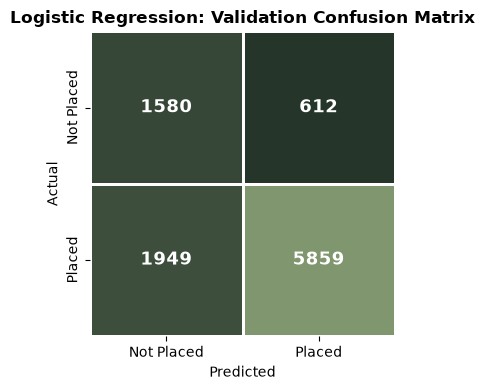

In [48]:
# Train model
model_lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
evaluate_model("Logistic Regression", model_lr)
show_model_report("Logistic Regression")

### Ridge Classifier

,Ridge Classifier
Train_F1,0.8232
Val_Accuracy,0.7427
Val_Precision,0.9060
Val_Recall,0.7481
Val_F1,0.8195
F1_Gap,0.0037
Val_ROC_AUC,0.8040
Train_Time_s,0.0131


,precision,recall,f1-score,support
Not Placed,0.45,0.72,0.55,2192.00
Placed,0.91,0.75,0.82,7808.00
accuracy,0.74,0.74,0.74,0.74
macro avg,0.68,0.74,0.69,10000.00
weighted avg,0.81,0.74,0.76,10000.00


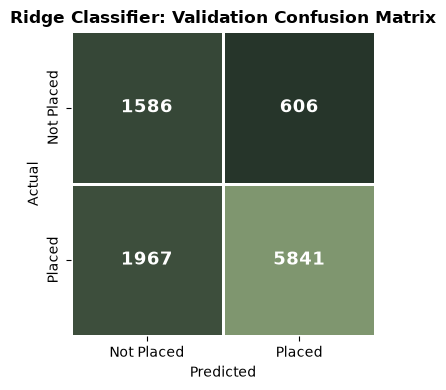

In [49]:
# Train model
model_ridge = RidgeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
evaluate_model("Ridge Classifier", model_ridge)
show_model_report("Ridge Classifier")

### SGD Classifier

,SGD Classifier
Train_F1,0.8085
Val_Accuracy,0.7250
Val_Precision,0.9071
Val_Recall,0.7217
Val_F1,0.8039
F1_Gap,0.0047
Val_ROC_AUC,0.7951
Train_Time_s,0.1097


,precision,recall,f1-score,support
Not Placed,0.43,0.74,0.54,2192.00
Placed,0.91,0.72,0.80,7808.00
accuracy,0.72,0.72,0.72,0.72
macro avg,0.67,0.73,0.67,10000.00
weighted avg,0.80,0.72,0.75,10000.00


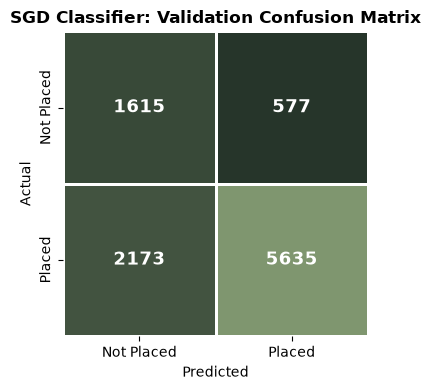

In [50]:
# Train model
model_sgd = SGDClassifier(loss="log_loss", class_weight="balanced", max_iter=1500, random_state=RANDOM_STATE)
evaluate_model("SGD Classifier", model_sgd)
show_model_report("SGD Classifier")

### Linear SVM

,Linear SVM
Train_F1,0.8925
Val_Accuracy,0.8165
Val_Precision,0.8398
Val_Recall,0.9453
Val_F1,0.8894
F1_Gap,0.0031
Val_ROC_AUC,0.8046
Train_Time_s,0.1352


,precision,recall,f1-score,support
Not Placed,0.65,0.36,0.46,2192.00
Placed,0.84,0.95,0.89,7808.00
accuracy,0.82,0.82,0.82,0.82
macro avg,0.74,0.65,0.68,10000.00
weighted avg,0.80,0.82,0.80,10000.00


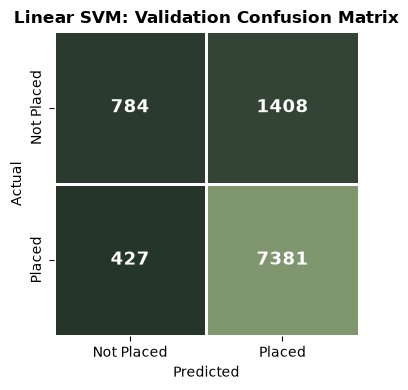

In [51]:
# Train model
base_svm = LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)
model_svm = CalibratedClassifierCV(base_svm, cv=3)
evaluate_model("Linear SVM", model_svm)
show_model_report("Linear SVM")

### Gaussian Naive Bayes

,Gaussian Naive Bayes
Train_F1,0.8505
Val_Accuracy,0.7703
Val_Precision,0.8799
Val_Recall,0.8174
Val_F1,0.8475
F1_Gap,0.0031
Val_ROC_AUC,0.7896
Train_Time_s,0.0056


,precision,recall,f1-score,support
Not Placed,0.48,0.60,0.53,2192.00
Placed,0.88,0.82,0.85,7808.00
accuracy,0.77,0.77,0.77,0.77
macro avg,0.68,0.71,0.69,10000.00
weighted avg,0.79,0.77,0.78,10000.00


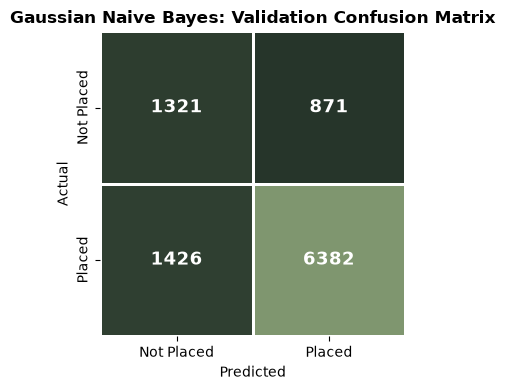

In [52]:
# Train model
model_gnb = GaussianNB()
evaluate_model("Gaussian Naive Bayes", model_gnb)
show_model_report("Gaussian Naive Bayes")

### Bernoulli Naive Bayes

,Bernoulli Naive Bayes
Train_F1,0.8205
Val_Accuracy,0.7386
Val_Precision,0.9000
Val_Recall,0.7483
Val_F1,0.8172
F1_Gap,0.0033
Val_ROC_AUC,0.7905
Train_Time_s,0.0087


,precision,recall,f1-score,support
Not Placed,0.44,0.70,0.54,2192.00
Placed,0.90,0.75,0.82,7808.00
accuracy,0.74,0.74,0.74,0.74
macro avg,0.67,0.73,0.68,10000.00
weighted avg,0.80,0.74,0.76,10000.00


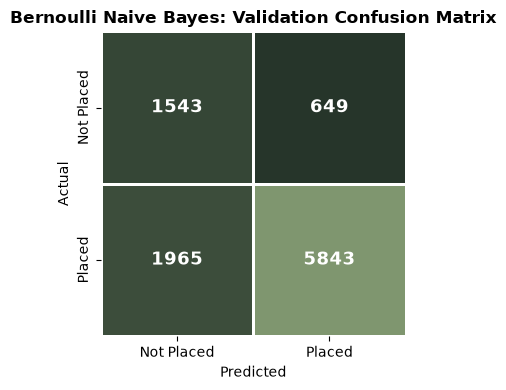

In [53]:
# Train model
model_bnb = BernoulliNB()
evaluate_model("Bernoulli Naive Bayes", model_bnb)
show_model_report("Bernoulli Naive Bayes")

### Linear Discriminant Analysis

,LDA
Train_F1,0.8891
Val_Accuracy,0.8137
Val_Precision,0.8448
Val_Recall,0.9328
Val_F1,0.8866
F1_Gap,0.0024
Val_ROC_AUC,0.8040
Train_Time_s,0.0359


,precision,recall,f1-score,support
Not Placed,0.62,0.39,0.48,2192.00
Placed,0.84,0.93,0.89,7808.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.73,0.66,0.68,10000.00
weighted avg,0.80,0.81,0.80,10000.00


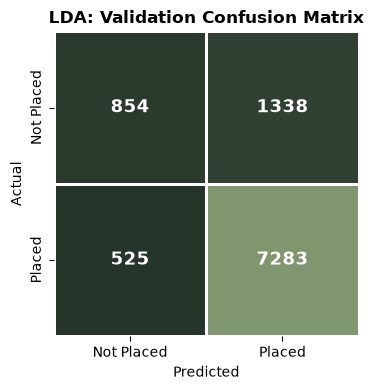

In [54]:
# Train model
model_lda = LinearDiscriminantAnalysis()
evaluate_model("LDA", model_lda)
show_model_report("LDA")

### Quadratic Discriminant Analysis

,QDA
Train_F1,0.8741
Val_Accuracy,0.7967
Val_Precision,0.8552
Val_Recall,0.8904
Val_F1,0.8724
F1_Gap,0.0017
Val_ROC_AUC,0.7854
Train_Time_s,0.0213


,precision,recall,f1-score,support
Not Placed,0.54,0.46,0.50,2192.0
Placed,0.86,0.89,0.87,7808.0
accuracy,0.80,0.80,0.80,0.8
macro avg,0.70,0.68,0.69,10000.0
weighted avg,0.79,0.80,0.79,10000.0


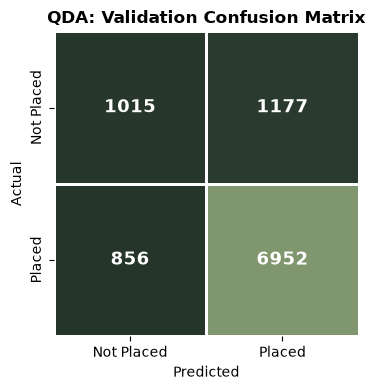

In [55]:
# Train model
model_qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
evaluate_model("QDA", model_qda)
show_model_report("QDA")

### K-Nearest Neighbors

,K-Nearest Neighbors
Train_F1,0.8931
Val_Accuracy,0.8072
Val_Precision,0.8318
Val_Recall,0.9440
Val_F1,0.8843
F1_Gap,0.0087
Val_ROC_AUC,0.7847
Train_Time_s,0.0010


,precision,recall,f1-score,support
Not Placed,0.62,0.32,0.42,2192.00
Placed,0.83,0.94,0.88,7808.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.72,0.63,0.65,10000.00
weighted avg,0.78,0.81,0.78,10000.00


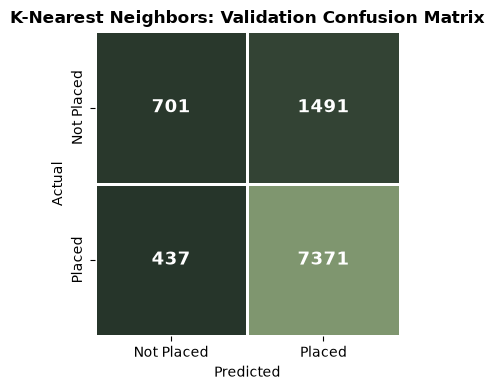

In [56]:
# Train model
model_knn = KNeighborsClassifier(n_neighbors=25, n_jobs=1)
evaluate_model("K-Nearest Neighbors", model_knn)
show_model_report("K-Nearest Neighbors")

### Decision Tree

,Decision Tree
Train_F1,0.8163
Val_Accuracy,0.7171
Val_Precision,0.9084
Val_Recall,0.7091
Val_F1,0.7965
F1_Gap,0.0197
Val_ROC_AUC,0.7961
Train_Time_s,0.1359


,precision,recall,f1-score,support
Not Placed,0.42,0.75,0.54,2192.00
Placed,0.91,0.71,0.80,7808.00
accuracy,0.72,0.72,0.72,0.72
macro avg,0.66,0.73,0.67,10000.00
weighted avg,0.80,0.72,0.74,10000.00


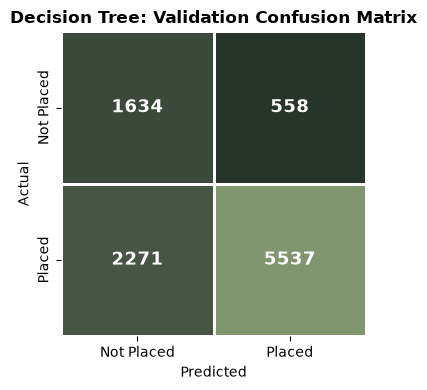

In [57]:
# Train model
model_dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE)
evaluate_model("Decision Tree", model_dt)
show_model_report("Decision Tree")

### Random Forest

,Random Forest
Train_F1,0.8585
Val_Accuracy,0.7601
Val_Precision,0.8994
Val_Recall,0.7800
Val_F1,0.8354
F1_Gap,0.0231
Val_ROC_AUC,0.8056
Train_Time_s,0.6585


,precision,recall,f1-score,support
Not Placed,0.47,0.69,0.56,2192.00
Placed,0.90,0.78,0.84,7808.00
accuracy,0.76,0.76,0.76,0.76
macro avg,0.68,0.73,0.70,10000.00
weighted avg,0.80,0.76,0.77,10000.00


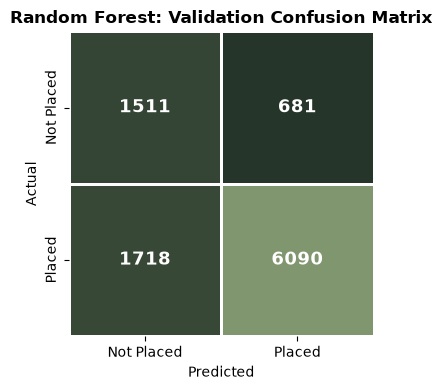

In [58]:
# Train model
model_rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_split=20, min_samples_leaf=10,
    max_features="sqrt", class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
evaluate_model("Random Forest", model_rf)
show_model_report("Random Forest")

### Extra Trees

,Extra Trees
Train_F1,0.8668
Val_Accuracy,0.7559
Val_Precision,0.9012
Val_Recall,0.7720
Val_F1,0.8316
F1_Gap,0.0352
Val_ROC_AUC,0.8028
Train_Time_s,0.5614


,precision,recall,f1-score,support
Not Placed,0.46,0.70,0.56,2192.00
Placed,0.90,0.77,0.83,7808.00
accuracy,0.76,0.76,0.76,0.76
macro avg,0.68,0.74,0.69,10000.00
weighted avg,0.80,0.76,0.77,10000.00


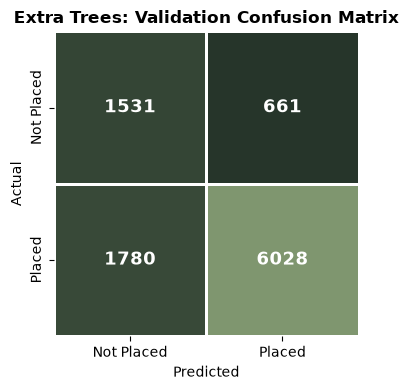

In [59]:
# Train model
model_et = ExtraTreesClassifier(
    n_estimators=300, max_depth=14, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
evaluate_model("Extra Trees", model_et)
show_model_report("Extra Trees")

### Bagging Classifier

,Bagging Classifier
Train_F1,1.0000
Val_Accuracy,0.8110
Val_Precision,0.8424
Val_Recall,0.9324
Val_F1,0.8851
F1_Gap,0.1149
Val_ROC_AUC,0.7984
Train_Time_s,4.1217


,precision,recall,f1-score,support
Not Placed,0.61,0.38,0.47,2192.00
Placed,0.84,0.93,0.89,7808.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.73,0.66,0.68,10000.00
weighted avg,0.79,0.81,0.79,10000.00


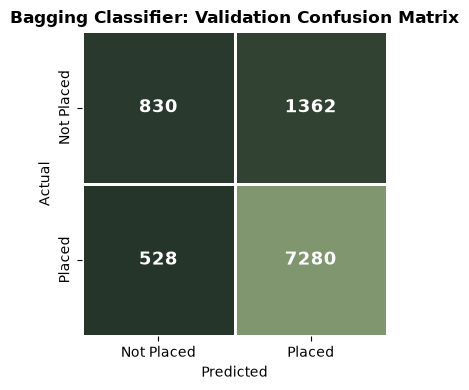

In [60]:
# Train model
model_bag = BaggingClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
evaluate_model("Bagging Classifier", model_bag)
show_model_report("Bagging Classifier")

### Gradient Boosting

,Gradient Boosting
Train_F1,0.8976
Val_Accuracy,0.8180
Val_Precision,0.8401
Val_Recall,0.9471
Val_F1,0.8904
F1_Gap,0.0072
Val_ROC_AUC,0.8047
Train_Time_s,8.9365


,precision,recall,f1-score,support
Not Placed,0.66,0.36,0.46,2192.00
Placed,0.84,0.95,0.89,7808.00
accuracy,0.82,0.82,0.82,0.82
macro avg,0.75,0.65,0.68,10000.00
weighted avg,0.80,0.82,0.80,10000.00


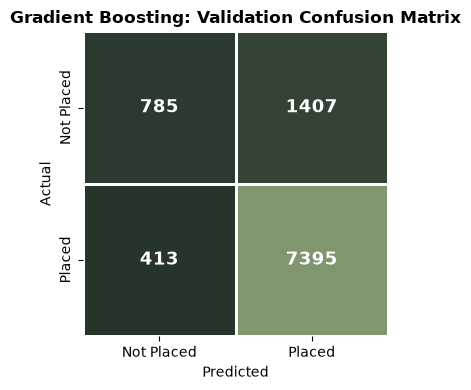

In [61]:
# Train model
model_gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
)
evaluate_model("Gradient Boosting", model_gb)
show_model_report("Gradient Boosting")

### AdaBoost

,AdaBoost
Train_F1,0.8934
Val_Accuracy,0.8187
Val_Precision,0.8397
Val_Recall,0.9489
Val_F1,0.8910
F1_Gap,0.0024
Val_ROC_AUC,0.8051
Train_Time_s,3.4315


,precision,recall,f1-score,support
Not Placed,0.66,0.35,0.46,2192.00
Placed,0.84,0.95,0.89,7808.00
accuracy,0.82,0.82,0.82,0.82
macro avg,0.75,0.65,0.68,10000.00
weighted avg,0.80,0.82,0.80,10000.00


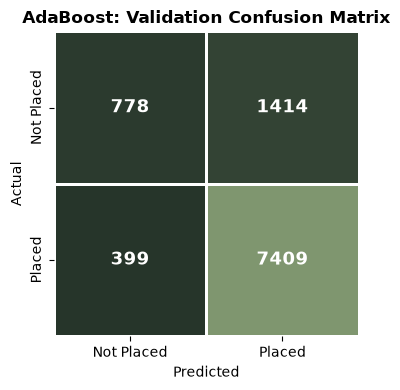

In [62]:
# Train model
model_ada = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE)
evaluate_model("AdaBoost", model_ada)
show_model_report("AdaBoost")

### HistGradientBoosting

,HistGradientBoosting
Train_F1,0.8521
Val_Accuracy,0.7527
Val_Precision,0.9031
Val_Recall,0.7654
Val_F1,0.8286
F1_Gap,0.0236
Val_ROC_AUC,0.8063
Train_Time_s,0.6822


,precision,recall,f1-score,support
Not Placed,0.46,0.71,0.56,2192.00
Placed,0.90,0.77,0.83,7808.00
accuracy,0.75,0.75,0.75,0.75
macro avg,0.68,0.74,0.69,10000.00
weighted avg,0.81,0.75,0.77,10000.00


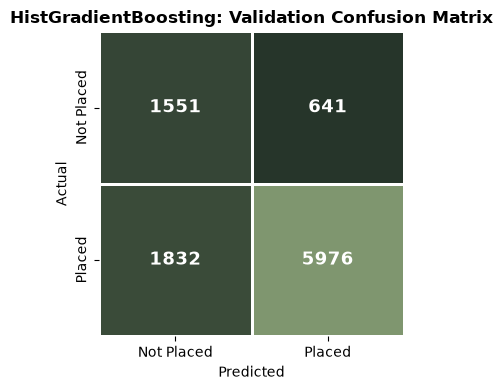

In [63]:
# Train model
model_hgb = HistGradientBoostingClassifier(
    max_depth=8, learning_rate=0.1, class_weight="balanced", random_state=RANDOM_STATE
)
evaluate_model("HistGradientBoosting", model_hgb)
show_model_report("HistGradientBoosting")

### XGBoost

,XGBoost
Train_F1,0.8782
Val_Accuracy,0.7552
Val_Precision,0.9054
Val_Recall,0.7665
Val_F1,0.8302
F1_Gap,0.0480
Val_ROC_AUC,0.8054
Train_Time_s,0.8119


,precision,recall,f1-score,support
Not Placed,0.46,0.71,0.56,2192.00
Placed,0.91,0.77,0.83,7808.00
accuracy,0.76,0.76,0.76,0.76
macro avg,0.68,0.74,0.70,10000.00
weighted avg,0.81,0.76,0.77,10000.00


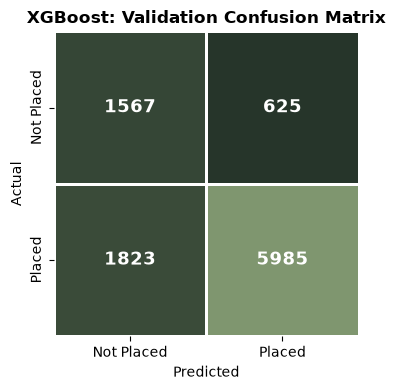

In [64]:
# Train model
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model_xgb = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)
evaluate_model("XGBoost", model_xgb)
show_model_report("XGBoost")

### LightGBM

,LightGBM
Train_F1,0.8771
Val_Accuracy,0.7566
Val_Precision,0.9018
Val_Recall,0.7724
Val_F1,0.8321
F1_Gap,0.0450
Val_ROC_AUC,0.8049
Train_Time_s,2.0261


,precision,recall,f1-score,support
Not Placed,0.46,0.70,0.56,2192.00
Placed,0.90,0.77,0.83,7808.00
accuracy,0.76,0.76,0.76,0.76
macro avg,0.68,0.74,0.69,10000.00
weighted avg,0.81,0.76,0.77,10000.00


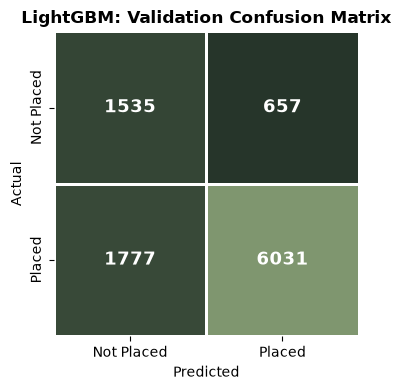

In [65]:
# Train model
model_lgbm = LGBMClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
evaluate_model("LightGBM", model_lgbm)
show_model_report("LightGBM")

### CatBoost

,CatBoost
Train_F1,0.8569
Val_Accuracy,0.7527
Val_Precision,0.9022
Val_Recall,0.7664
Val_F1,0.8288
F1_Gap,0.0281
Val_ROC_AUC,0.8066
Train_Time_s,1.4522


,precision,recall,f1-score,support
Not Placed,0.46,0.70,0.56,2192.00
Placed,0.90,0.77,0.83,7808.00
accuracy,0.75,0.75,0.75,0.75
macro avg,0.68,0.74,0.69,10000.00
weighted avg,0.80,0.75,0.77,10000.00


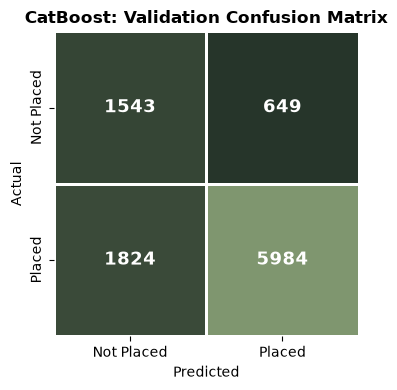

In [66]:
# Train model
model_cat = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05, auto_class_weights="Balanced",
    random_state=RANDOM_STATE, verbose=0
)
evaluate_model("CatBoost", model_cat)
show_model_report("CatBoost")

### Perceptron

,Perceptron
Train_F1,0.8097
Val_Accuracy,0.7232
Val_Precision,0.9003
Val_Recall,0.7259
Val_F1,0.8037
F1_Gap,0.0060
Val_ROC_AUC,0.7810
Train_Time_s,0.0255


,precision,recall,f1-score,support
Not Placed,0.42,0.71,0.53,2192.00
Placed,0.90,0.73,0.80,7808.00
accuracy,0.72,0.72,0.72,0.72
macro avg,0.66,0.72,0.67,10000.00
weighted avg,0.80,0.72,0.74,10000.00


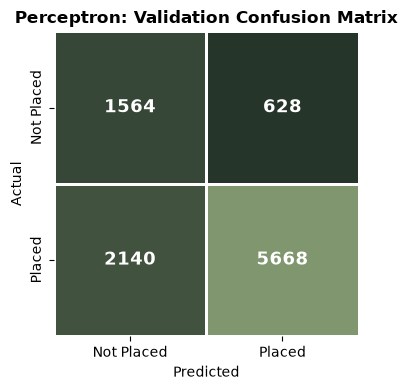

In [67]:
# Train model
model_perc = Perceptron(class_weight="balanced", max_iter=1500, random_state=RANDOM_STATE)
evaluate_model("Perceptron", model_perc)
show_model_report("Perceptron")

### MLP Neural Network

,MLP Neural Net
Train_F1,0.8922
Val_Accuracy,0.8149
Val_Precision,0.8423
Val_Recall,0.9387
Val_F1,0.8879
F1_Gap,0.0043
Val_ROC_AUC,0.8019
Train_Time_s,0.5978


,precision,recall,f1-score,support
Not Placed,0.63,0.37,0.47,2192.00
Placed,0.84,0.94,0.89,7808.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.74,0.66,0.68,10000.00
weighted avg,0.80,0.81,0.80,10000.00


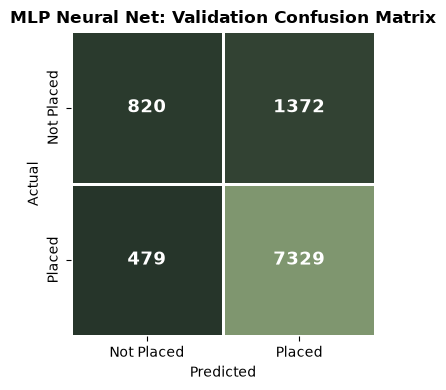

In [68]:
# Train model
model_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-3,
    max_iter=200, early_stopping=True, random_state=RANDOM_STATE
)
evaluate_model("MLP Neural Net", model_mlp)
show_model_report("MLP Neural Net")

### Voting Classifier

Soft voting over Random Forest, XGBoost and LightGBM.

,Voting Classifier
Train_F1,0.8921
Val_Accuracy,0.7739
Val_Precision,0.8987
Val_Recall,0.8007
Val_F1,0.8469
F1_Gap,0.0452
Val_ROC_AUC,0.8064
Train_Time_s,1.3851


,precision,recall,f1-score,support
Not Placed,0.49,0.68,0.57,2192.00
Placed,0.90,0.80,0.85,7808.00
accuracy,0.77,0.77,0.77,0.77
macro avg,0.69,0.74,0.71,10000.00
weighted avg,0.81,0.77,0.79,10000.00


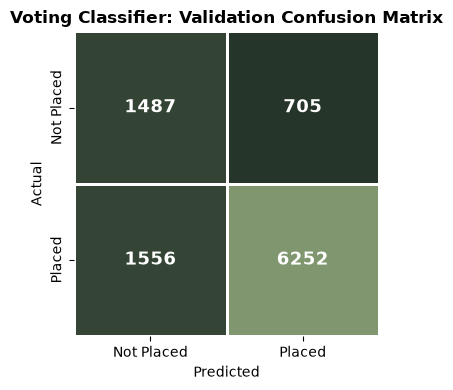

In [69]:
# Train model
model_vote = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=200, max_depth=14, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)),
        ("xgb", XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                              random_state=RANDOM_STATE, n_jobs=-1)),
        ("lgbm", LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.05,
                                class_weight="balanced", random_state=RANDOM_STATE,
                                n_jobs=-1, verbose=-1)),
    ],
    voting="soft", n_jobs=-1
)
evaluate_model("Voting Classifier", model_vote)
show_model_report("Voting Classifier")

### Stacking Classifier

Random Forest, XGBoost and LightGBM, with a logistic-regression meta-learner.

,Stacking Classifier
Train_F1,0.8864
Val_Accuracy,0.7405
Val_Precision,0.9068
Val_Recall,0.7441
Val_F1,0.8174
F1_Gap,0.0690
Val_ROC_AUC,0.8062
Train_Time_s,5.3902


,precision,recall,f1-score,support
Not Placed,0.44,0.73,0.55,2192.00
Placed,0.91,0.74,0.82,7808.00
accuracy,0.74,0.74,0.74,0.74
macro avg,0.68,0.74,0.68,10000.00
weighted avg,0.81,0.74,0.76,10000.00


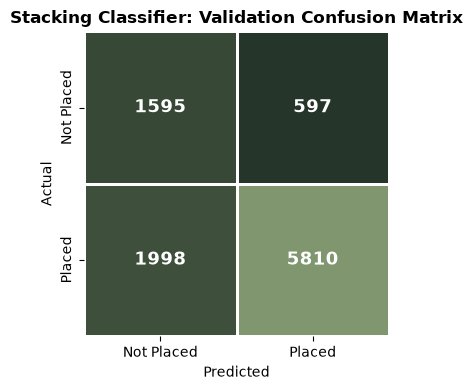

In [70]:
# Train model
model_stack = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=200, max_depth=14, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)),
        ("xgb", XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                              random_state=RANDOM_STATE, n_jobs=-1)),
        ("lgbm", LGBMClassifier(n_estimators=200, max_depth=8, learning_rate=0.05,
                                class_weight="balanced", random_state=RANDOM_STATE,
                                n_jobs=-1, verbose=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=3, n_jobs=-1
)
evaluate_model("Stacking Classifier", model_stack)
show_model_report("Stacking Classifier")

## 10. Model Comparison

Models ranked by validation F1.

In [71]:
results_df = (pd.DataFrame(results)
              .drop_duplicates(subset="Model", keep="last")
              .sort_values("Val_F1", ascending=False)
              .reset_index(drop=True))
results_df.index += 1
display(results_df.round(4))
print(f"Models evaluated: {len(results_df)}")

,Model,Train_F1,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,F1_Gap,Val_ROC_AUC,Train_Time_s
1,AdaBoost,0.8934,0.8187,0.8397,0.9489,0.8910,0.0024,0.8051,3.4315
2,Gradient Boosting,0.8976,0.8180,0.8401,0.9471,0.8904,0.0072,0.8047,8.9365
3,Linear SVM,0.8925,0.8165,0.8398,0.9453,0.8894,0.0031,0.8046,0.1352
4,MLP Neural Net,0.8922,0.8149,0.8423,0.9387,0.8879,0.0043,0.8019,0.5978
5,LDA,0.8891,0.8137,0.8448,0.9328,0.8866,0.0024,0.8040,0.0359
6,Bagging Classifier,1.0000,0.8110,0.8424,0.9324,0.8851,0.1149,0.7984,4.1217
7,K-Nearest Neighbors,0.8931,0.8072,0.8318,0.9440,0.8843,0.0087,0.7847,0.0010
8,QDA,0.8741,0.7967,0.8552,0.8904,0.8724,0.0017,0.7854,0.0213
9,Gaussian Naive Bayes,0.8505,0.7703,0.8799,0.8174,0.8475,0.0031,0.7896,0.0056
10,Voting Classifier,0.8921,0.7739,0.8987,0.8007,0.8469,0.0452,0.8064,1.3851


Models evaluated: 23


### Overfitting check (train vs validation F1)

In [72]:
display(results_df[["Model", "Train_F1", "Val_F1", "F1_Gap"]].sort_values("F1_Gap", ascending=False).round(4))

,Model,Train_F1,Val_F1,F1_Gap
6,Bagging Classifier,1.0000,0.8851,0.1149
19,Stacking Classifier,0.8864,0.8174,0.0690
14,XGBoost,0.8782,0.8302,0.0480
10,Voting Classifier,0.8921,0.8469,0.0452
12,LightGBM,0.8771,0.8321,0.0450
13,Extra Trees,0.8668,0.8316,0.0352
15,CatBoost,0.8569,0.8288,0.0281
16,HistGradientBoosting,0.8521,0.8286,0.0236
11,Random Forest,0.8585,0.8354,0.0231
23,Decision Tree,0.8163,0.7965,0.0197


### Train vs validation F1

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


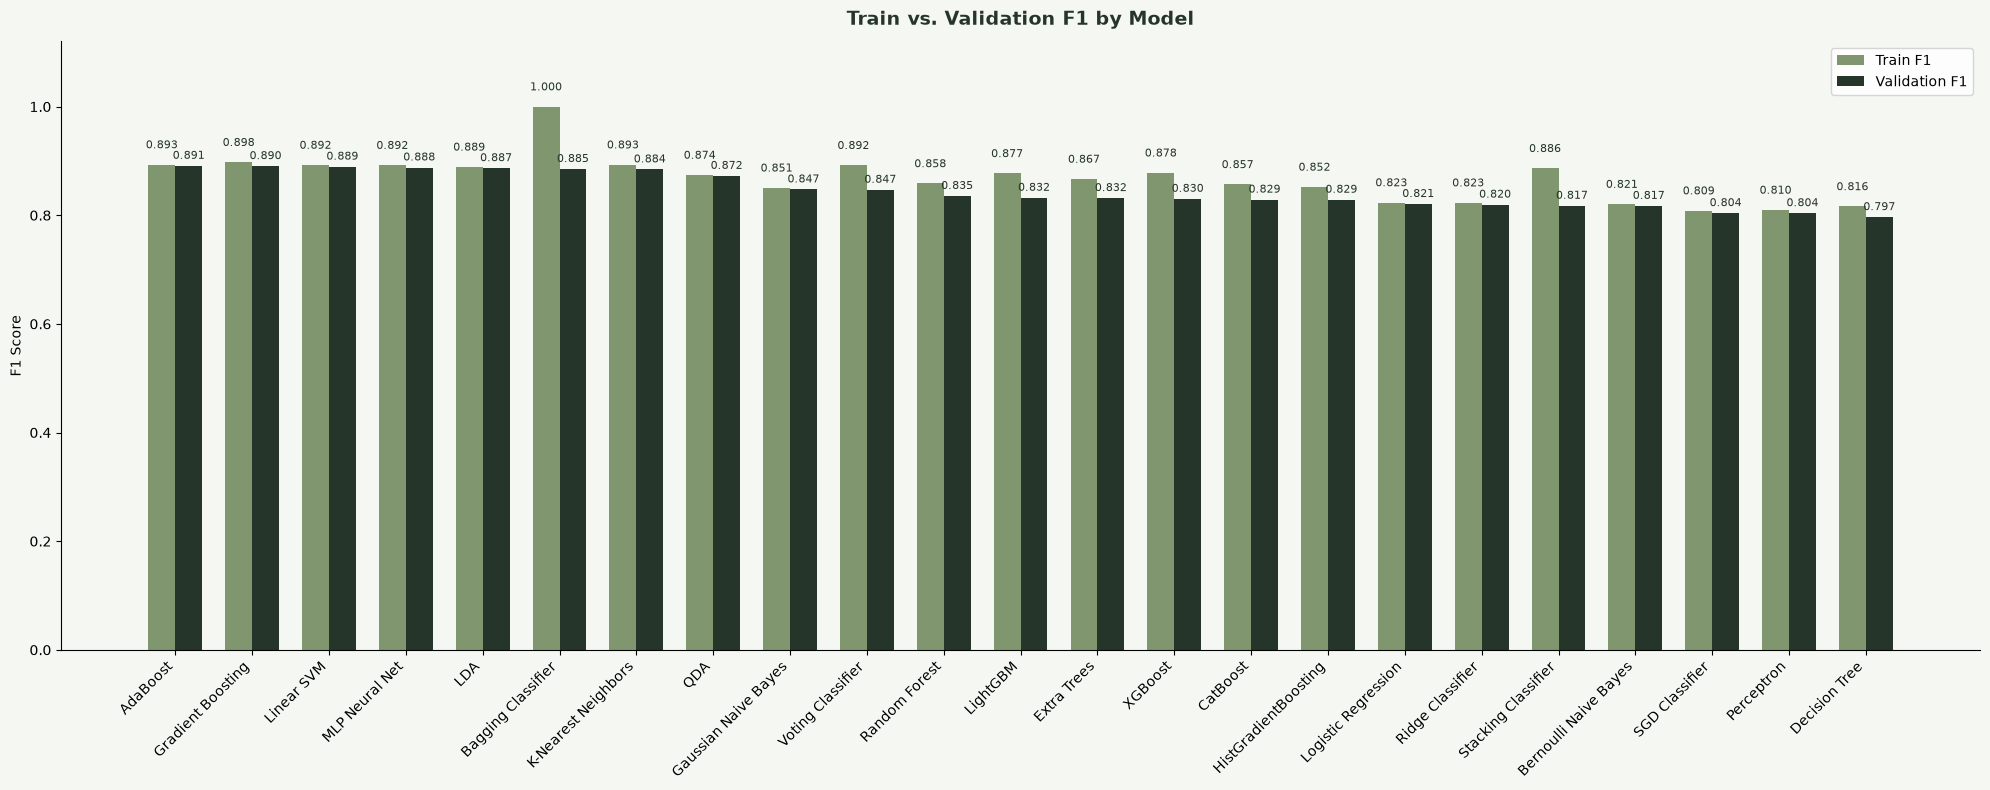

Models with Train-Val F1 gap > 0.10 (possible overfitting):
             Model  Train_F1   Val_F1   F1_Gap
Bagging Classifier       1.0 0.885106 0.114894


In [73]:
# Train vs Validation F1
tones = ["#26352A", "#7F966F"]
bg = "#F4F7F2"
order = results_df.sort_values("Val_F1", ascending=False)["Model"]
x_pos = np.arange(len(order))
gap_df = results_df.set_index("Model").loc[order]

fig, ax = plt.subplots(figsize=(20, 8), facecolor=bg)   # increased width
ax.set_facecolor(bg)

bar_width = 0.35
bars1 = ax.bar(x_pos - bar_width/2, gap_df["Train_F1"], width=bar_width, label="Train F1", color=tones[1])
bars2 = ax.bar(x_pos + bar_width/2, gap_df["Val_F1"], width=bar_width, label="Validation F1", color=tones[0])

# Staggered labels to avoid overlap
for bar in bars1:   # Train → higher
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.025,
        f"{height:.3f}",
        ha="center", va="bottom",
        fontsize=8, color="#26352A", fontweight="medium"
    )

for bar in bars2:   
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.008,
        f"{height:.3f}",
        ha="center", va="bottom",
        fontsize=8, color="#26352A", fontweight="medium"
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Train vs. Validation F1 by Model",
             fontsize=14, fontweight="bold", color=tones[0], pad=12)
ax.legend(loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ymax = gap_df[["Train_F1", "Val_F1"]].max().max()
ax.set_ylim(0, ymax + 0.12)

plt.tight_layout()
plt.show()

print("Models with Train-Val F1 gap > 0.10 (possible overfitting):")
print(results_df[results_df["F1_Gap"] > 0.10][["Model", "Train_F1", "Val_F1", "F1_Gap"]]
      .to_string(index=False))

### Validation metrics across models

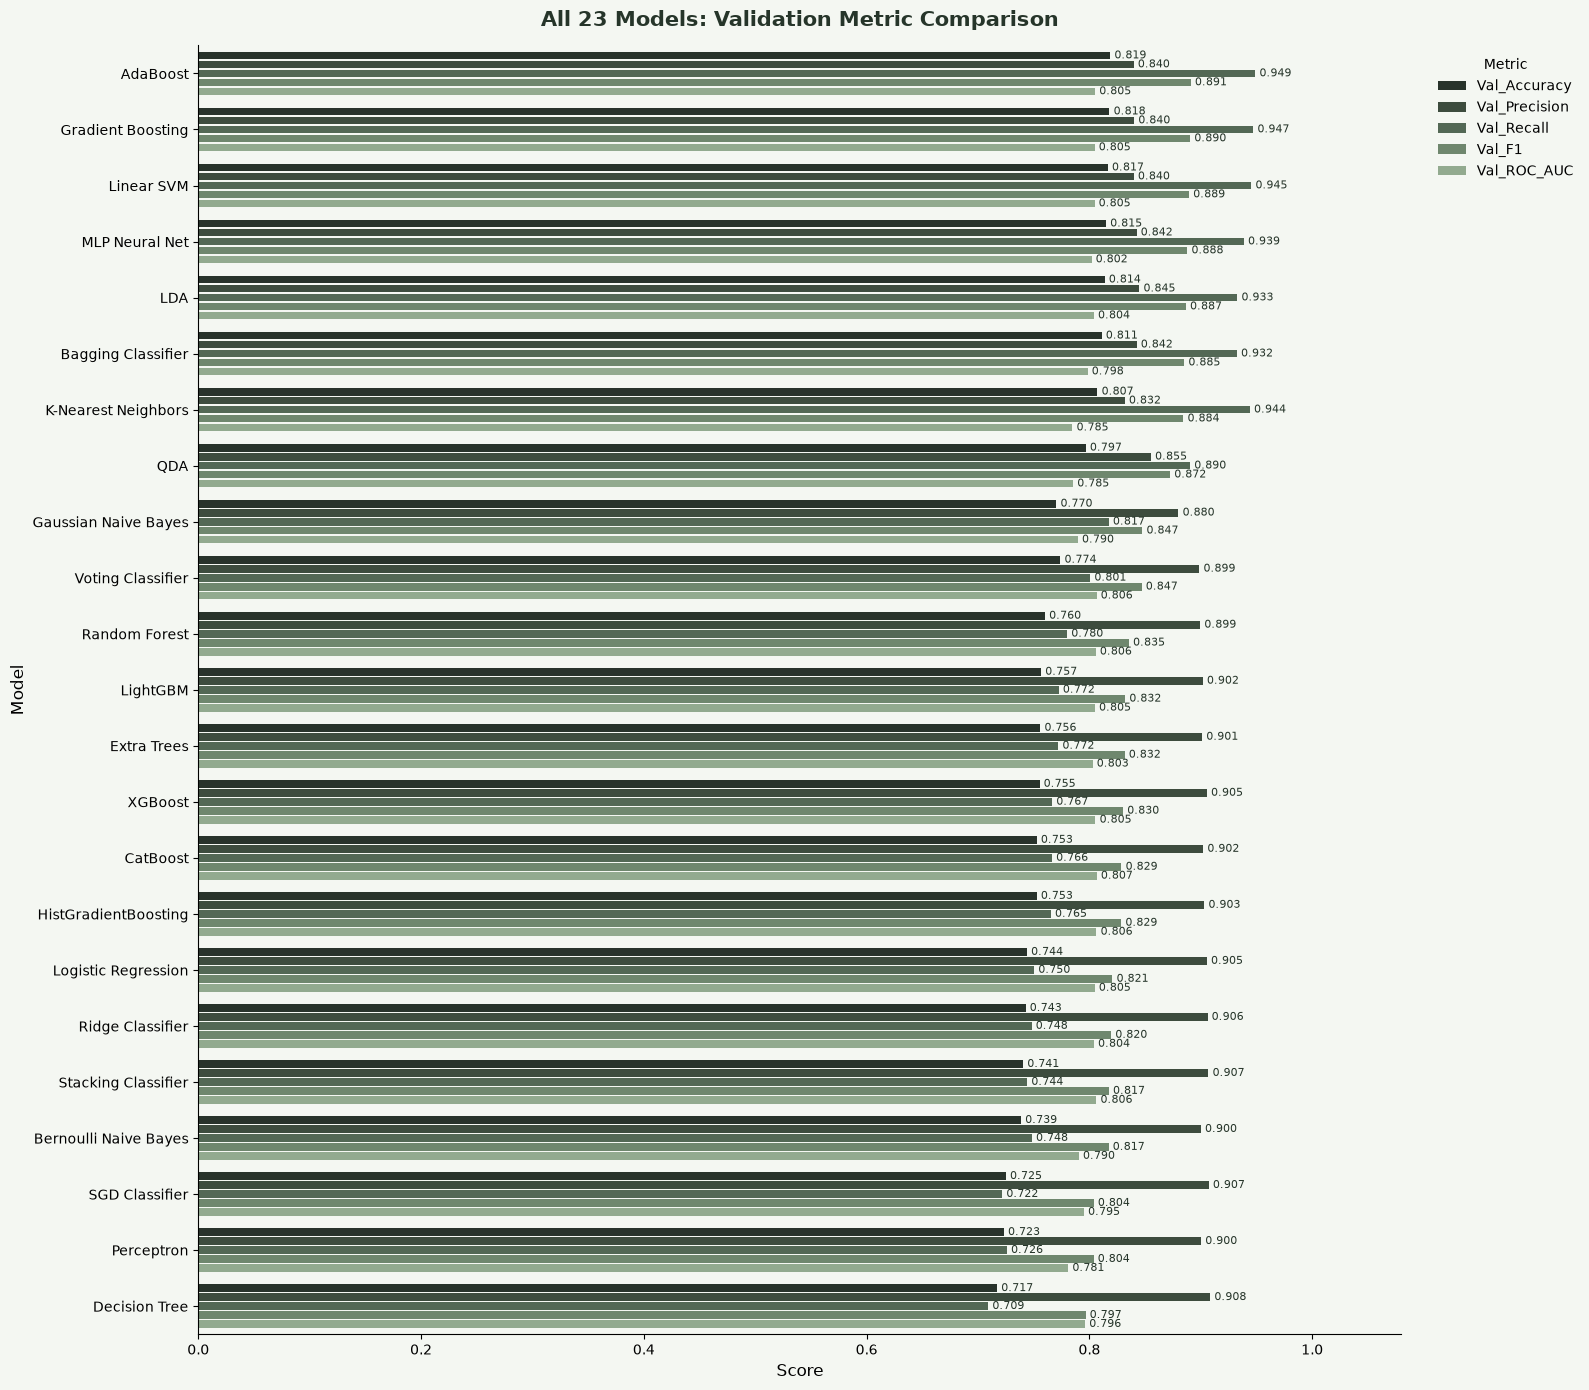

In [74]:
tones = ["#26352A", "#7F966F"]
bg = "#F4F7F2"
palette = ["#26352A",  "#3A4F3C", "#4F6B52",  "#6B8B6A",  "#8FAE8A"]

metrics_to_plot = ["Val_Accuracy", "Val_Precision", "Val_Recall", "Val_F1", "Val_ROC_AUC"]
plot_df = results_df.melt(id_vars="Model", value_vars=metrics_to_plot, var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(16, 14), facecolor=bg)
ax.set_facecolor(bg)

order = results_df.sort_values("Val_F1", ascending=False)["Model"]

sns.barplot(data=plot_df, y="Model", x="Score", hue="Metric",
            order=order, palette=palette, ax=ax,
            dodge=True, gap=0.15)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8, color="#26352A", fontweight="medium")

ax.set_title("All 23 Models: Validation Metric Comparison",
             fontsize=15, fontweight="bold", color="#26352A", pad=14)
ax.set_xlabel("Score", fontsize=12)
ax.set_ylabel("Model", fontsize=12)
ax.set_xlim(0, 1.08)   # extra space so labels don't get cut
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="Metric")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()

### Training time vs performance

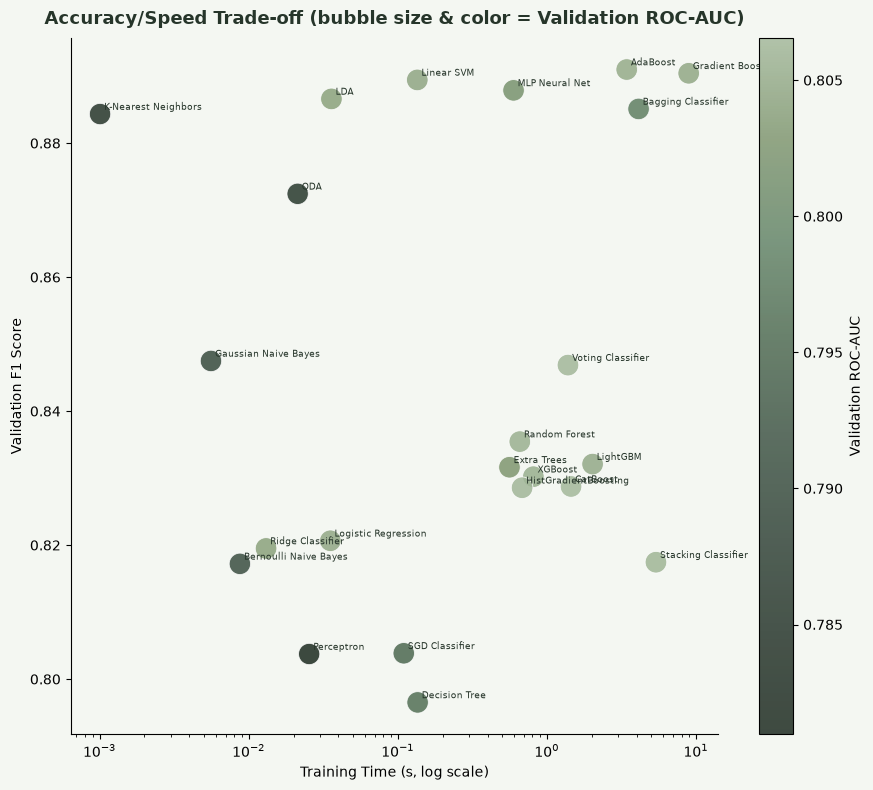

In [75]:
moss_colors = ["#1C2A1F", "#26352A", "#324438", "#3F5545", "#4F6B52", "#648568",  "#7F966F",  "#A3B89A"]

bg = "#F4F7F2"
moss = LinearSegmentedColormap.from_list("moss", moss_colors)

fig, ax = plt.subplots(figsize=(9, 8), facecolor=bg)
ax.set_facecolor(bg)

sc = ax.scatter(results_df["Train_Time_s"], results_df["Val_F1"],
                s=results_df["Val_ROC_AUC"] * 300,
                c=results_df["Val_ROC_AUC"],
                cmap=moss, alpha=0.85, edgecolor="white", linewidth=0.6)

for _, row in results_df.iterrows():
    ax.annotate(row["Model"],
                (row["Train_Time_s"], row["Val_F1"]),
                fontsize=6.5, color="#26352A",
                xytext=(3, 3), textcoords="offset points")

ax.set_xscale("log")
ax.set_xlabel("Training Time (s, log scale)")
ax.set_ylabel("Validation F1 Score")
ax.set_title("Accuracy/Speed Trade-off (bubble size & color = Validation ROC-AUC)",
             fontsize=13, fontweight="bold", color="#26352A", pad=10)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Validation ROC-AUC")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### ROC curves (top 8 models)

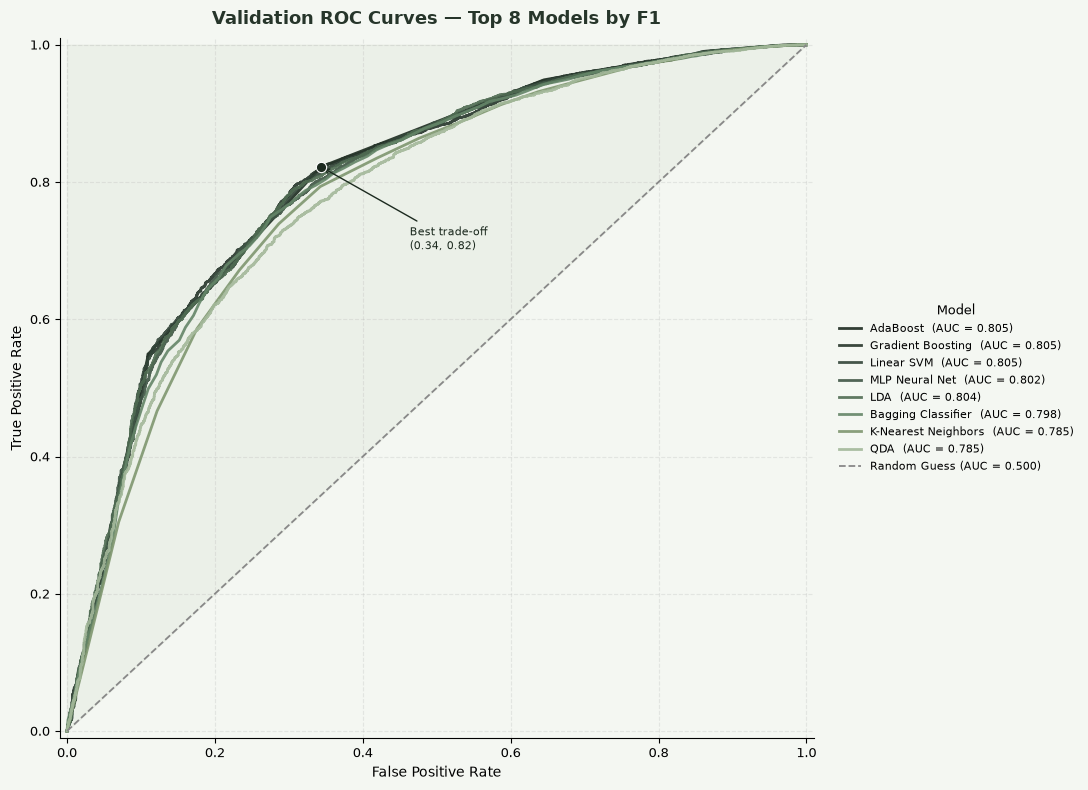

In [76]:
# Validation ROC Curves
top8 = results_df.head(8)["Model"].tolist()

# moss palette
moss_colors = [
    "#1C2A1F", "#26352A", "#324438", "#3F5545",
    "#4F6B52", "#648568", "#7F966F", "#A3B89A"
]
bg = "#F4F7F2"

fig, ax = plt.subplots(figsize=(11, 8), facecolor=bg)
ax.set_facecolor(bg)

# Plot ROC curves
for i, name in enumerate(top8):
    if name in roc_curves:
        fpr, tpr, auc = roc_curves[name]
        ax.plot(fpr, tpr,
                label=f"{name}  (AUC = {auc:.3f})",
                color=moss_colors[i % len(moss_colors)],
                linewidth=2.0, alpha=0.9)
ax.plot([0, 1], [0, 1],
        linestyle="--", color="#888888", linewidth=1.3,
        label="Random Guess (AUC = 0.500)")
ax.fill_between([0, 1], [0, 1], [1, 1],
                color="#7F966F", alpha=0.07, zorder=0)
best_name = top8[0]
if best_name in roc_curves:
    fpr_b, tpr_b, auc_b = roc_curves[best_name]
    # Find point closest to top-left (best trade-off)
    idx = np.argmax(tpr_b - fpr_b)
    ax.scatter(fpr_b[idx], tpr_b[idx],
               s=55, color="#1C2A1F", zorder=5, edgecolor="white", linewidth=0.8)
    ax.annotate(f"Best trade-off\n({fpr_b[idx]:.2f}, {tpr_b[idx]:.2f})",
                xy=(fpr_b[idx], tpr_b[idx]),
                xytext=(fpr_b[idx] + 0.12, tpr_b[idx] - 0.12),
                fontsize=8, color="#1C2A1F",
                arrowprops=dict(arrowstyle="->", color="#1C2A1F", lw=1))

# Axes formatting
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.set_title("Validation ROC Curves — Top 8 Models by F1",
             fontsize=13, fontweight="bold", color="#26352A", pad=10)

# Smaller, cleaner legend
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=8, frameon=False, title="Model", title_fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.25)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## 11. Final Test-Set Evaluation

We select the champion by validation F1 and score it **once** on the untouched test set.

Champion model: AdaBoost


,AdaBoost
Validation F1,0.8910
Test F1,0.8924
Val-Test F1 Gap,0.0014
Validation AUC,0.8051
Test AUC,0.8066
Test Accuracy,0.8214
Test Precision,0.8428
Test Recall,0.9481


,precision,recall,f1-score,support
Not Placed,0.67,0.37,0.48,2192.00
Placed,0.84,0.95,0.89,7808.00
accuracy,0.82,0.82,0.82,0.82
macro avg,0.75,0.66,0.68,10000.00
weighted avg,0.80,0.82,0.80,10000.00


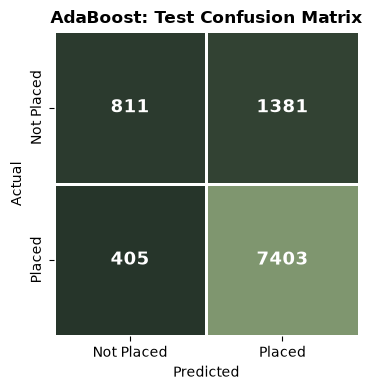

Validation vs test F1 gap: 0.0014 (consistent)


In [77]:
champion_name = results_df.iloc[0]["Model"]
champion_model = fitted_models[champion_name]
champion_row = results_df.iloc[0]

test_pred = champion_model.predict(X_test)
test_proba = (champion_model.predict_proba(X_test)[:, 1] if hasattr(champion_model, "predict_proba")
              else champion_model.decision_function(X_test))
test_f1 = f1_score(y_test, test_pred)

champ_metrics = pd.Series({
    "Validation F1": champion_row["Val_F1"],
    "Test F1": test_f1,
    "Val-Test F1 Gap": abs(champion_row["Val_F1"] - test_f1),
    "Validation AUC": champion_row["Val_ROC_AUC"],
    "Test AUC": roc_auc_score(y_test, test_proba),
    "Test Accuracy": accuracy_score(y_test, test_pred),
    "Test Precision": precision_score(y_test, test_pred),
    "Test Recall": recall_score(y_test, test_pred),
}).round(4).to_frame(champion_name)
print(f"Champion model: {champion_name}")
display(champ_metrics)

report_df = pd.DataFrame(classification_report(y_test, test_pred, target_names=LABELS, output_dict=True)).T
display(report_df.round(2))
plot_confusion(y_test, test_pred, f"{champion_name}: Test Confusion Matrix")

gap = abs(champion_row["Val_F1"] - test_f1)
print(f"Validation vs test F1 gap: {gap:.4f} ({'consistent' if gap < 0.05 else 'notable difference, investigate'})")

### Save the champion model

In [78]:
# save the champion model along with preprocessor and feature names
import joblib

save_dict = {
    "model": champion_model,
    "preprocessor": preprocessor,
    "feature_names": feature_names
}

joblib.dump(save_dict, "champion_model.pkl")
print(f"Saved '{champion_name}' + preprocessing pipeline -> champion_model.pkl")

Saved 'AdaBoost' + preprocessing pipeline -> champion_model.pkl


## 12. Hyperparameter Tuning

We tune the three most accurate baseline models with two methods and compare them:

- **RandomizedSearchCV** samples 20 random candidates from each search space.
- **Optuna** (TPE sampler) runs 20 trials that adapt to earlier results.

Both methods use the same budget, 3-fold stratified CV on the training split, and F1 scoring. The tuned models are then compared with the baselines on the validation and test splits.

In [79]:
N_TRIALS = 20
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

top3 = results_df.sort_values("Val_Accuracy", ascending=False).head(3)["Model"].tolist()
print("Models to tune:", top3)

def base_estimator(name):
    if name == "AdaBoost":
        return AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=RANDOM_STATE)
    if name == "Gradient Boosting":
        return GradientBoostingClassifier(random_state=RANDOM_STATE)
    if name == "Linear SVM":
        return CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE), cv=3)
    raise ValueError(f"No tuning setup defined for {name}")

# Search spaces for RandomizedSearchCV
random_spaces = {
    "AdaBoost": {"n_estimators": randint(50, 401), "learning_rate": loguniform(0.01, 2),
                 "estimator__max_depth": [1, 2, 3]},
    "Gradient Boosting": {"n_estimators": randint(100, 301), "learning_rate": loguniform(0.01, 0.3),
                          "max_depth": randint(2, 5), "subsample": uniform(0.6, 0.4),
                          "min_samples_leaf": randint(1, 51), "max_features": ["sqrt", None]},
    "Linear SVM": {"estimator__C": loguniform(1e-3, 10), "estimator__loss": ["hinge", "squared_hinge"]},
}

# The same search spaces expressed for Optuna
def optuna_params(name, trial):
    if name == "AdaBoost":
        return {"n_estimators": trial.suggest_int("n_estimators", 50, 400),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 2, log=True),
                "estimator__max_depth": trial.suggest_int("estimator__max_depth", 1, 3)}
    if name == "Gradient Boosting":
        return {"n_estimators": trial.suggest_int("n_estimators", 100, 300),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 4),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", None])}
    return {"estimator__C": trial.suggest_float("estimator__C", 1e-3, 10, log=True),
            "estimator__loss": trial.suggest_categorical("estimator__loss", ["hinge", "squared_hinge"])}

tuning_rows, tuned_models, optuna_studies = [], {}, {}

def score_split(model, X, y):
    pred = model.predict(X)
    return accuracy_score(y, pred), f1_score(y, pred), roc_auc_score(y, model.predict_proba(X)[:, 1])

def record(name, method, model, cv_f1, seconds, params):
    val_acc, val_f1, val_auc = score_split(model, X_val, y_val)
    test_acc, test_f1, test_auc = score_split(model, X_test, y_test)
    tuning_rows.append({
        "Model": name, "Method": method, "CV_F1": cv_f1,
        "Val_Accuracy": val_acc, "Val_F1": val_f1, "Val_ROC_AUC": val_auc,
        "Test_Accuracy": test_acc, "Test_F1": test_f1, "Test_ROC_AUC": test_auc,
        "Search_Time_s": seconds,
        "Best_Params": ", ".join(f"{k}={v:.4g}" if isinstance(v, float) else f"{k}={v}" for k, v in params.items()),
    })
    tuned_models[(name, method)] = model

Models to tune: ['AdaBoost', 'Gradient Boosting', 'Linear SVM']


### Baselines and RandomizedSearchCV

In [80]:
for name in top3:
    # Baseline: the benchmark model, with CV F1 computed under the same folds for a fair comparison
    baseline = fitted_models[name]
    baseline_cv = cross_val_score(clone(baseline), X_train, y_train, cv=CV, scoring="f1", n_jobs=-1).mean()
    record(name, "Baseline", baseline, baseline_cv, np.nan, {})

    t0 = time.time()
    search = RandomizedSearchCV(base_estimator(name), random_spaces[name], n_iter=N_TRIALS, cv=CV, scoring="f1",
                                n_jobs=-1, random_state=RANDOM_STATE)
    search.fit(X_train, y_train)
    record(name, "RandomizedSearch", search.best_estimator_, search.best_score_, time.time() - t0, search.best_params_)
    print(f"{name}: baseline CV F1 {baseline_cv:.4f} -> RandomizedSearch CV F1 {search.best_score_:.4f}")

AdaBoost: baseline CV F1 0.8928 -> RandomizedSearch CV F1 0.8929


Gradient Boosting: baseline CV F1 0.8903 -> RandomizedSearch CV F1 0.8929


Linear SVM: baseline CV F1 0.8920 -> RandomizedSearch CV F1 0.8921


### Optuna

AdaBoost: Optuna best CV F1 0.8929


Gradient Boosting: Optuna best CV F1 0.8931


Linear SVM: Optuna best CV F1 0.8923


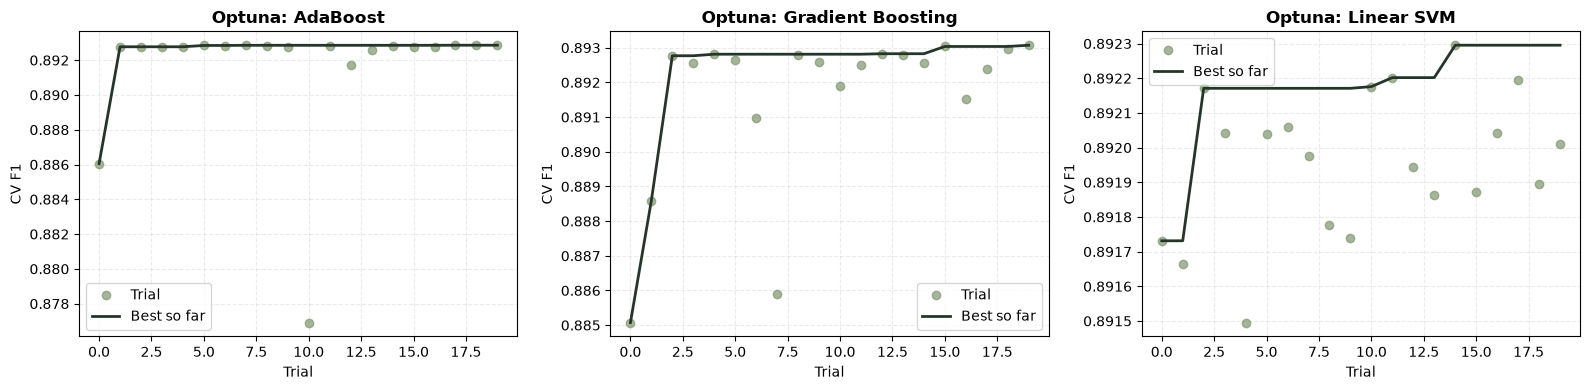

In [81]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

for name in top3:
    def objective(trial):
        model = base_estimator(name).set_params(**optuna_params(name, trial))
        return cross_val_score(model, X_train, y_train, cv=CV, scoring="f1", n_jobs=-1).mean()

    t0 = time.time()
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS)
    best_model = base_estimator(name).set_params(**study.best_params).fit(X_train, y_train)
    record(name, "Optuna", best_model, study.best_value, time.time() - t0, study.best_params)
    optuna_studies[name] = study
    print(f"{name}: Optuna best CV F1 {study.best_value:.4f}")

# Optimisation history: each trial's CV F1 and the best value so far
fig, axes = plt.subplots(1, len(optuna_studies), figsize=(16, 4))
for ax, (name, study) in zip(np.atleast_1d(axes), optuna_studies.items()):
    values = [t.value for t in study.trials]
    ax.plot(values, "o", color="#7F966F", alpha=0.7, label="Trial")
    ax.plot(np.maximum.accumulate(values), color="#26352A", linewidth=2, label="Best so far")
    ax.set_title(f"Optuna: {name}", fontweight="bold")
    ax.set_xlabel("Trial")
    ax.set_ylabel("CV F1")
    ax.grid(alpha=0.25, linestyle="--")
    ax.legend()
plt.tight_layout()
plt.show()

### Tuning results

,Model,Method,CV_F1,Val_Accuracy,Val_F1,Val_ROC_AUC,Test_Accuracy,Test_F1,Test_ROC_AUC,Search_Time_s
0,AdaBoost,Baseline,0.8928,0.8187,0.8910,0.8051,0.8214,0.8924,0.8066,NaN
1,AdaBoost,RandomizedSearch,0.8929,0.8187,0.8910,0.8052,0.8214,0.8924,0.8062,67.8458
2,Gradient Boosting,Baseline,0.8903,0.8180,0.8904,0.8047,0.8175,0.8898,0.8063,NaN
3,Gradient Boosting,RandomizedSearch,0.8929,0.8187,0.8910,0.8040,0.8214,0.8924,0.8051,34.0524
4,Linear SVM,Baseline,0.8920,0.8165,0.8894,0.8046,0.8179,0.8900,0.8028,NaN
5,Linear SVM,RandomizedSearch,0.8921,0.8162,0.8892,0.8046,0.8180,0.8901,0.8029,3.6833
6,AdaBoost,Optuna,0.8929,0.8187,0.8910,0.8051,0.8214,0.8924,0.8066,68.1714
7,Gradient Boosting,Optuna,0.8931,0.8187,0.8910,0.8067,0.8215,0.8924,0.8079,69.9331
8,Linear SVM,Optuna,0.8923,0.8157,0.8889,0.8046,0.8190,0.8907,0.8032,4.7843


,Model,Method,Best_Params
1,AdaBoost,RandomizedSearch,"estimator__max_depth=2, learning_rate=0.01038,..."
3,Gradient Boosting,RandomizedSearch,"learning_rate=0.01055, max_depth=2, max_featur..."
5,Linear SVM,RandomizedSearch,"estimator__C=0.02162, estimator__loss=squared_..."
6,AdaBoost,Optuna,"n_estimators=77, learning_rate=0.02114, estima..."
7,Gradient Boosting,Optuna,"n_estimators=132, learning_rate=0.01389, max_d..."
8,Linear SVM,Optuna,"estimator__C=0.001185, estimator__loss=hinge"


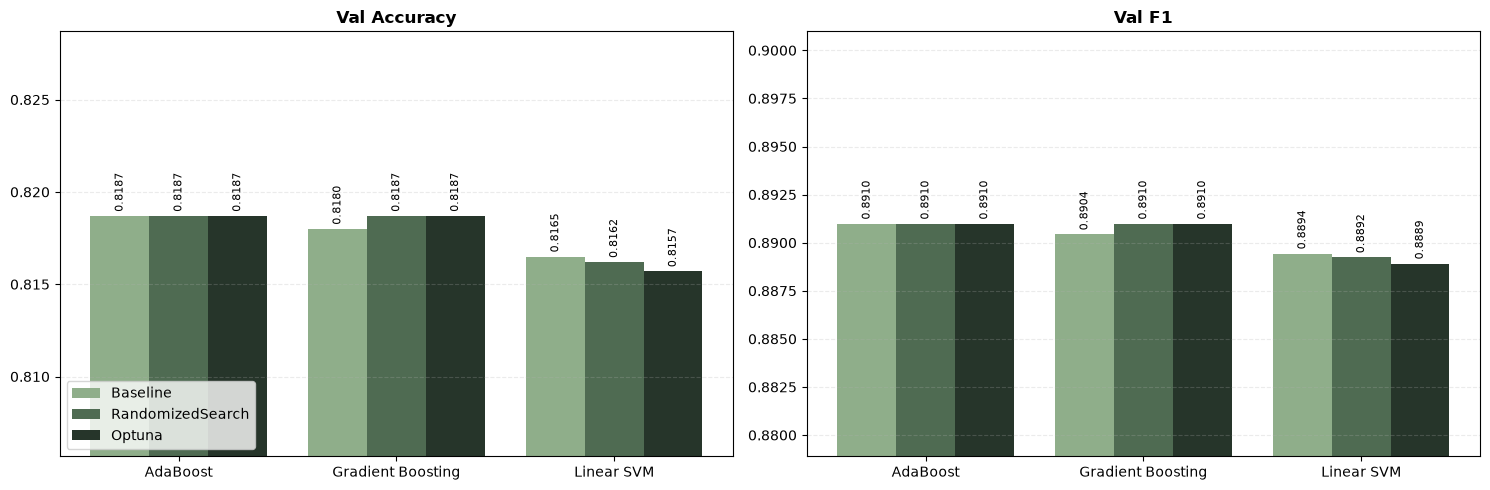

AdaBoost: best = Baseline (Val F1 0.8910, +0.0000 vs baseline)
Gradient Boosting: best = RandomizedSearch (Val F1 0.8910, +0.0006 vs baseline)
Linear SVM: best = Baseline (Val F1 0.8894, +0.0000 vs baseline)


In [82]:
tuning_df = pd.DataFrame(tuning_rows)
metric_cols = ["Model", "Method", "CV_F1", "Val_Accuracy", "Val_F1", "Val_ROC_AUC",
               "Test_Accuracy", "Test_F1", "Test_ROC_AUC", "Search_Time_s"]
display(tuning_df[metric_cols].round(4))
display(tuning_df.loc[tuning_df["Method"] != "Baseline", ["Model", "Method", "Best_Params"]])

# Baseline vs tuned: validation accuracy and F1
methods = ["Baseline", "RandomizedSearch", "Optuna"]
colors = ["#8FAE8A", "#4F6B52", "#26352A"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ["Val_Accuracy", "Val_F1"]):
    pivot = tuning_df.pivot(index="Model", columns="Method", values=metric).loc[top3, methods]
    x = np.arange(len(pivot))
    for j, method in enumerate(methods):
        bars = ax.bar(x + (j - 1) * 0.27, pivot[method], width=0.27, color=colors[j], label=method)
        ax.bar_label(bars, fmt="%.4f", fontsize=8, rotation=90, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylim(pivot.values.min() - 0.01, pivot.values.max() + 0.01)
    ax.set_title(metric.replace("_", " "), fontweight="bold")
    ax.grid(axis="y", alpha=0.25, linestyle="--")
axes[0].legend(loc="lower left")
plt.tight_layout()
plt.show()

for name in top3:
    sub = tuning_df[tuning_df["Model"] == name].set_index("Method")
    best_method = sub["Val_F1"].idxmax()
    delta = sub.loc[best_method, "Val_F1"] - sub.loc["Baseline", "Val_F1"]
    print(f"{name}: best = {best_method} (Val F1 {sub.loc[best_method, 'Val_F1']:.4f}, {delta:+.4f} vs baseline)")

### Update the champion

If a tuned model beats the benchmark champion on validation F1, we save it as the new champion.

In [83]:
best_row = tuning_df.sort_values("Val_F1", ascending=False).iloc[0]
if best_row["Method"] != "Baseline" and best_row["Val_F1"] > results_df.iloc[0]["Val_F1"]:
    champion_name = f"{best_row['Model']} ({best_row['Method']})"
    champion_model = tuned_models[(best_row["Model"], best_row["Method"])]
    joblib.dump({"model": champion_model, "preprocessor": preprocessor, "feature_names": feature_names}, "champion_model.pkl")
    print(f"New champion saved: {champion_name} (Val F1 {best_row['Val_F1']:.4f}, Test F1 {best_row['Test_F1']:.4f})")
else:
    print(f"No tuned model beat the benchmark champion ({results_df.iloc[0]['Model']}, "
          f"Val F1 {results_df.iloc[0]['Val_F1']:.4f}); champion_model.pkl is unchanged.")

No tuned model beat the benchmark champion (AdaBoost, Val F1 0.8910); champion_model.pkl is unchanged.


### Tuning interpretation

- **Tuning brings almost no gain.** The best improvement is +0.0006 validation F1 (Gradient Boosting, where both methods reach about 0.8910). AdaBoost is unchanged, and Linear SVM drops slightly on validation.
- **Optuna vs RandomizedSearchCV.** With the same 20-candidate budget, Optuna found marginally higher CV F1 for all three models. The difference is within ±0.0003 and does not carry over to the validation set.
- **The models have reached a ceiling.** All three top models land at roughly 0.89 F1 / 0.82 accuracy / 0.80 AUC. The limit appears to come from the available features, not from the hyperparameters.
- The baseline AdaBoost therefore remains the champion. It is also the simplest of the strong models.

## 13. Conclusions

- **Placement drivers.** Placed students have more projects (+30%), higher programming skill (+22%), more certifications, and higher interview and employability scores. CGPA, attendance and internships are also significantly higher, with small to moderate effects. Major, academic performance and English proficiency show weak-to-moderate associations with placement.
- **Leakage.** `Company_Tier` and `Career_Field` are perfectly associated with the target (Cramér's V = 1.0). Together with `Placement_Mode` and salary, we excluded them from modelling.
- **Benchmark.** Across 23 classifiers, AdaBoost had the best validation F1 (0.891), closely followed by Gradient Boosting and Linear SVM. Heavier ensembles (XGBoost, LightGBM, stacking) did not help.
- **Final model.** On the held-out test set, AdaBoost reaches F1 0.892, accuracy 0.821 and AUC 0.807, with a validation–test gap of only 0.0014.
- **Tuning.** Neither RandomizedSearchCV nor Optuna improved the top models in a meaningful way.
- **Limitations.** Recall for the *Not Placed* class is low (0.37). Future work should focus on class-imbalance handling (threshold tuning, resampling) and richer features rather than further hyperparameter search.